In [1]:
import os, cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.utils import resample

from skimage.measure import regionprops
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from scipy.stats import skew

import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

In [2]:
# Imports & path konfigurasi
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings("ignore")

In [3]:
# --- Path Dataset ISIC 2019 ---
TRAIN_IMG_DIR = "/kaggle/input/isic-2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input"
TEST_IMG_DIR  = "/kaggle/input/isic-2019/ISIC_2019_Test_Input/ISIC_2019_Test_Input"
TRAIN_GT_CSV  = "/kaggle/input/isic-2019/ISIC_2019_Training_GroundTruth.csv"
TEST_GT_CSV   = "/kaggle/input/isic-2019/ISIC_2019_Test_GroundTruth.csv"
TRAIN_META_CSV = "/kaggle/input/isic-2019/ISIC_2019_Training_Metadata.csv"
TEST_META_CSV = "/kaggle/input/isic-2019/ISIC_2019_Test_Metadata.csv"
# -----------------------------------------------------------------

In [4]:
# --- Path Dataset ISIC 2024 ---
TRAIN_IMG_DIR_24 = "/kaggle/input/datasets/setiaazizah/isic-2024/ISIC_2024_Training_Input/ISIC_2024_Training_Input"
PERMISSIVE_TRAINING_IMG_DIR_24  = "/kaggle/input/datasets/setiaazizah/isic-2024/ISIC_2024_Permissive_Training_Input/ISIC_2024_Permissive_Training_Input"
TRAIN_GT_CSV_24  = "/kaggle/input/datasets/setiaazizah/isic-2024/ISIC_2024_Training_GroundTruth.csv"
PERMISSIVE_TRAIN_GT_CSV_24   = "/kaggle/input/datasets/setiaazizah/isic-2024/ISIC_2024_Permissive_Training_GroundTruth.csv"
# -----------------------------------------------------------------

# --- Path Dataset ISIC 2017 ---
TRAIN_IMG_DIR_17 = "/kaggle/input/datasets/setiaazizah/isic-2017/ISIC-2017_Training_Data/ISIC-2017_Training_Data"
VAL_IMG_DIR_17 = "/kaggle/input/datasets/setiaazizah/isic-2017/ISIC-2017_Validation_Data/ISIC-2017_Validation_Data"
TEST_IMG_DIR_17  = "/kaggle/input/datasets/setiaazizah/isic-2017/ISIC-2017_Test_v2_Data/ISIC-2017_Test_v2_Data"
TRAIN_GT_CSV_17  = "/kaggle/input/datasets/setiaazizah/isic-2017/ISIC-2017_Training_Part3_GroundTruth.csv"
VAL_GT_CSV_17  = "/kaggle/input/datasets/setiaazizah/isic-2017/ISIC-2017_Validation_Part3_GroundTruth.csv"
TEST_GT_CSV_17   = "/kaggle/input/datasets/setiaazizah/isic-2017/ISIC-2017_Test_v2_Part3_GroundTruth.csv"
# -----------------------------------------------------------------

# --- Path Dataset ISIC 2016 ---
TRAIN1_IMG_DIR_16 = "/kaggle/input/datasets/setiaazizah/isic-2016/ISBI2016_ISIC_Part1_Training_Data/ISBI2016_ISIC_Part1_Training_Data"
TEST1_IMG_DIR_16 = "/kaggle/input/datasets/setiaazizah/isic-2016/ISBI2016_ISIC_Part1_Test_Data/ISBI2016_ISIC_Part1_Test_Data"
TRAIN2_IMG_DIR_16  = "/kaggle/input/datasets/setiaazizah/isic-2016/ISBI2016_ISIC_Part2_Training_Data/ISBI2016_ISIC_Part2_Training_Data"
TEST2_IMG_DIR_16 = "/kaggle/input/datasets/setiaazizah/isic-2016/ISBI2016_ISIC_Part2_Test_Data/ISBI2016_ISIC_Part2_Test_Data"
TRAIN2B_IMG_DIR_16  = "/kaggle/input/datasets/setiaazizah/isic-2016/ISBI2016_ISIC_Part2B_Training_Data/ISBI2016_ISIC_Part2B_Training_Data"
TEST2B_IMG_DIR_16 = "/kaggle/input/datasets/setiaazizah/isic-2016/ISBI2016_ISIC_Part2B_Test_Data/ISBI2016_ISIC_Part2B_Test_Data"
TRAIN3_IMG_DIR_16  = "/kaggle/input/datasets/setiaazizah/isic-2016/ISBI2016_ISIC_Part3_Training_Data/ISBI2016_ISIC_Part3_Training_Data"
TEST3_IMG_DIR_16 = "/kaggle/input/datasets/setiaazizah/isic-2016/ISBI2016_ISIC_Part3_Test_Data/ISBI2016_ISIC_Part3_Test_Data"
TRAIN3B_IMG_DIR_16  = "/kaggle/input/datasets/setiaazizah/isic-2016/ISBI2016_ISIC_Part3B_Training_Data/ISBI2016_ISIC_Part3B_Training_Data"
TEST3B_IMG_DIR_16 = "/kaggle/input/datasets/setiaazizah/isic-2016/ISBI2016_ISIC_Part3B_Test_Data/ISBI2016_ISIC_Part3B_Test_Data"


TRAIN3B_GT_CSV_16  = "/kaggle/input/datasets/setiaazizah/isic-2017/ISIC-2017_Training_Part3_GroundTruth.csv"
TRAIN3_GT_CSV_16  = "/kaggle/input/datasets/setiaazizah/isic-2016/ISBI2016_ISIC_Part3_Training_GroundTruth.csv"
TEST3B_GT_CSV_16   = "/kaggle/input/datasets/setiaazizah/isic-2016/ISBI2016_ISIC_Part3B_Test_GroundTruth.csv"
# -----------------------------------------------------------------

# --- Path Dataset HAM10000 ---
HAM_IMG_DIR = "/kaggle/input/datasets/setiaazizah/ham10000/ISIC-images"
HAM_GT_CSV   = "/kaggle/input/datasets/setiaazizah/ham10000/ham10000_metadata_2026-06-27.csv"
# -----------------------------------------------------------------

In [5]:
# KAGGLE SETUP CHECK
# Recommended full run: Kaggle Notebook + Add Data ISIC datasets.
# This cell lists /kaggle/input so path problems can be diagnosed quickly.

import os, glob

if os.path.exists("/kaggle/input"):
    print("Running on Kaggle")
    print("/kaggle/input contents:")
    for root, dirs, files in os.walk("/kaggle/input"):
        level = root.replace("/kaggle/input", "").count(os.sep)
        if level > 2:
            dirs[:] = []
            continue
        indent = "  " * level
        print(f"{indent}{os.path.basename(root) or '/kaggle/input'}/")
        for f in files[:8]:
            print(f"{indent}  {f}")
        if len(files) > 8:
            print(f"{indent}  ... {len(files)-8} more files")
else:
    print("Not running on Kaggle. This notebook is optimized for Kaggle full run.")


Not running on Kaggle. This notebook is optimized for Kaggle full run.


In [6]:
# Imports & path konfigurasi
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings("ignore")

# --- Path Dataset ISIC 2019: auto-detect Kaggle / Local ---
def _find_file_root(root, filename, max_depth=5):
    if not os.path.exists(root):
        return None
    if os.path.exists(os.path.join(root, filename)):
        return root
    for current, dirs, files in os.walk(root):
        rel = os.path.relpath(current, root)
        depth = 0 if rel == "." else rel.count(os.sep) + 1
        if depth > max_depth:
            dirs[:] = []
            continue
        if filename in files:
            return current
    return None

def _first_existing_dir(candidates):
    for c in candidates:
        if os.path.isdir(c):
            return c
    return candidates[0]

BASE_DIR_CANDIDATES = [
    "/kaggle/input/isic-2019",
    "/kaggle/input",
    r"D:\S2\THESIS\DATASET\MELANOMA",   # lokal Windows
]

BASE_DIR = None
for candidate in BASE_DIR_CANDIDATES:
    found = _find_file_root(candidate, "ISIC_2019_Training_GroundTruth.csv", max_depth=5)
    if found:
        BASE_DIR = found
        break

if BASE_DIR is None:
    raise FileNotFoundError("ISIC 2019 dataset tidak ditemukan. Di Kaggle, Add Data dataset ISIC 2019 lalu cek output cell pertama.")

TRAIN_IMG_DIR = _first_existing_dir([
    os.path.join(BASE_DIR, "ISIC_2019_Training_Input", "ISIC_2019_Training_Input"),
    os.path.join(BASE_DIR, "ISIC_2019_Training_Input"),
])
TEST_IMG_DIR  = _first_existing_dir([
    os.path.join(BASE_DIR, "ISIC_2019_Test_Input", "ISIC_2019_Test_Input"),
    os.path.join(BASE_DIR, "ISIC_2019_Test_Input"),
])
TRAIN_GT_CSV  = os.path.join(BASE_DIR, "ISIC_2019_Training_GroundTruth.csv")
TEST_GT_CSV   = os.path.join(BASE_DIR, "ISIC_2019_Test_GroundTruth.csv")
TRAIN_META_CSV = os.path.join(BASE_DIR, "ISIC_2019_Training_Metadata.csv")
TEST_META_CSV = os.path.join(BASE_DIR, "ISIC_2019_Test_Metadata.csv")

OUTPUT_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else os.path.join(BASE_DIR, "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("TRAIN_IMG_DIR:", TRAIN_IMG_DIR, "jpg:", len(glob(os.path.join(TRAIN_IMG_DIR, "*.jpg"))))
print("TEST_IMG_DIR :", TEST_IMG_DIR, "jpg:", len(glob(os.path.join(TEST_IMG_DIR, "*.jpg"))))
print("OUTPUT_DIR:", OUTPUT_DIR)
# -----------------------------------------------------------------


BASE_DIR: D:\S2\THESIS\DATASET\MELANOMA
TRAIN_IMG_DIR: D:\S2\THESIS\DATASET\MELANOMA\ISIC_2019_Training_Input\ISIC_2019_Training_Input jpg: 25331
TEST_IMG_DIR : D:\S2\THESIS\DATASET\MELANOMA\ISIC_2019_Test_Input\ISIC_2019_Test_Input jpg: 8238
OUTPUT_DIR: D:\S2\THESIS\DATASET\MELANOMA\output


In [7]:
# --- Path Dataset Tambahan untuk augmentasi melanoma ---
# Mendukung Kaggle (/kaggle/input/...) dan lokal Windows (D:\S2\THESIS\DATASET\MELANOMA\...)

_LOCAL_MELANOMA = r"D:\S2\THESIS\DATASET\MELANOMA"

_KAGGLE_SLUG_MAP = {
    "isic-2024": [
        "/kaggle/input/datasets/setiaazizah/isic-2024",
        "/kaggle/input/isic-2024",
        "/kaggle/input/setiaazizah/isic-2024",
    ],
    "isic-2017": [
        "/kaggle/input/datasets/setiaazizah/isic-2017",
        "/kaggle/input/isic-2017",
        "/kaggle/input/setiaazizah/isic-2017",
    ],
    "isic-2016": [
        "/kaggle/input/datasets/setiaazizah/isic-2016",
        "/kaggle/input/isic-2016",
        "/kaggle/input/setiaazizah/isic-2016",
    ],
    "ham10000": [
        "/kaggle/input/datasets/setiaazizah/ham10000",
        "/kaggle/input/ham10000",
        "/kaggle/input/setiaazizah/ham10000",
    ],
}

_LOCAL_DIR_MAP = {
    "isic-2024": os.path.join(_LOCAL_MELANOMA, "ISIC 2024"),
    "isic-2017": os.path.join(_LOCAL_MELANOMA, "ISIC 2017"),
    "isic-2016": os.path.join(_LOCAL_MELANOMA, "ISIC 2016"),
    "ham10000":  os.path.join(_LOCAL_MELANOMA, "HAM10000"),
}

def find_dataset_root(slug):
    # 1. Cek Kaggle candidates
    for c in _KAGGLE_SLUG_MAP.get(slug, []):
        if os.path.exists(c):
            return c
    # 2. Fallback ke lokal Windows
    local = _LOCAL_DIR_MAP.get(slug)
    if local and os.path.exists(local):
        return local
    # 3. Fallback recursive search di /kaggle/input jika ada
    if os.path.exists("/kaggle/input"):
        for current, dirs, files in os.walk("/kaggle/input"):
            if os.path.basename(current) == slug:
                return current
    # 4. Return lokal sebagai default (akan FileNotFound saat diakses)
    return _LOCAL_DIR_MAP.get(slug, _KAGGLE_SLUG_MAP.get(slug, [""])[0])

def first_existing_dir(*paths):
    for p in paths:
        if os.path.isdir(p):
            return p
    return paths[0]

ROOT_2024 = find_dataset_root("isic-2024")
ROOT_2017 = find_dataset_root("isic-2017")
ROOT_2016 = find_dataset_root("isic-2016")
ROOT_HAM  = find_dataset_root("ham10000")

# --- Path Dataset ISIC 2024 ---
TRAIN_IMG_DIR_24 = first_existing_dir(
    os.path.join(ROOT_2024, "ISIC_2024_Training_Input", "ISIC_2024_Training_Input"),
    os.path.join(ROOT_2024, "ISIC_2024_Training_Input"))
PERMISSIVE_TRAINING_IMG_DIR_24 = first_existing_dir(
    os.path.join(ROOT_2024, "ISIC_2024_Permissive_Training_Input", "ISIC_2024_Permissive_Training_Input"),
    os.path.join(ROOT_2024, "ISIC_2024_Permissive_Training_Input"))
TRAIN_GT_CSV_24 = os.path.join(ROOT_2024, "ISIC_2024_Training_GroundTruth.csv")
PERMISSIVE_TRAIN_GT_CSV_24 = os.path.join(ROOT_2024, "ISIC_2024_Permissive_Training_GroundTruth.csv")

# --- Path Dataset ISIC 2017 ---
TRAIN_IMG_DIR_17 = first_existing_dir(
    os.path.join(ROOT_2017, "ISIC-2017_Training_Data", "ISIC-2017_Training_Data"),
    os.path.join(ROOT_2017, "ISIC-2017_Training_Data"))
VAL_IMG_DIR_17 = first_existing_dir(
    os.path.join(ROOT_2017, "ISIC-2017_Validation_Data", "ISIC-2017_Validation_Data"),
    os.path.join(ROOT_2017, "ISIC-2017_Validation_Data"))
TEST_IMG_DIR_17 = first_existing_dir(
    os.path.join(ROOT_2017, "ISIC-2017_Test_v2_Data", "ISIC-2017_Test_v2_Data"),
    os.path.join(ROOT_2017, "ISIC-2017_Test_v2_Data"))
TRAIN_GT_CSV_17 = os.path.join(ROOT_2017, "ISIC-2017_Training_Part3_GroundTruth.csv")
VAL_GT_CSV_17   = os.path.join(ROOT_2017, "ISIC-2017_Validation_Part3_GroundTruth.csv")
TEST_GT_CSV_17  = os.path.join(ROOT_2017, "ISIC-2017_Test_v2_Part3_GroundTruth.csv")

# --- Path Dataset ISIC 2016 ---
TRAIN3_IMG_DIR_16 = first_existing_dir(
    os.path.join(ROOT_2016, "ISBI2016_ISIC_Part3_Training_Data", "ISBI2016_ISIC_Part3_Training_Data"),
    os.path.join(ROOT_2016, "ISBI2016_ISIC_Part3_Training_Data"))
TEST3B_IMG_DIR_16 = first_existing_dir(
    os.path.join(ROOT_2016, "ISBI2016_ISIC_Part3B_Test_Data", "ISBI2016_ISIC_Part3B_Test_Data"),
    os.path.join(ROOT_2016, "ISBI2016_ISIC_Part3B_Test_Data"))
TRAIN3_GT_CSV_16  = os.path.join(ROOT_2016, "ISBI2016_ISIC_Part3_Training_GroundTruth.csv")
TEST3B_GT_CSV_16  = os.path.join(ROOT_2016, "ISBI2016_ISIC_Part3B_Test_GroundTruth.csv")
TRAIN3B_GT_CSV_16 = TRAIN_GT_CSV_17  # retained for old exploratory cells only

# --- Path Dataset HAM10000 ---
HAM_IMG_DIR = first_existing_dir(os.path.join(ROOT_HAM, "ISIC-images"), ROOT_HAM)
HAM_GT_CSV  = os.path.join(ROOT_HAM, "ham10000_metadata_2026-06-27.csv")

print("ROOT_2024:", ROOT_2024)
print("ROOT_2017:", ROOT_2017)
print("ROOT_2016:", ROOT_2016)
print("ROOT_HAM :", ROOT_HAM)


ROOT_2024: D:\S2\THESIS\DATASET\MELANOMA\ISIC 2024
ROOT_2017: D:\S2\THESIS\DATASET\MELANOMA\ISIC 2017
ROOT_2016: D:\S2\THESIS\DATASET\MELANOMA\ISIC 2016
ROOT_HAM : D:\S2\THESIS\DATASET\MELANOMA\HAM10000


In [8]:

# LOAD DATA
train_gt_df = pd.read_csv(TRAIN_GT_CSV)
test_gt_df  = pd.read_csv(TEST_GT_CSV)

train_gt_df['label'] = train_gt_df['MEL']
test_gt_df['label']  = test_gt_df['MEL']

train_gt_df['img_path'] = train_gt_df['image'].apply(
    lambda x: os.path.join(TRAIN_IMG_DIR, x + '.jpg')
)

test_gt_df['img_path'] = test_gt_df['image'].apply(
    lambda x: os.path.join(TEST_IMG_DIR, x + '.jpg')
)

train_gt_df = train_gt_df[train_gt_df['img_path'].apply(os.path.exists)]
test_gt_df  = test_gt_df[test_gt_df['img_path'].apply(os.path.exists)].reset_index(drop=True)

# Stratified Split 
train_df, val_df = train_test_split(
    train_gt_df,
    test_size=0.2,
    random_state=42,
    stratify=train_gt_df["label"]
)

print("Train distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

print("\nTest distribution:")
print(test_gt_df["label"].value_counts())


Train distribution:
label
0.0    16647
1.0     3617
Name: count, dtype: int64

Validation distribution:
label
0.0    4162
1.0     905
Name: count, dtype: int64

Test distribution:
label
0.0    6911
1.0    1327
Name: count, dtype: int64


untuk augmentasi butuh 13.030 data malignant

In [9]:
# Augmentasi
train_gt_df_24 = pd.read_csv(TRAIN_GT_CSV_24)
permissive_train_gt_df_24  = pd.read_csv(PERMISSIVE_TRAIN_GT_CSV_24)

In [10]:
train_gt_df_24['malignant'].value_counts()

malignant
0.0    400666
1.0       393
Name: count, dtype: int64

In [11]:
permissive_train_gt_df_24['malignant'].value_counts()

malignant
0.0    217183
1.0       294
Name: count, dtype: int64

In [12]:
train_gt_df_17 = pd.read_csv(TRAIN_GT_CSV_17)
val_gt_df_17 = pd.read_csv(VAL_GT_CSV_17)
test_gt_df_17 = pd.read_csv(TEST_GT_CSV_17)

In [13]:
train_gt_df_17['melanoma'].value_counts()

melanoma
0.0    1626
1.0     374
Name: count, dtype: int64

In [14]:
val_gt_df_17['melanoma'].value_counts()

melanoma
0.0    120
1.0     30
Name: count, dtype: int64

In [15]:
test_gt_df_17['melanoma'].value_counts()

melanoma
0.0    483
1.0    117
Name: count, dtype: int64

In [16]:
train3b_gt_df_16 = pd.read_csv(TRAIN3B_GT_CSV_16)
train_gt_df_16 = pd.read_csv(TRAIN3_GT_CSV_16)
test3b_gt_df_16 = pd.read_csv(TEST3B_GT_CSV_16)

In [17]:
train3b_gt_df_16['melanoma'].value_counts()

melanoma
0.0    1626
1.0     374
Name: count, dtype: int64

In [18]:
train_gt_df_16['benign'].value_counts()

benign
benign       726
malignant    173
Name: count, dtype: int64

In [19]:
test3b_gt_df_16['0.0'].value_counts()

0.0
0.0    303
1.0     75
Name: count, dtype: int64

In [20]:
ham_gt_df = pd.read_csv(HAM_GT_CSV )

In [21]:
ham_gt_df['diagnosis_1'].value_counts()

diagnosis_1
Benign           9415
Malignant        2156
Indeterminate     149
Name: count, dtype: int64

In [22]:
train_gt_df_24 = pd.read_csv(TRAIN_GT_CSV_24)

mel_24 = train_gt_df_24[
    train_gt_df_24["malignant"] == 1
].copy()

mel_24["label"] = 1

mel_24["img_path"] = mel_24["isic_id"].apply(
    lambda x: os.path.join(TRAIN_IMG_DIR_24, f"{x}.jpg")
)

mel_24 = mel_24[mel_24["img_path"].apply(os.path.exists)]

print("ISIC 2024:", len(mel_24))

ISIC 2024: 393


In [23]:
permissive_train_gt_df_24 = pd.read_csv(PERMISSIVE_TRAIN_GT_CSV_24)

mel_perm24 = permissive_train_gt_df_24[
    permissive_train_gt_df_24["malignant"] == 1
].copy()

mel_perm24["label"] = 1

mel_perm24["img_path"] = mel_perm24["isic_id"].apply(
    lambda x: os.path.join(PERMISSIVE_TRAINING_IMG_DIR_24, f"{x}.jpg")
)

mel_perm24 = mel_perm24[
    mel_perm24["img_path"].apply(os.path.exists)
]

print("Permissive 2024:", len(mel_perm24))

Permissive 2024: 294


In [24]:
train_gt_df_17 = pd.read_csv(TRAIN_GT_CSV_17)

mel_17_train = train_gt_df_17[
    train_gt_df_17["melanoma"] == 1
].copy()

mel_17_train["label"] = 1

mel_17_train["img_path"] = mel_17_train["image_id"].apply(
    lambda x: os.path.join(TRAIN_IMG_DIR_17, f"{x}.jpg")
)

mel_17_train = mel_17_train[
    mel_17_train["img_path"].apply(os.path.exists)
]

print("ISIC 2017 Train:", len(mel_17_train))

ISIC 2017 Train: 374


In [25]:
val_gt_df_17 = pd.read_csv(VAL_GT_CSV_17)

mel_17_val = val_gt_df_17[
    val_gt_df_17["melanoma"] == 1
].copy()

mel_17_val["label"] = 1

mel_17_val["img_path"] = mel_17_val["image_id"].apply(
    lambda x: os.path.join(VAL_IMG_DIR_17, f"{x}.jpg")
)

mel_17_val = mel_17_val[
    mel_17_val["img_path"].apply(os.path.exists)
]

print("ISIC 2017 Val:", len(mel_17_val))

ISIC 2017 Val: 30


In [26]:
test_gt_df_17 = pd.read_csv(TEST_GT_CSV_17)

mel_17_test = test_gt_df_17[
    test_gt_df_17["melanoma"] == 1
].copy()

mel_17_test["label"] = 1

mel_17_test["img_path"] = mel_17_test["image_id"].apply(
    lambda x: os.path.join(TEST_IMG_DIR_17, f"{x}.jpg")
)

mel_17_test = mel_17_test[
    mel_17_test["img_path"].apply(os.path.exists)
]

print("ISIC 2017 Test:", len(mel_17_test))

ISIC 2017 Test: 117


In [27]:
# train3b_gt_df_16 = pd.read_csv(TRAIN3B_GT_CSV_16)

# mel3b_16_train = train3b_gt_df_16[
#     train_gt_df_16["benign"] == "malignant"
# ].copy()

# mel3b_16_train["label"] = 1

# mel3b_16_train["img_path"] = mel3b_16_train["image_id"].apply(
#     lambda x: os.path.join(TRAIN3_IMG_DIR_16, f"{x}.jpg")
# )

# mel3b_16_train = mel3b_16_train[
#     mel_16_train["img_path"].apply(os.path.exists)
# ]

# print("ISIC 2016 Train:", len(mel3b_16_train))

In [28]:
train_gt_df_16 = pd.read_csv(TRAIN3_GT_CSV_16)

mel_16_train = train_gt_df_16[
    train_gt_df_16["benign"] == "malignant"
].copy()

mel_16_train["label"] = 1

mel_16_train["img_path"] = mel_16_train["ISIC_0000000"].apply(
    lambda x: os.path.join(TRAIN3_IMG_DIR_16, f"{x}.jpg")
)

mel_16_train = mel_16_train[
    mel_16_train["img_path"].apply(os.path.exists)
]

print("ISIC 2016 Train:", len(mel_16_train))

ISIC 2016 Train: 173


In [29]:
test3b_gt_df_16 = pd.read_csv(TEST3B_GT_CSV_16)

mel_16_test = test3b_gt_df_16[
    test3b_gt_df_16["0.0"] == 1
].copy()

mel_16_test["label"] = 1

mel_16_test["img_path"] = mel_16_test["ISIC_0000003"].apply(
    lambda x: os.path.join(TEST3B_IMG_DIR_16, f"{x}.jpg")
)

mel_16_test = mel_16_test[
    mel_16_test["img_path"].apply(os.path.exists)
]

print("ISIC 2016 Test:", len(mel_16_test))

ISIC 2016 Test: 75


In [30]:
ham_gt_df = pd.read_csv(HAM_GT_CSV)

mel_ham = ham_gt_df[
    ham_gt_df["diagnosis_1"] == "Malignant"
].copy()

mel_ham["label"] = 1

mel_ham["img_path"] = mel_ham["isic_id"].apply(
    lambda x: os.path.join(HAM_IMG_DIR, f"{x}.jpg")
)

mel_ham = mel_ham[
    mel_ham["img_path"].apply(os.path.exists)
]

print("HAM10000:", len(mel_ham))

HAM10000: 2156


In [31]:
extra_melanoma = pd.concat([
    mel_24,
    mel_perm24,
    mel_17_train,
    mel_17_val,
    mel_17_test,
    mel_16_train,
    mel_16_test,
    mel_ham
], ignore_index=True)

extra_melanoma = extra_melanoma[
    ["img_path", "label"]
]

print("Total tambahan melanoma:", len(extra_melanoma))

Total tambahan melanoma: 3612


In [32]:
train_df_backup = train_df[
    ["img_path", "label"]
].copy()

In [33]:
train_df_aug = pd.concat(
    [train_df, extra_melanoma],
    ignore_index=True
)

print(train_df_aug["label"].value_counts())

label
0.0    16647
1.0     7229
Name: count, dtype: int64


In [34]:
print("Before augmentation")
print(train_df["label"].value_counts())

print("\nAfter augmentation")
print(train_df_aug["label"].value_counts())

Before augmentation
label
0.0    16647
1.0     3617
Name: count, dtype: int64

After augmentation
label
0.0    16647
1.0     7229
Name: count, dtype: int64


In [35]:
train_df_aug = train_df_aug.drop_duplicates(
    subset="img_path"
).reset_index(drop=True)

In [36]:
train_gt_df = train_df_aug 

In [37]:
from sklearn.utils import resample

# Downsampling Training Data
# PENTING: pakai train_df_aug/train_gt_df yang memang dibangun dari train split + extra melanoma,
# bukan train_gt_df asli penuh sebelum split. Ini menjaga validation tetap terpisah.
df_majority = train_gt_df[train_gt_df['label'] == 0]
df_minority = train_gt_df[train_gt_df['label'] == 1]

# Downsample majority class
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

# Gabungkan kembali
train_df = pd.concat([df_majority_downsampled, df_minority])

# Shuffle
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(train_df['label'].value_counts())

label
1.0    7229
0.0    7229
Name: count, dtype: int64


In [38]:
# IMPORTS & PATH
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings("ignore")

from sklearn.utils import resample
from skimage.measure import regionprops
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from scipy.stats import skew
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess

from xgboost import XGBClassifier

# # PATH DATASET
# TRAIN_IMG_DIR = "/kaggle/input/isic-2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input"
# TEST_IMG_DIR  = "/kaggle/input/isic-2019/ISIC_2019_Test_Input/ISIC_2019_Test_Input"
# TRAIN_GT_CSV  = "/kaggle/input/isic-2019/ISIC_2019_Training_GroundTruth.csv"
# TEST_GT_CSV   = "/kaggle/input/isic-2019/ISIC_2019_Test_GroundTruth.csv"
# TRAIN_META_CSV = "/kaggle/input/isic-2019/ISIC_2019_Training_Metadata.csv"
# TEST_META_CSV = "/kaggle/input/isic-2019/ISIC_2019_Test_Metadata.csv"


# PREPROCESSING
# REMOVE BLACK BORDER
def remove_black_border(img):

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_RGB2GRAY
    )

    _, thresh = cv2.threshold(
        gray,
        10,
        255,
        cv2.THRESH_BINARY
    )

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return img

    cnt = max(contours, key=cv2.contourArea)
    
    mask = np.zeros_like(gray)

    cv2.drawContours(
        mask,
        [cnt],
        -1,
        255,
        -1
    )
    
    result = cv2.bitwise_and(
        img,
        img,
        mask=mask
    )

    return result

# DULL RAZOR
def remove_hair(img):

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_RGB2GRAY
    )

    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (9,9)
    )
    
    blackhat = cv2.morphologyEx(
        gray,
        cv2.MORPH_BLACKHAT,
        kernel
    )

    _, thresh = cv2.threshold(
        blackhat,
        10,
        255,
        cv2.THRESH_BINARY
    )

    inpaint = cv2.inpaint(
        img,
        thresh,
        1,
        cv2.INPAINT_TELEA
    )

    return inpaint

def preprocess_image(img_path, img_size=(224, 224)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )
    img = cv2.resize(img, img_size)
    
    # GAUSSIAN
    img = cv2.GaussianBlur(
        img,
        (3,3),
        0
    )
    
    # CLAHE
    lab = cv2.cvtColor(
        img,
        cv2.COLOR_RGB2LAB
    )

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    l = clahe.apply(l)

    lab = cv2.merge((l,a,b))

    img = cv2.cvtColor(
        lab,
        cv2.COLOR_LAB2RGB
    )
    
    # REMOVE BLACK BORDER
    img = remove_black_border(img)
    
    # DULL RAZOR
    img = remove_hair(img)

    return img.astype(np.float32) / 255.0


def segment_lesion(img):
    img_uint8 = (img * 255).astype(np.uint8)

    gray = cv2.cvtColor(
        img_uint8,
        cv2.COLOR_RGB2GRAY
    )

    _, thresh = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel = np.ones((5,5), np.uint8)

    mask = cv2.morphologyEx(
        thresh,
        cv2.MORPH_CLOSE,
        kernel
    )

    mask = cv2.dilate(
        mask,
        kernel,
        iterations=2
    )

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    
    final_mask = np.zeros_like(mask)
    
    if num_labels > 1:

        areas = stats[1:, cv2.CC_STAT_AREA]

        largest_idx = np.argmax(areas)

        label = largest_idx + 1

        final_mask[labels == label] = 1

    return final_mask


# FEATURE EXTRACTION
def extract_shape_features(mask):
    mask_uint8 = (mask > 0).astype(np.uint8)
    props = regionprops(mask_uint8)

    if len(props) == 0:
        return [0,0,0,0,0]

    p = props[0]
    area = p.area
    perimeter = p.perimeter
    compactness = (perimeter ** 2) / (4 * np.pi * area + 1e-6)

    return [area, perimeter, compactness, p.eccentricity, p.solidity]

def extract_glcm_features(img, mask):
    if np.sum(mask) == 0:
        return [0,0,0,0]

    lesion = (img * mask).astype(np.uint8)

    glcm = graycomatrix(
        lesion, [1], [0],
        levels=256, symmetric=True, normed=True
    )

    return [
        graycoprops(glcm, 'contrast')[0,0],
        graycoprops(glcm, 'dissimilarity')[0,0],
        graycoprops(glcm, 'homogeneity')[0,0],
        graycoprops(glcm, 'energy')[0,0]
    ]

def extract_lbp_features(img, mask, P=8, R=1):
    if np.sum(mask) == 0:
        return [0]*(P+2)

    gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    lbp = local_binary_pattern(gray, P, R, method="uniform")

    hist, _ = np.histogram(
        lbp[mask>0],
        bins=P+2,
        range=(0, P+2),
        density=True
    )

    hist = np.nan_to_num(hist)

    return hist.tolist()

def extract_color_features(img, mask):
    features = []
    for c in range(3):
        pixels = img[:,:,c][mask>0]

        if len(pixels)==0:
            features.extend([0,0,0])
        else:
            sk = skew(pixels)
            if np.isnan(sk):
                sk = 0
            features.extend([np.mean(pixels), np.std(pixels), sk])
    return features

# HANDCRAFTED PIPELINE
def resolve_img_path(row_img_path, img_dir):
    """Resolve img_path robustly for absolute paths and filenames."""
    row_img_path = str(row_img_path)
    if os.path.isabs(row_img_path):
        return row_img_path
    if os.path.exists(row_img_path):
        return row_img_path
    return os.path.join(img_dir, row_img_path)

def extract_handcrafted_features_from_df(df, img_dir, return_rows=False):
    X, y, kept_rows = [], [], []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        path = resolve_img_path(row["img_path"], img_dir)
        if not os.path.exists(path):
            continue

        img = preprocess_image(path)
        mask = segment_lesion(img)

        gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

        feat = (
            extract_shape_features(mask) +
            extract_glcm_features(gray, mask) +
            extract_lbp_features(img, mask) +
            extract_color_features(img, mask)
        )

        X.append(feat)
        y.append(row["label"])
        kept = row.copy()
        kept["img_path"] = path
        kept_rows.append(kept)

    if return_rows:
        return np.array(X), np.array(y), pd.DataFrame(kept_rows)
    return np.array(X), np.array(y)

# DEEP FEATURE
dense_model = DenseNet121(weights="imagenet", include_top=False,
                          pooling="avg", input_shape=(224,224,3))
dense_model.trainable = False

def extract_deep_feature(img):
    x = dense_preprocess((img*255).astype(np.float32))
    x = np.expand_dims(x, axis=0)
    return dense_model.predict(x, verbose=0).flatten()

def extract_deep_features_from_df(df, img_dir, return_rows=False):
    X, y, kept_rows = [], [], []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        path = resolve_img_path(row["img_path"], img_dir)
        if not os.path.exists(path):
            continue

        img = preprocess_image(path)
        feat = extract_deep_feature(img)

        X.append(feat)
        y.append(row["label"])
        kept = row.copy()
        kept["img_path"] = path
        kept_rows.append(kept)

    if return_rows:
        return np.array(X), np.array(y), pd.DataFrame(kept_rows)
    return np.array(X), np.array(y)

# EXTRACT FEATURES
X_train_hand, y_train = extract_handcrafted_features_from_df(train_df, TRAIN_IMG_DIR)
X_val_hand, y_val     = extract_handcrafted_features_from_df(val_df, TRAIN_IMG_DIR)

X_train_deep, _ = extract_deep_features_from_df(train_df, TRAIN_IMG_DIR)
X_val_deep, _   = extract_deep_features_from_df(val_df, TRAIN_IMG_DIR)

# FUSION
X_train = np.hstack([X_train_hand, X_train_deep])
X_val   = np.hstack([X_val_hand, X_val_deep])

def clean_features(X):
    return np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

X_train = clean_features(X_train)
X_val   = clean_features(X_val)

# FEATURE NAMES UNTUK ANALISIS FITUR
shape_feature_names = ["shape_area", "shape_perimeter", "shape_compactness", "shape_eccentricity", "shape_solidity"]
glcm_feature_names = ["texture_glcm_contrast", "texture_glcm_dissimilarity", "texture_glcm_homogeneity", "texture_glcm_energy"]
lbp_feature_names = [f"texture_lbp_bin_{i}" for i in range(10)]
color_feature_names = []
for channel in ["R", "G", "B"]:
    color_feature_names += [f"color_{channel}_mean", f"color_{channel}_std", f"color_{channel}_skew"]
handcrafted_feature_names = shape_feature_names + glcm_feature_names + lbp_feature_names + color_feature_names
deep_feature_names = [f"deep_densenet_{i}" for i in range(X_train_deep.shape[1])]
feature_names = handcrafted_feature_names + deep_feature_names
feature_groups = (["shape"] * len(shape_feature_names) +
                  ["texture"] * (len(glcm_feature_names) + len(lbp_feature_names)) +
                  ["color"] * len(color_feature_names) +
                  ["deep"] * len(deep_feature_names))
print("Jumlah fitur handcrafted:", len(handcrafted_feature_names))
print("Jumlah fitur deep:", len(deep_feature_names))
print("Jumlah fitur hybrid:", len(feature_names))

# NORMALIZATION
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

100%|██████████| 5067/5067 [09:36<00:00,  8.79it/s]


Jumlah fitur handcrafted: 28
Jumlah fitur deep: 1024
Jumlah fitur hybrid: 1052


In [39]:
# ═══════════════════════════════════════════════════════════════════════════
# HELPER VISUALISASI EKSPERIMEN
# ═══════════════════════════════════════════════════════════════════════════
import seaborn as sns

METRIC_COLS   = ["Accuracy","Precision","Sensitivity","Specificity","F1-score"]
METRIC_COLORS = ["#1f77b4","#ff7f0e","#2ca02c","#9467bd","#d62728"]

def _spec(y_true, y_pred):
    tn,fp,fn,tp = confusion_matrix(y_true,y_pred,labels=[0,1]).ravel()
    return tn/(tn+fp) if (tn+fp)>0 else 0.0

def metrics_dict(y_true, y_pred):
    return {
        "Accuracy":    accuracy_score(y_true, y_pred),
        "Precision":   precision_score(y_true, y_pred, zero_division=0),
        "Sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": _spec(y_true, y_pred),
        "F1-score":    f1_score(y_true, y_pred, zero_division=0),
    }

def grouped_barplot(df, title, filename, ylabel="Score", ylim=(0,1.18),
                    xticklabels=None, figsize=(13,6), rotation=0):
    labels = df.index.tolist() if xticklabels is None else xticklabels
    n = len(labels)
    x = np.arange(n)
    w = 0.14
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white"); ax.set_facecolor("white")
    offsets = np.linspace(-2*w, 2*w, 5)
    for col,color,offset in zip(METRIC_COLS,METRIC_COLORS,offsets):
        bars = ax.bar(x+offset, df[col], width=w, label=col,
                      color=color, edgecolor="black", linewidth=0.6)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x()+bar.get_width()/2, h+0.012, f"{h:.2f}",
                    ha="center", va="bottom", fontsize=7, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10, fontweight="bold",
                       rotation=rotation, ha="right" if rotation else "center")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=15, fontweight="bold", pad=36)
    ax.set_ylim(*ylim)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.grid(axis="x", visible=False)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5,1.12),
              ncol=5, fontsize=9, frameon=False)
    plt.subplots_adjust(top=0.80, bottom=0.18)
    plt.savefig(os.path.join("D:\S2\THESIS\DATASET\MELANOMA", filename),
                dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {filename}")

def cm_plot(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    fig, ax = plt.subplots(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Benign","Melanoma"],
                yticklabels=["Benign","Melanoma"])
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(os.path.join("D:\S2\THESIS\DATASET\MELANOMA", filename),
                dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {filename}")

print("Visualisasi helper ready.")


Visualisasi helper ready.


In [40]:
# ═══════════════════════════════════════════════════════════════════════════
# FUNGSI TAMBAHAN UNTUK EKSPERIMEN VISUALISASI
# (preprocessing multi-mode, segmentasi multi-method)
# ═══════════════════════════════════════════════════════════════════════════

def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l,a,b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((l,a,b)), cv2.COLOR_LAB2RGB)

# Preprocessing multi-mode
PREPROCESS_MODES = {
    "Resize Only"                    : "resize",
    "Resize+Gaussian"                : "resize+gaussian",
    "Resize+Gaussian+CLAHE"          : "resize+gaussian+clahe",
    "Resize+Gaussian+DullRazor"      : "resize+gaussian+dullrazor",
    "Resize+Gaussian+CLAHE+DullRazor": "resize+gaussian+clahe+dullrazor",
}

def preprocess_image_mode(img_path, mode="resize+gaussian+clahe+dullrazor", img_size=(224,224)):
    img = cv2.imread(img_path)
    if img is None: return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size)
    if "gaussian"  in mode: img = cv2.GaussianBlur(img,(3,3),0)
    if "clahe"     in mode: img = apply_clahe(img)
    if "dullrazor" in mode:
        img = remove_black_border(img)
        img = remove_hair(img)
    return img.astype(np.float32)/255.0

# Segmentasi multi-method
def segment_full_image(img):
    """No Segmentation — seluruh gambar dipakai sebagai mask."""
    return np.ones((img.shape[0], img.shape[1]), dtype=np.uint8)

def segment_kmeans(img):
    u8   = (img*255).astype(np.uint8)
    gray = cv2.cvtColor(u8, cv2.COLOR_RGB2GRAY)
    Z    = cv2.cvtColor(gray,cv2.COLOR_GRAY2RGB).reshape((-1,3)).astype(np.float32)
    crit = (cv2.TERM_CRITERIA_EPS+cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
    _, labels_km, centers = cv2.kmeans(Z,3,None,crit,10,cv2.KMEANS_RANDOM_CENTERS)
    labels_km = labels_km.flatten().reshape(img.shape[:2])
    lesion_cl = np.argmin(np.mean(centers,axis=1))
    mask = (labels_km==lesion_cl).astype(np.uint8)
    k = np.ones((5,5),np.uint8)
    mask = cv2.morphologyEx(mask,cv2.MORPH_CLOSE,k)
    mask = cv2.morphologyEx(mask,cv2.MORPH_OPEN,k)
    mask = cv2.dilate(mask,k,iterations=1)
    n,lbs,stats,_ = cv2.connectedComponentsWithStats(mask)
    fm = np.zeros_like(mask)
    if n>1:
        largest = np.argmax(stats[1:,cv2.CC_STAT_AREA])+1
        fm[lbs==largest]=1
    return fm

def get_mask(img, method="thresholding"):
    if method=="none":         return segment_full_image(img)
    if method=="thresholding": return segment_lesion(img)   # fungsi original
    if method=="kmeans":       return segment_kmeans(img)
    raise ValueError(f"Unknown method: {method}")

def clean_features(X):
    return np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

def resolve_path(p, img_dir):
    p = str(p)
    if os.path.isabs(p) and os.path.exists(p): return p
    if os.path.exists(p): return p
    return os.path.join(img_dir, p)

# Ekstraksi hybrid dengan mode preprocessing dan segmentasi yang bisa diatur
def extract_hybrid_exp(df, img_dir,
                       preprocess_mode="resize+gaussian+clahe+dullrazor",
                       seg_method="thresholding"):
    """Ekstrak handcrafted + deep sekaligus, return Xh, Xd, y (aligned)."""
    Xh, Xd, y = [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df), leave=False):
        path = resolve_path(row["img_path"], img_dir)
        if not os.path.exists(path): continue
        img = preprocess_image_mode(path, mode=preprocess_mode)
        if img is None: continue
        mask = get_mask(img, seg_method)
        gray = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

        # handcrafted
        props = regionprops((mask>0).astype(np.uint8))
        if len(props)==0: shape=[0]*5
        else:
            p=props[0]; a=p.area; pe=p.perimeter
            shape=[a,pe,(pe**2)/(4*np.pi*a+1e-6),p.eccentricity,p.solidity]

        lesion=(gray*(mask>0)).astype(np.uint8)
        glcm=graycomatrix(lesion,[1],[0],levels=256,symmetric=True,normed=True)
        glcm_feat=[graycoprops(glcm,p)[0,0] for p in ['contrast','dissimilarity','homogeneity','energy']]

        lbp=local_binary_pattern(gray,8,1,method="uniform")
        if np.sum(mask)==0: lbp_hist=[0]*10
        else:
            hist,_=np.histogram(lbp[mask>0],bins=10,range=(0,10),density=True)
            lbp_hist=np.nan_to_num(hist).tolist()

        color=[]
        for c in range(3):
            pix=img[:,:,c][mask>0]
            if len(pix)==0: color+=[0,0,0]
            else:
                sk=skew(pix); sk=0 if np.isnan(sk) else sk
                color+=[np.mean(pix),np.std(pix),sk]

        h_feat=shape+glcm_feat+lbp_hist+color

        # deep
        xd=dense_preprocess((img*255).astype(np.float32))
        xd=np.expand_dims(xd,0)
        d_feat=dense_model.predict(xd,verbose=0).flatten()

        Xh.append(h_feat); Xd.append(d_feat); y.append(int(row["label"]))

    return clean_features(np.array(Xh)), clean_features(np.array(Xd)), np.array(y)

print("Fungsi eksperimen visualisasi siap.")


Fungsi eksperimen visualisasi siap.


In [41]:
# FITNESS FUNCTION (didefinisikan di sini agar tersedia untuk HHO_exp dan eksperimen)
def fitness_function(feature_mask, X, y):

    if np.sum(feature_mask) == 0:
        return 0

    X_sel = X[:, feature_mask == 1]

    clf = SVC(kernel="linear", C=1.0, class_weight="balanced")

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    recall_scores, specificity_scores = [], []

    for train_idx, val_idx in cv.split(X_sel, y):
        clf.fit(X_sel[train_idx], y[train_idx])
        preds = clf.predict(X_sel[val_idx])
        recall_scores.append(recall_score(y[val_idx], preds, zero_division=0))
        tn, fp, fn, tp = confusion_matrix(y[val_idx], preds, labels=[0, 1]).ravel()
        specificity_scores.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    mean_recall = np.mean(recall_scores)
    mean_specificity = np.mean(specificity_scores)
    feature_ratio = np.sum(feature_mask) / len(feature_mask)

    # Recall-oriented objective sesuai tujuan medical screening.
    # Specificity tetap diberi bobot agar false positive tidak diabaikan total,
    # dan feature reduction mencegah fitur terlalu banyak.
    fitness = 0.70 * mean_recall + 0.20 * mean_specificity + 0.10 * (1 - feature_ratio)

    return fitness

print("fitness_function ready.")


fitness_function ready.


In [42]:
# HHO untuk eksperimen (sama persis dengan HHO di cell utama,
# hanya n_hawks dan max_iter bisa diatur)
def HHO_exp(X, y, n_hawks=10, max_iter=20):
    n_feat = X.shape[1]
    hawks  = np.random.randint(0,2,size=(n_hawks,n_feat))
    fit_sc = np.array([fitness_function(h,X,y) for h in hawks])
    best_idx   = np.argmax(fit_sc)
    best_hawk  = hawks[best_idx].copy()
    best_score = fit_sc[best_idx]
    for t in range(max_iter):
        E1=2*(1-t/max_iter)
        for i in range(n_hawks):
            E=E1*(2*np.random.rand()-1)
            if abs(E)>=1:
                rh=hawks[np.random.randint(n_hawks)]
                hawks[i]=rh^np.random.randint(0,2,n_feat)
            else:
                hawks[i]=best_hawk^(np.random.rand(n_feat)>0.5)
            sc=fitness_function(hawks[i],X,y)
            if sc>best_score: best_score=sc; best_hawk=hawks[i].copy()
        print(f"  HHO iter {t+1}/{max_iter} | best fitness: {best_score:.4f}")
    return best_hawk

print("HHO_exp ready.")


HHO_exp ready.


---
## Eksperimen 1 — Perbandingan Pre-processing

**Tujuan:** Mengukur pengaruh tahapan pre-processing terhadap performa klasifikasi.

| Mode | Keterangan |
|------|-----------|
| Resize Only | Baseline — resize 224×224 saja |
| Resize+Gaussian | + Gaussian Blur (noise reduction) |
| Resize+Gaussian+CLAHE | + Contrast Enhancement |
| Resize+Gaussian+DullRazor | + Artifact Removal (black border + hair) |
| Resize+Gaussian+CLAHE+DullRazor | Full pipeline (dipakai di model final) |

- Segmentasi: Thresholding  |  Fitur: Hybrid  |  Seleksi: HHO  |  Klasifikasi: SVM
- Hyperparameter tuning → **Validation Set**  |  Laporan performa → **Test Set**


In [43]:
# HHO PARAMETERS (diletakkan di sini agar tersedia untuk semua eksperimen)
N_HAWKS = 3
MAX_ITER = 2

In [ ]:
# ══════════════════════════════════════════════════════════════════
# EKSPERIMEN 1 — PRE-PROCESSING
# ══════════════════════════════════════════════════════════════════
prep_val_results  = {}
prep_test_results = {}
prep_artifacts    = {}

for name, mode in PREPROCESS_MODES.items():
    print(f"\n{'='*60}\n  MODE: {name}\n{'='*60}")

    print("[Train] extracting...")
    Xh_tr,Xd_tr,y_tr = extract_hybrid_exp(train_df,   TRAIN_IMG_DIR, preprocess_mode=mode)
    print("[Val]   extracting...")
    Xh_va,Xd_va,y_va = extract_hybrid_exp(val_df,     TRAIN_IMG_DIR, preprocess_mode=mode)
    print("[Test]  extracting...")
    Xh_te,Xd_te,y_te = extract_hybrid_exp(test_gt_df, TEST_IMG_DIR,  preprocess_mode=mode)

    X_tr=np.hstack([Xh_tr,Xd_tr]); X_va=np.hstack([Xh_va,Xd_va]); X_te=np.hstack([Xh_te,Xd_te])

    sc=StandardScaler()
    X_tr=sc.fit_transform(clean_features(X_tr))
    X_va=sc.transform(clean_features(X_va))
    X_te=sc.transform(clean_features(X_te))

    print("[HHO] feature selection...")
    feat_mask=HHO_exp(X_tr,y_tr,n_hawks=N_HAWKS,max_iter=MAX_ITER)
    X_tr_s=X_tr[:,feat_mask==1]
    X_va_s=X_va[:,feat_mask==1]
    X_te_s=X_te[:,feat_mask==1]
    print(f"  Fitur terpilih: {np.sum(feat_mask)}/{len(feat_mask)}")

    svm=SVC(kernel="rbf",C=10,gamma="scale",class_weight="balanced",random_state=42)
    svm.fit(X_tr_s,y_tr)

    y_va_pred=svm.predict(X_va_s); y_te_pred=svm.predict(X_te_s)
    val_m=metrics_dict(y_va,y_va_pred); test_m=metrics_dict(y_te,y_te_pred)
    prep_val_results[name]=val_m; prep_test_results[name]=test_m
    prep_artifacts[name]=dict(y_te=y_te,y_te_pred=y_te_pred)

    print(f"  VAL  → Acc={val_m['Accuracy']:.4f} Prec={val_m['Precision']:.4f} Sens={val_m['Sensitivity']:.4f} Spec={val_m['Specificity']:.4f} F1={val_m['F1-score']:.4f}")
    print(f"  TEST → Acc={test_m['Accuracy']:.4f} Prec={test_m['Precision']:.4f} Sens={test_m['Sensitivity']:.4f} Spec={test_m['Specificity']:.4f} F1={test_m['F1-score']:.4f}")

df_prep_val  = pd.DataFrame(prep_val_results).T[METRIC_COLS]
df_prep_test = pd.DataFrame(prep_test_results).T[METRIC_COLS]
df_prep_val.to_csv(os.path.join(OUTPUT_DIR,"exp1_preprocessing_val.csv"))
df_prep_test.to_csv(os.path.join(OUTPUT_DIR,"exp1_preprocessing_test.csv"))
print("\n=== VALIDATION ==="); print(df_prep_val.round(4))
print("\n=== TEST ===");       print(df_prep_test.round(4))



  MODE: Resize Only
[Train] extracting...


[Val]   extracting...


[Test]  extracting...


[HHO] feature selection...
  HHO iter 1/2 | best fitness: 0.7633
  HHO iter 2/2 | best fitness: 0.7633
  Fitur terpilih: 506/1052
  VAL  → Acc=0.8642 Prec=0.5805 Sens=0.8641 Spec=0.8642 F1=0.6945
  TEST → Acc=0.7969 Prec=0.4176 Sens=0.6609 Spec=0.8230 F1=0.5118

  MODE: Resize+Gaussian
[Train] extracting...


[Val]   extracting...


...

[Test]  extracting...


[HHO] feature selection...
  HHO iter 1/2 | best fitness: 0.7521
  HHO iter 2/2 | best fitness: 0.7538
  Fitur terpilih: 520/1052
  VAL  → Acc=0.8508 Prec=0.5536 Sens=0.8508 Spec=0.8508 F1=0.6707
  TEST → Acc=0.7924 Prec=0.4155 Sens=0.7091 Spec=0.8084 F1=0.5239

  MODE: Resize+Gaussian+CLAHE+DullRazor
[Train] extracting...


[Val]   extracting...


[Test]  extracting...


[HHO] feature selection...
  HHO iter 1/2 | best fitness: 0.7489
  HHO iter 2/2 | best fitness: 0.7489
  Fitur terpilih: 504/1052
  VAL  → Acc=0.8366 Prec=0.5264 Sens=0.8497 Spec=0.8337 F1=0.6500
  TEST → Acc=0.7752 Prec=0.3903 Sens=0.7038 Spec=0.7889 F1=0.5022

=== VALIDATION ===
                                 Accuracy  Precision  Sensitivity  \
Resize Only                        0.8642     0.5805       0.8641   
Resize+Gaussian                    0.8542     0.5591       0.8674   
Resize+Gaussian+CLAHE              0.8553     0.5631       0.8475   
Resize+Gaussian+DullRazor          0.8508     0.5536       0.8508   
Resize+Gaussian+CLAHE+DullRazor    0.8366     0.5264       0.8497   

                                 Specificity  F1-score  
Resize Only                           0.8642    0.6945  
Resize+Gaussian                       0.8513    0.6799  
Resize+Gaussian+CLAHE                 0.8570    0.6767  
Resize+Gaussian+DullRazor             0.8508    0.6707  
Resize+Gaussian+CL

In [ ]:
# OUTPUT_DIR = "D:\S2\THESIS\DATASET\MELANOMA" if os.path.exists("D:\S2\THESIS\DATASET\MELANOMA") else os.path.join(BASE_DIR, "output")
# os.makedirs(OUTPUT_DIR, exist_ok=True)

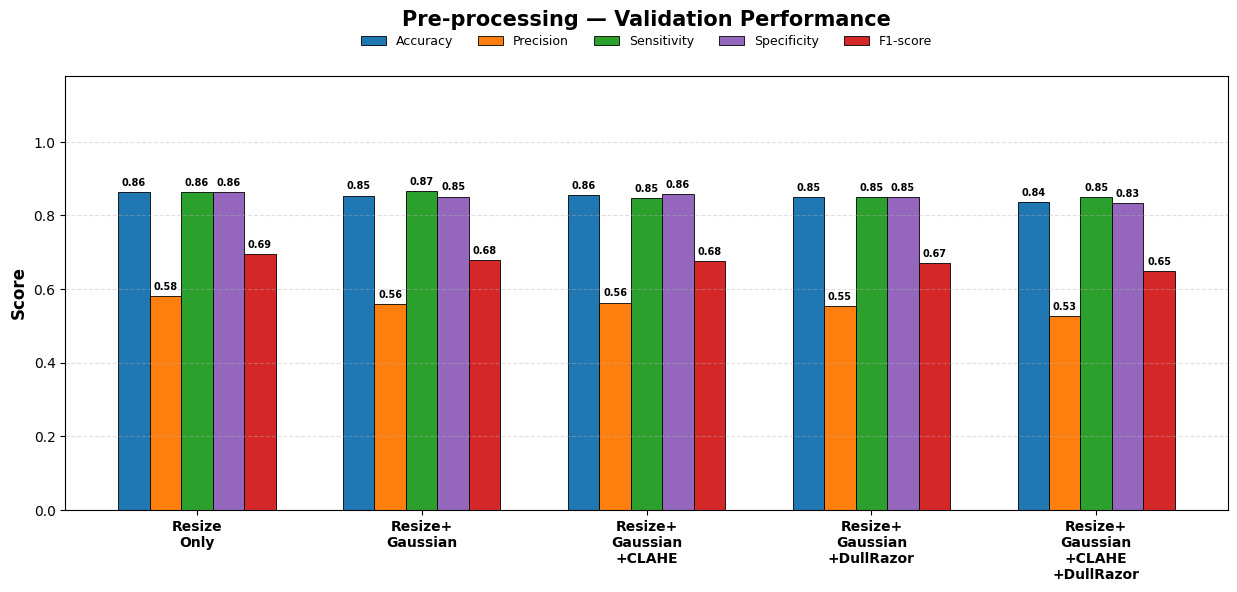

Saved: exp1_preprocessing_val.png


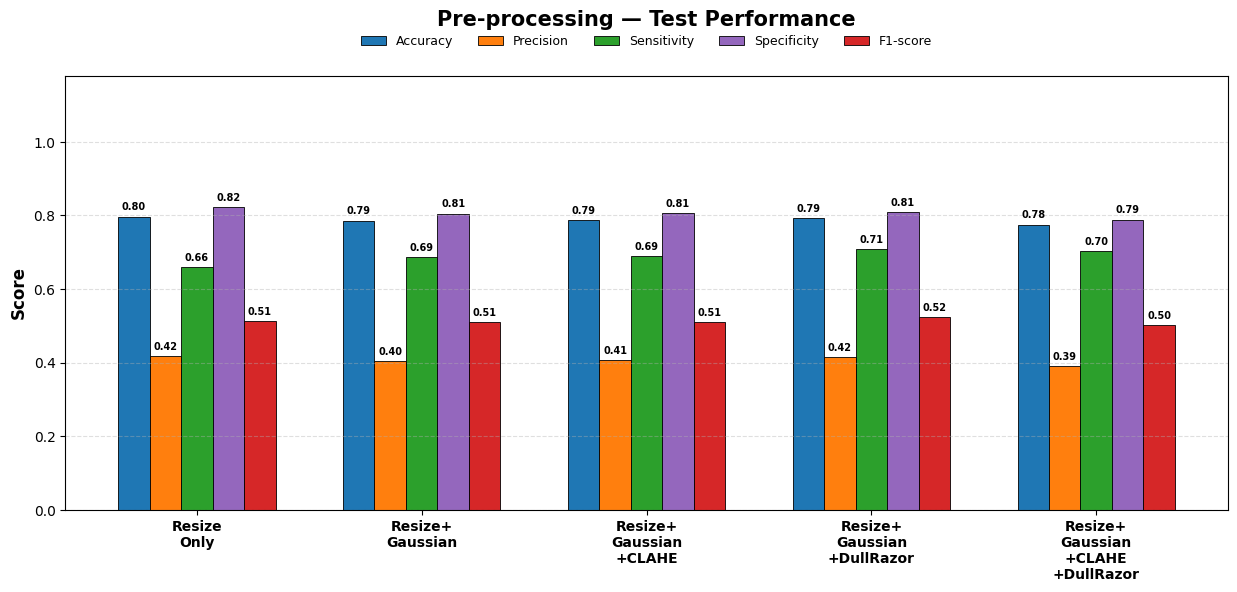

Saved: exp1_preprocessing_test.png


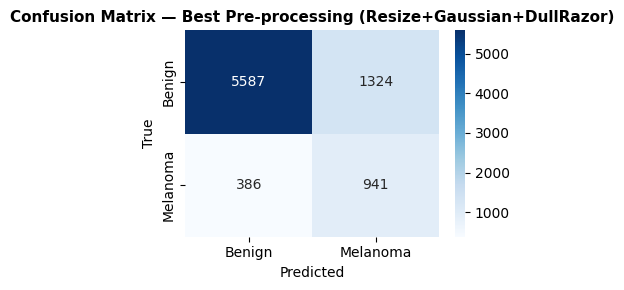

Saved: exp1_cm_best_preprocessing.png
Best pre-processing (F1 test): Resize+Gaussian+DullRazor


In [ ]:
short_prep = [
    "Resize\nOnly","Resize+\nGaussian","Resize+\nGaussian\n+CLAHE",
    "Resize+\nGaussian\n+DullRazor","Resize+\nGaussian\n+CLAHE\n+DullRazor"
]
grouped_barplot(df_prep_val,  "Pre-processing — Validation Performance",
    "exp1_preprocessing_val.png",  xticklabels=short_prep, figsize=(15,7))
grouped_barplot(df_prep_test, "Pre-processing — Test Performance",
    "exp1_preprocessing_test.png", xticklabels=short_prep, figsize=(15,7))

best_prep = df_prep_test["F1-score"].idxmax()
art = prep_artifacts[best_prep]
cm_plot(art["y_te"], art["y_te_pred"],
    f"Confusion Matrix — Best Pre-processing ({best_prep})",
    "exp1_cm_best_preprocessing.png")
print(f"Best pre-processing (F1 test): {best_prep}")


---
## Eksperimen 2 — Perbandingan Segmentasi

**Tujuan:** Mengukur pengaruh metode segmentasi terhadap performa klasifikasi.

| Metode | Keterangan |
|--------|-----------|
| No Segmentation | Seluruh gambar digunakan sebagai region (tanpa masking lesi) |
| Thresholding | Otsu + morfologi (dipakai di model final) |
| KMeans | K-Means clustering (K=3) |

- Pre-processing: Full (Resize+Gaussian+CLAHE+DullRazor)  |  Fitur: Hybrid  |  Seleksi: HHO  |  Klasifikasi: SVM
- Hyperparameter tuning → **Validation Set**  |  Laporan performa → **Test Set**


In [104]:
# ══════════════════════════════════════════════════════════════════
# EKSPERIMEN 2 — SEGMENTASI
# ══════════════════════════════════════════════════════════════════
SEG_METHODS = {
    # "No Segmentation": "none",
    "Thresholding":    "thresholding",
    "KMeans":          "kmeans",
}
DEFAULT_PREP = "resize+gaussian+clahe+dullrazor"

seg_val_results  = {}
seg_test_results = {}
seg_artifacts    = {}

for name, method in SEG_METHODS.items():
    print(f"\n{'='*60}\n  SEGMENTASI: {name}\n{'='*60}")

    print("[Train] extracting...")
    Xh_tr,Xd_tr,y_tr = extract_hybrid_exp(train_df,   TRAIN_IMG_DIR, preprocess_mode=DEFAULT_PREP, seg_method=method)
    print("[Val]   extracting...")
    Xh_va,Xd_va,y_va = extract_hybrid_exp(val_df,     TRAIN_IMG_DIR, preprocess_mode=DEFAULT_PREP, seg_method=method)
    print("[Test]  extracting...")
    Xh_te,Xd_te,y_te = extract_hybrid_exp(test_gt_df, TEST_IMG_DIR,  preprocess_mode=DEFAULT_PREP, seg_method=method)

    X_tr=np.hstack([Xh_tr,Xd_tr]); X_va=np.hstack([Xh_va,Xd_va]); X_te=np.hstack([Xh_te,Xd_te])

    sc=StandardScaler()
    X_tr=sc.fit_transform(clean_features(X_tr))
    X_va=sc.transform(clean_features(X_va))
    X_te=sc.transform(clean_features(X_te))

    print("[HHO] feature selection...")
    feat_mask=HHO_exp(X_tr,y_tr,n_hawks=N_HAWKS,max_iter=MAX_ITER)
    X_tr_s=X_tr[:,feat_mask==1]; X_va_s=X_va[:,feat_mask==1]; X_te_s=X_te[:,feat_mask==1]
    print(f"  Fitur terpilih: {np.sum(feat_mask)}/{len(feat_mask)}")

    svm=SVC(kernel="rbf",C=10,gamma="scale",class_weight="balanced",random_state=42)
    svm.fit(X_tr_s,y_tr)

    y_va_pred=svm.predict(X_va_s); y_te_pred=svm.predict(X_te_s)
    val_m=metrics_dict(y_va,y_va_pred); test_m=metrics_dict(y_te,y_te_pred)
    seg_val_results[name]=val_m; seg_test_results[name]=test_m
    seg_artifacts[name]=dict(y_te=y_te,y_te_pred=y_te_pred)

    print(f"  VAL  → Acc={val_m['Accuracy']:.4f} Prec={val_m['Precision']:.4f} Sens={val_m['Sensitivity']:.4f} Spec={val_m['Specificity']:.4f} F1={val_m['F1-score']:.4f}")
    print(f"  TEST → Acc={test_m['Accuracy']:.4f} Prec={test_m['Precision']:.4f} Sens={test_m['Sensitivity']:.4f} Spec={test_m['Specificity']:.4f} F1={test_m['F1-score']:.4f}")

df_seg_val  = pd.DataFrame(seg_val_results).T[METRIC_COLS]
df_seg_test = pd.DataFrame(seg_test_results).T[METRIC_COLS]
df_seg_val.to_csv(os.path.join(OUTPUT_DIR,"exp2_segmentasi_val.csv"))
df_seg_test.to_csv(os.path.join(OUTPUT_DIR,"exp2_segmentasi_test.csv"))
print("\n=== VALIDATION ==="); print(df_seg_val.round(4))
print("\n=== TEST ===");       print(df_seg_test.round(4))



  SEGMENTASI: Thresholding
[Train] extracting...


[Val]   extracting...


[Test]  extracting...


[HHO] feature selection...
  HHO iter 1/2 | best fitness: 0.7511
  HHO iter 2/2 | best fitness: 0.7511
  Fitur terpilih: 503/1052
  VAL  → Acc=0.8330 Prec=0.5201 Sens=0.8442 Spec=0.8306 F1=0.6436
  TEST → Acc=0.7821 Prec=0.3997 Sens=0.7031 Spec=0.7973 F1=0.5097

  SEGMENTASI: KMeans
[Train] extracting...


[Val]   extracting...


[Test]  extracting...


[HHO] feature selection...
  HHO iter 1/2 | best fitness: 0.7453
  HHO iter 2/2 | best fitness: 0.7453
  Fitur terpilih: 543/1052
  VAL  → Acc=0.8321 Prec=0.5184 Sens=0.8387 Spec=0.8306 F1=0.6408
  TEST → Acc=0.7826 Prec=0.4010 Sens=0.7084 Spec=0.7968 F1=0.5121

=== VALIDATION ===
              Accuracy  Precision  Sensitivity  Specificity  F1-score
Thresholding    0.8330     0.5201       0.8442       0.8306    0.6436
KMeans          0.8321     0.5184       0.8387       0.8306    0.6408

=== TEST ===
              Accuracy  Precision  Sensitivity  Specificity  F1-score
Thresholding    0.7821     0.3997       0.7031       0.7973    0.5097
KMeans          0.7826     0.4010       0.7084       0.7968    0.5121


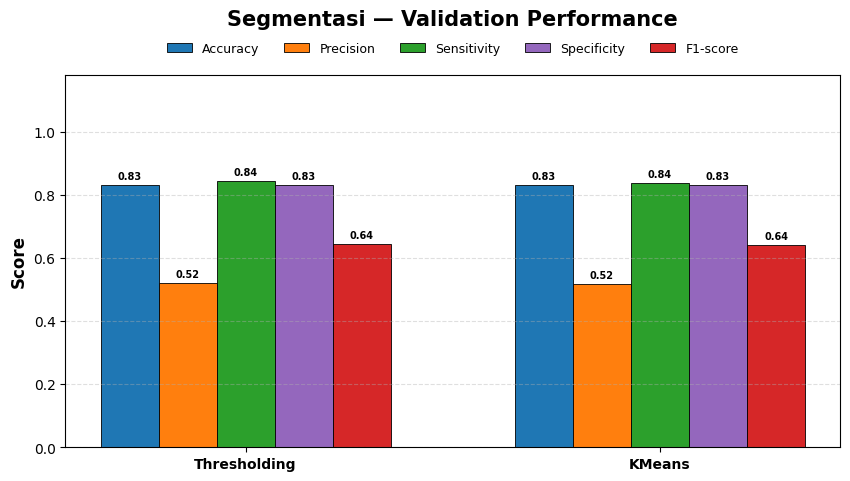

Saved: exp2_segmentasi_val.png


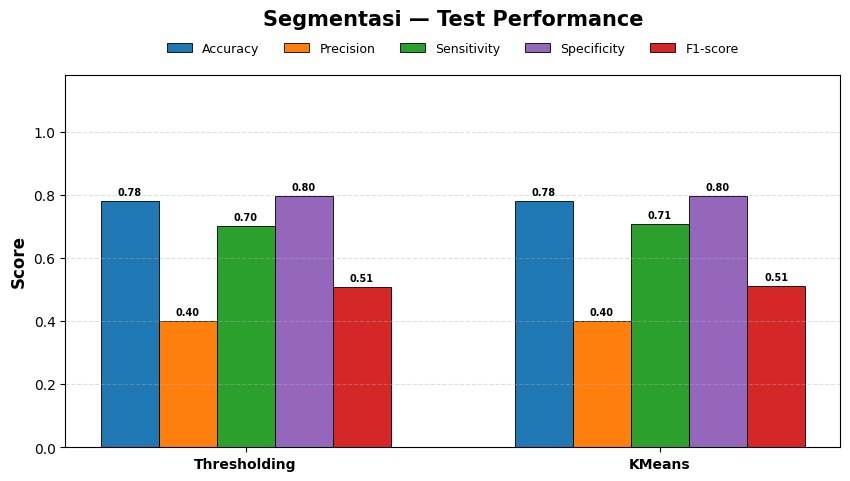

Saved: exp2_segmentasi_test.png


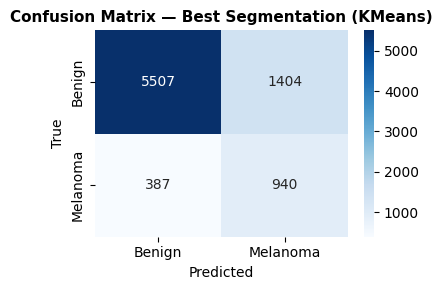

Saved: exp2_cm_best_segmentasi.png
Best segmentation (F1 test): KMeans


In [105]:
grouped_barplot(df_seg_val,  "Segmentasi — Validation Performance",
    "exp2_segmentasi_val.png",  figsize=(10,6))
grouped_barplot(df_seg_test, "Segmentasi — Test Performance",
    "exp2_segmentasi_test.png", figsize=(10,6))

best_seg = df_seg_test["F1-score"].idxmax()
art = seg_artifacts[best_seg]
cm_plot(art["y_te"], art["y_te_pred"],
    f"Confusion Matrix — Best Segmentation ({best_seg})",
    "exp2_cm_best_segmentasi.png")
print(f"Best segmentation (F1 test): {best_seg}")


---
## Eksperimen 3 — Ablation Fitur

**Tujuan:** Mengukur kontribusi masing-masing kelompok fitur terhadap performa klasifikasi.

| Skenario | Fitur |
|----------|-------|
| Shape only | Area, Perimeter, Compactness, Eccentricity, Solidity (5 fitur) |
| Texture only | GLCM (4) + LBP (10) = 14 fitur |
| Color only | Mean, Std, Skewness per channel RGB (9 fitur) |
| Handcrafted | Shape + Texture + Color (28 fitur) |
| Deep only | DenseNet121 features (1024 fitur) |
| Hybrid | Handcrafted + Deep (1052 fitur) |

- Pre-processing: Full  |  Segmentasi: Thresholding  |  Klasifikasi: SVM
- Evaluasi → **Test Set**

> Catatan: ablation study yang lebih lengkap (termasuk dengan HHO) ada di cell berikutnya.


In [ ]:
# ══════════════════════════════════════════════════════════════════
# EKSPERIMEN 3 — ABLATION FITUR
# ══════════════════════════════════════════════════════════════════
# Gunakan fitur yang sudah diekstrak di cell 38 (X_train_hand, X_val_hand,
# X_train_deep, X_val_deep) + ekstrak test set

print("Ekstraksi fitur test set untuk ablation...")
Xh_te_ab, Xd_te_ab, y_te_ab = extract_hybrid_exp(test_gt_df, TEST_IMG_DIR)

# Indeks fitur handcrafted: Shape(5) + GLCM(4) + LBP(10) + Color(9) = 28
N_SHAPE=5; N_GLCM=4; N_LBP=10; N_COLOR=9
shape_idx_ab   = list(range(0, N_SHAPE))
texture_idx_ab = list(range(N_SHAPE, N_SHAPE+N_GLCM+N_LBP))
color_idx_ab   = list(range(N_SHAPE+N_GLCM+N_LBP, N_SHAPE+N_GLCM+N_LBP+N_COLOR))

def ablation_eval(name, Xtr, Xva, Xte, y_tr, y_va, y_te):
    sc=StandardScaler()
    Xtr=sc.fit_transform(clean_features(Xtr))
    Xva=sc.transform(clean_features(Xva))
    Xte=sc.transform(clean_features(Xte))
    svm=SVC(kernel="rbf",C=10,gamma="scale",class_weight="balanced",random_state=42)
    svm.fit(Xtr,y_tr)
    val_m=metrics_dict(y_va,svm.predict(Xva))
    test_m=metrics_dict(y_te,svm.predict(Xte))
    y_te_pred=svm.predict(Xte)
    print(f"  {name:25s} | VAL  F1={val_m['F1-score']:.4f} | TEST F1={test_m['F1-score']:.4f}")
    return val_m, test_m, y_te_pred

feat_val_results  = {}
feat_test_results = {}
feat_preds_ab     = {}

# Pakai X_train_hand & X_val_hand dari cell 38, Xh_te_ab dari atas
scenarios = [
    ("Shape only",   X_train_hand[:,shape_idx_ab],   X_val_hand[:,shape_idx_ab],   Xh_te_ab[:,shape_idx_ab]),
    ("Texture only", X_train_hand[:,texture_idx_ab],  X_val_hand[:,texture_idx_ab],  Xh_te_ab[:,texture_idx_ab]),
    ("Color only",   X_train_hand[:,color_idx_ab],    X_val_hand[:,color_idx_ab],    Xh_te_ab[:,color_idx_ab]),
    ("Handcrafted",  X_train_hand,                    X_val_hand,                    Xh_te_ab),
    ("Deep only",    X_train_deep,                    X_val_deep,                    Xd_te_ab),
    ("Hybrid",       np.hstack([X_train_hand,X_train_deep]),
                     np.hstack([X_val_hand,  X_val_deep]),
                     np.hstack([Xh_te_ab,    Xd_te_ab])),
]

print(f"{'Scenario':25s}  VAL F1   TEST F1")
for name, Xtr, Xva, Xte in scenarios:
    vm, tm, preds = ablation_eval(name, Xtr, Xva, Xte, y_train, y_val, y_te_ab)
    feat_val_results[name]=vm; feat_test_results[name]=tm; feat_preds_ab[name]=preds

df_feat_val  = pd.DataFrame(feat_val_results).T[METRIC_COLS]
df_feat_test = pd.DataFrame(feat_test_results).T[METRIC_COLS]
df_feat_val.to_csv(os.path.join(OUTPUT_DIR,"exp3_fitur_val.csv"))
df_feat_test.to_csv(os.path.join(OUTPUT_DIR,"exp3_fitur_test.csv"))
print("\n=== VALIDATION ==="); print(df_feat_val.round(4))
print("\n=== TEST ===");       print(df_feat_test.round(4))


Ekstraksi fitur test set untuk ablation...


Scenario                   VAL F1   TEST F1
  Shape only                | VAL  F1=0.3321 | TEST F1=0.2849
  Texture only              | VAL  F1=0.4249 | TEST F1=0.4016
  Color only                | VAL  F1=0.4065 | TEST F1=0.3868
  Handcrafted               | VAL  F1=0.4790 | TEST F1=0.4364
  Deep only                 | VAL  F1=0.6573 | TEST F1=0.5161
  Hybrid                    | VAL  F1=0.6627 | TEST F1=0.5176

=== VALIDATION ===
              Accuracy  Precision  Sensitivity  Specificity  F1-score
Shape only      0.6150     0.2406       0.5359       0.6321    0.3321
Texture only    0.7190     0.3348       0.5812       0.7489    0.4249
Color only      0.6560     0.2938       0.6597       0.6552    0.4065
Handcrafted     0.7282     0.3642       0.6994       0.7345    0.4790
Deep only       0.8415     0.5355       0.8508       0.8395    0.6573
Hybrid          0.8441     0.5400       0.8575       0.8412    0.6627

=== TEST ===
              Accuracy  Precision  Sensitivity  Specificity 

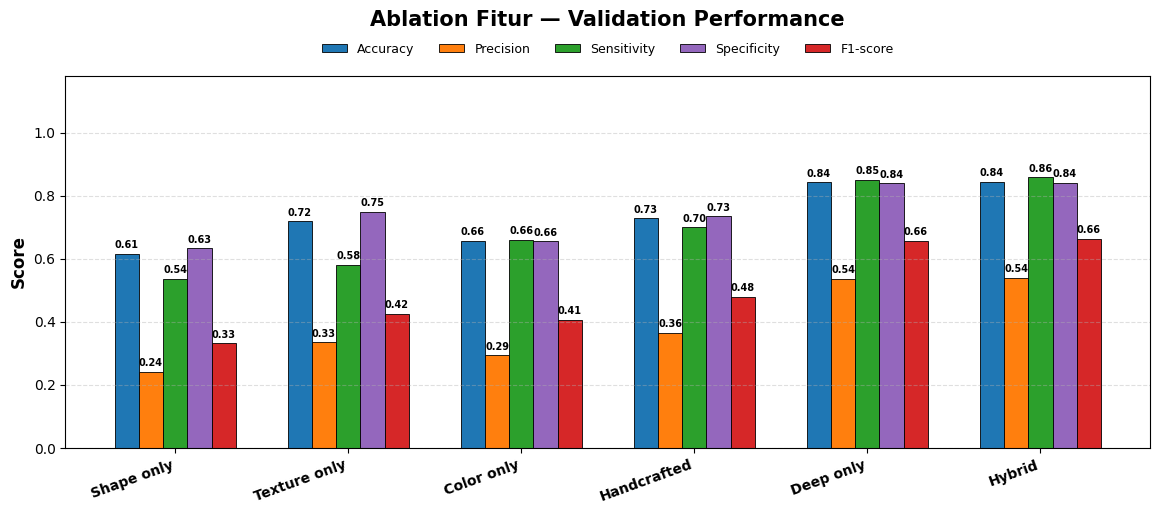

Saved: exp3_fitur_val.png


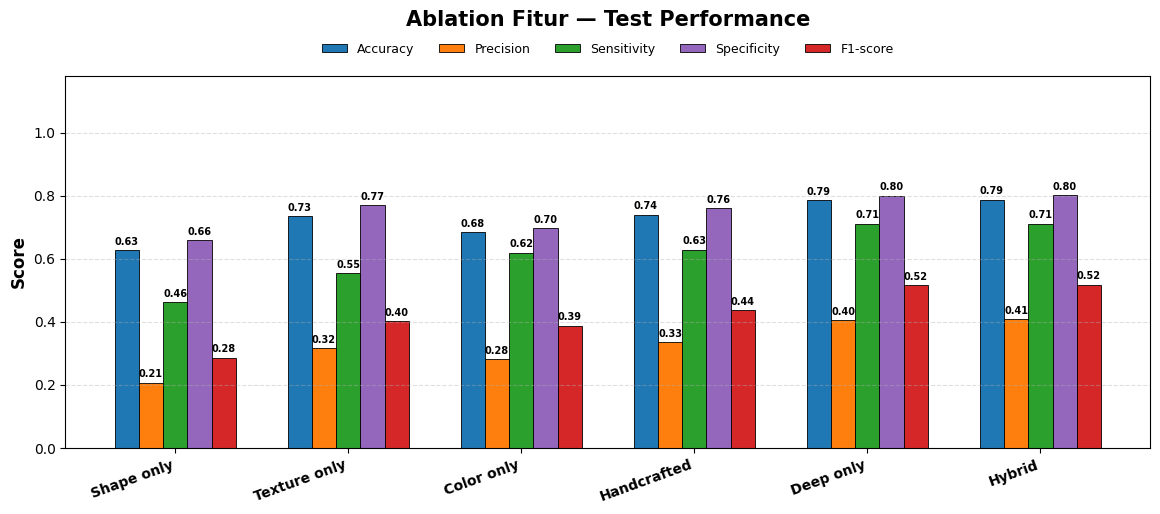

Saved: exp3_fitur_test.png


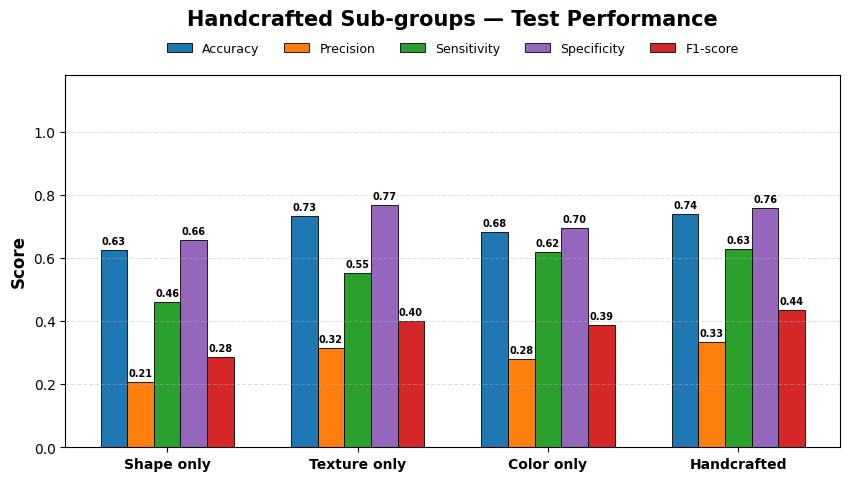

Saved: exp3_handcrafted_subgroup_test.png


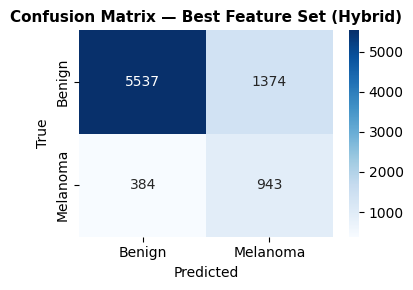

Saved: exp3_cm_best_fitur.png
Best feature set (F1 test): Hybrid


In [ ]:
grouped_barplot(df_feat_val,  "Ablation Fitur — Validation Performance",
    "exp3_fitur_val.png",  figsize=(14,6), rotation=20)
grouped_barplot(df_feat_test, "Ablation Fitur — Test Performance",
    "exp3_fitur_test.png", figsize=(14,6), rotation=20)

# Sub-group handcrafted saja
df_hc = df_feat_test.loc[["Shape only","Texture only","Color only","Handcrafted"]]
grouped_barplot(df_hc, "Handcrafted Sub-groups — Test Performance",
    "exp3_handcrafted_subgroup_test.png", figsize=(10,6))

best_feat = df_feat_test["F1-score"].idxmax()
cm_plot(y_te_ab, feat_preds_ab[best_feat],
    f"Confusion Matrix — Best Feature Set ({best_feat})",
    "exp3_cm_best_fitur.png")
print(f"Best feature set (F1 test): {best_feat}")


In [ ]:
print(train_df.columns)

print(train_df[["img_path"]].head())

print(train_df["img_path"].iloc[0])

Index(['image', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK',
       'label', 'img_path'],
      dtype='str')
                                            img_path
0  D:\S2\THESIS\DATASET\MELANOMA\ISIC_2019_Traini...
1  D:\S2\THESIS\DATASET\MELANOMA\ISIC_2019_Traini...
2  D:\S2\THESIS\DATASET\MELANOMA\ISIC_2019_Traini...
3  D:\S2\THESIS\DATASET\MELANOMA\ISIC_2019_Traini...
4  D:\S2\THESIS\DATASET\MELANOMA\ISIC_2019_Traini...
D:\S2\THESIS\DATASET\MELANOMA\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0030575.jpg


In [ ]:
# HHO PARAMETERS
N_HAWKS = 3
MAX_ITER = 2

# FITNESS FUNCTION
def fitness_function(feature_mask, X, y):

    if np.sum(feature_mask) == 0:
        return 0

    X_sel = X[:, feature_mask == 1]

    clf = SVC(kernel="linear", C=1.0, class_weight="balanced")

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    recall_scores, specificity_scores = [], []

    for train_idx, val_idx in cv.split(X_sel, y):
        clf.fit(X_sel[train_idx], y[train_idx])
        preds = clf.predict(X_sel[val_idx])
        recall_scores.append(recall_score(y[val_idx], preds, zero_division=0))
        tn, fp, fn, tp = confusion_matrix(y[val_idx], preds, labels=[0, 1]).ravel()
        specificity_scores.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    mean_recall = np.mean(recall_scores)
    mean_specificity = np.mean(specificity_scores)
    feature_ratio = np.sum(feature_mask) / len(feature_mask)

    # Recall-oriented objective sesuai tujuan medical screening.
    # Specificity tetap diberi bobot agar false positive tidak diabaikan total,
    # dan feature reduction mencegah fitur terlalu banyak.
    fitness = 0.70 * mean_recall + 0.20 * mean_specificity + 0.10 * (1 - feature_ratio)

    return fitness

# HHO
def HHO(X, y, n_hawks=10, max_iter=20):

    n_features = X.shape[1]
    hawks = np.random.randint(0, 2, size=(n_hawks, n_features))

    fitness_scores = np.array([
        fitness_function(hawk, X, y) for hawk in hawks
    ])

    best_idx = np.argmax(fitness_scores)
    best_hawk = hawks[best_idx].copy()
    best_score = fitness_scores[best_idx]

    for t in range(max_iter):
        E1 = 2 * (1 - (t / max_iter))

        for i in range(n_hawks):
            E0 = 2 * np.random.rand() - 1
            E = E1 * E0

            if abs(E) >= 1:
                rand_hawk = hawks[np.random.randint(n_hawks)]
                hawks[i] = rand_hawk ^ np.random.randint(0, 2, n_features)
            else:
                hawks[i] = best_hawk ^ (np.random.rand(n_features) > 0.5)

            score = fitness_function(hawks[i], X, y)

            if score > best_score:
                best_score = score
                best_hawk = hawks[i].copy()

        print(f"Iter {t+1}/{max_iter} | Best fitness: {best_score:.4f}")

    return best_hawk

# RUN HHO
best_feature_mask = HHO(
    X_train,
    y_train,
    n_hawks=N_HAWKS,
    max_iter=MAX_ITER
)

print("Jumlah fitur terpilih:", np.sum(best_feature_mask))

# APPLY MASK
X_train_sel = X_train[:, best_feature_mask == 1]
X_val_sel   = X_val[:, best_feature_mask == 1]

print("Selected train shape:", X_train_sel.shape)
print("Selected val shape:", X_val_sel.shape)

# EVALUATION FUNCTION
def evaluate_model(model, X_train, y_train, X_val, y_val):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec  = recall_score(y_val, y_pred)
    f1   = f1_score(y_val, y_pred)

    cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    print(classification_report(y_val, y_pred, target_names=["Benign", "Melanoma"]))
    print("Accuracy   :", acc)
    print("Precision  :", prec)
    print("Sensitivity:", rec)
    print("Specificity:", spec)
    print("F1-score   :", f1)

    return cm, acc, prec, rec, f1

# SVM
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
    random_state=42
)

cm_svm, acc_svm, prec_svm, rec_svm, f1_svm = evaluate_model(
    svm_model,
    X_train_sel, y_train,
    X_val_sel, y_val
)

# RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=42
)

cm_rf, acc_rf, prec_rf, rec_rf, f1_rf = evaluate_model(
    rf_model,
    X_train_sel, y_train,
    X_val_sel, y_val
)

# MLP
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=42
)

cm_mlp, acc_mlp, prec_mlp, rec_mlp, f1_mlp = evaluate_model(
    mlp_model,
    X_train_sel, y_train,
    X_val_sel, y_val
)

# XGBOOST
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False
)

cm_xgb, acc_xgb, prec_xgb, rec_xgb, f1_xgb = evaluate_model(
    xgb_model,
    X_train_sel, y_train,
    X_val_sel, y_val
)

# RESULTS TABLE
results = pd.DataFrame({
    "Model": ["SVM", "Random Forest", "MLP", "XGBoost"],
    "Accuracy": [acc_svm, acc_rf, acc_mlp, acc_xgb],
    "Precision": [prec_svm, prec_rf, prec_mlp, prec_xgb],
    "Sensitivity": [rec_svm, rec_rf, rec_mlp, rec_xgb],
    "F1-score": [f1_svm, f1_rf, f1_mlp, f1_xgb]
})

print(results)
results.to_csv(os.path.join(OUTPUT_DIR, "validation_model_comparison.csv"), index=False)
print("Saved:", os.path.join(OUTPUT_DIR, "validation_model_comparison.csv"))


Iter 1/2 | Best fitness: 0.7461
Iter 2/2 | Best fitness: 0.7461
Jumlah fitur terpilih: 512
Selected train shape: (14458, 512)
Selected val shape: (5067, 512)
              precision    recall  f1-score   support

      Benign       0.96      0.84      0.90      4162
    Melanoma       0.53      0.84      0.65       905

    accuracy                           0.84      5067
   macro avg       0.75      0.84      0.77      5067
weighted avg       0.88      0.84      0.85      5067

Accuracy   : 0.8393526741661733
Precision  : 0.5319298245614035
Sensitivity: 0.8375690607734807
Specificity: 0.8397405093704949
F1-score   : 0.6506437768240343
              precision    recall  f1-score   support

      Benign       0.93      0.80      0.86      4162
    Melanoma       0.45      0.74      0.56       905

    accuracy                           0.79      5067
   macro avg       0.69      0.77      0.71      5067
weighted avg       0.85      0.79      0.81      5067

Accuracy   : 0.7915926583777

In [44]:
# HHO PARAMETERS
N_HAWKS = 3
MAX_ITER = 2

# FITNESS FUNCTION
def fitness_function(feature_mask, X, y):

    if np.sum(feature_mask) == 0:
        return 0

    X_sel = X[:, feature_mask == 1]

    clf = SVC(kernel="linear", C=1.0, class_weight="balanced")

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    recall_scores, specificity_scores = [], []

    for train_idx, val_idx in cv.split(X_sel, y):
        clf.fit(X_sel[train_idx], y[train_idx])
        preds = clf.predict(X_sel[val_idx])
        recall_scores.append(recall_score(y[val_idx], preds, zero_division=0))
        tn, fp, fn, tp = confusion_matrix(y[val_idx], preds, labels=[0, 1]).ravel()
        specificity_scores.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    mean_recall = np.mean(recall_scores)
    mean_specificity = np.mean(specificity_scores)
    feature_ratio = np.sum(feature_mask) / len(feature_mask)

    # Recall-oriented objective sesuai tujuan medical screening.
    # Specificity tetap diberi bobot agar false positive tidak diabaikan total,
    # dan feature reduction mencegah fitur terlalu banyak.
    fitness = 0.70 * mean_recall + 0.20 * mean_specificity + 0.10 * (1 - feature_ratio)

    return fitness

# HHO
def HHO(X, y, n_hawks=10, max_iter=20):

    n_features = X.shape[1]
    hawks = np.random.randint(0, 2, size=(n_hawks, n_features))

    fitness_scores = np.array([
        fitness_function(hawk, X, y) for hawk in hawks
    ])

    best_idx = np.argmax(fitness_scores)
    best_hawk = hawks[best_idx].copy()
    best_score = fitness_scores[best_idx]

    for t in range(max_iter):
        E1 = 2 * (1 - (t / max_iter))

        for i in range(n_hawks):
            E0 = 2 * np.random.rand() - 1
            E = E1 * E0

            if abs(E) >= 1:
                rand_hawk = hawks[np.random.randint(n_hawks)]
                hawks[i] = rand_hawk ^ np.random.randint(0, 2, n_features)
            else:
                hawks[i] = best_hawk ^ (np.random.rand(n_features) > 0.5)

            score = fitness_function(hawks[i], X, y)

            if score > best_score:
                best_score = score
                best_hawk = hawks[i].copy()

        print(f"Iter {t+1}/{max_iter} | Best fitness: {best_score:.4f}")

    return best_hawk

# RUN HHO
best_feature_mask = HHO(
    X_train,
    y_train,
    n_hawks=N_HAWKS,
    max_iter=MAX_ITER
)

print("Jumlah fitur terpilih:", np.sum(best_feature_mask))

# APPLY MASK
X_train_sel = X_train[:, best_feature_mask == 1]
X_val_sel   = X_val[:, best_feature_mask == 1]

print("Selected train shape:", X_train_sel.shape)
print("Selected val shape:", X_val_sel.shape)

# EVALUATION FUNCTION
def evaluate_model(model, X_train, y_train, X_val, y_val):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec  = recall_score(y_val, y_pred)
    f1   = f1_score(y_val, y_pred)

    cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    print(classification_report(y_val, y_pred, target_names=["Benign", "Melanoma"]))
    print("Accuracy   :", acc)
    print("Precision  :", prec)
    print("Sensitivity:", rec)
    print("Specificity:", spec)
    print("F1-score   :", f1)

    return cm, acc, prec, rec, f1

# SVM
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
    random_state=42
)

cm_svm, acc_svm, prec_svm, rec_svm, f1_svm = evaluate_model(
    svm_model,
    X_train_sel, y_train,
    X_val_sel, y_val
)

# # RANDOM FOREST
# from sklearn.ensemble import RandomForestClassifier

# rf_model = RandomForestClassifier(
#     n_estimators=200,
#     max_depth=None,
#     class_weight="balanced",
#     random_state=42
# )

# cm_rf, acc_rf, prec_rf, rec_rf, f1_rf = evaluate_model(
#     rf_model,
#     X_train_sel, y_train,
#     X_val_sel, y_val
# )

# # MLP
# from sklearn.neural_network import MLPClassifier

# mlp_model = MLPClassifier(
#     hidden_layer_sizes=(256, 128),
#     activation="relu",
#     solver="adam",
#     max_iter=300,
#     random_state=42
# )

# cm_mlp, acc_mlp, prec_mlp, rec_mlp, f1_mlp = evaluate_model(
#     mlp_model,
#     X_train_sel, y_train,
#     X_val_sel, y_val
# )

# # XGBOOST
# xgb_model = XGBClassifier(
#     n_estimators=300,
#     max_depth=6,
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     eval_metric="logloss",
#     random_state=42,
#     use_label_encoder=False
# )

# cm_xgb, acc_xgb, prec_xgb, rec_xgb, f1_xgb = evaluate_model(
#     xgb_model,
#     X_train_sel, y_train,
#     X_val_sel, y_val
# )

# RESULTS TABLE
results = pd.DataFrame({
    "Model": ["SVM"],
    "Accuracy": [acc_svm],
    "Precision": [prec_svm],
    "Sensitivity": [rec_svm],
    "F1-score": [f1_svm]
})

print(results)
results.to_csv(os.path.join(OUTPUT_DIR, "validation_model_comparison.csv"), index=False)
print("Saved:", os.path.join(OUTPUT_DIR, "validation_model_comparison.csv"))


Iter 1/2 | Best fitness: 0.7486
Iter 2/2 | Best fitness: 0.7486
Jumlah fitur terpilih: 536
Selected train shape: (14458, 536)
Selected val shape: (5067, 536)
              precision    recall  f1-score   support

      Benign       0.96      0.83      0.89      4162
    Melanoma       0.52      0.83      0.64       905

    accuracy                           0.83      5067
   macro avg       0.74      0.83      0.77      5067
weighted avg       0.88      0.83      0.85      5067

Accuracy   : 0.8328399447404776
Precision  : 0.5199724517906336
Sensitivity: 0.8342541436464088
Specificity: 0.8325324363286881
F1-score   : 0.6406448875689436
  Model  Accuracy  Precision  Sensitivity  F1-score
0   SVM   0.83284   0.519972     0.834254  0.640645
Saved: D:\S2\THESIS\DATASET\MELANOMA\output\validation_model_comparison.csv


---
## Eksperimen 4a — Hyperparameter Tuning per Model

**Tujuan:** Menemukan hyperparameter terbaik untuk masing-masing model.

**Evaluasi di: Validation Set** — test set tidak boleh terlihat saat tuning.

| Model | Parameter yang di-tuning |
|-------|--------------------------|
| SVM | C: {0.1, 1, 10, 50} |
| Random Forest | n_estimators: {50, 100, 200} |
| MLP | hidden layers: {(64,), (128,64), (256,128)} |
| XGBoost | max_depth: {3, 6, 10} |


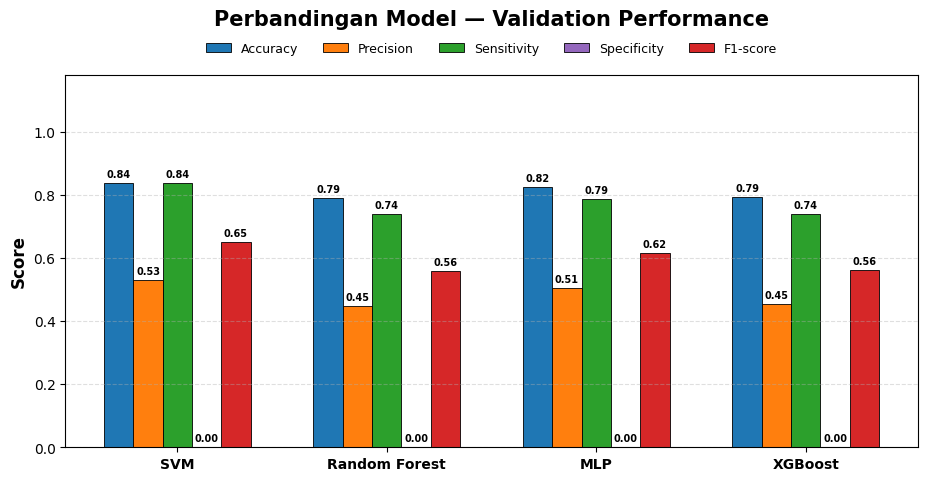

Saved: exp4a_model_comparison_val.png


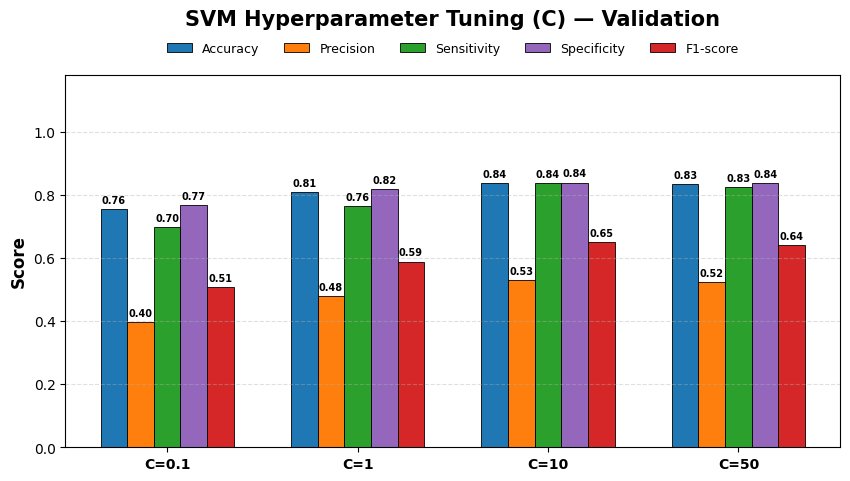

Saved: exp4a_svm_tuning_val.png
Best SVM C: C=10


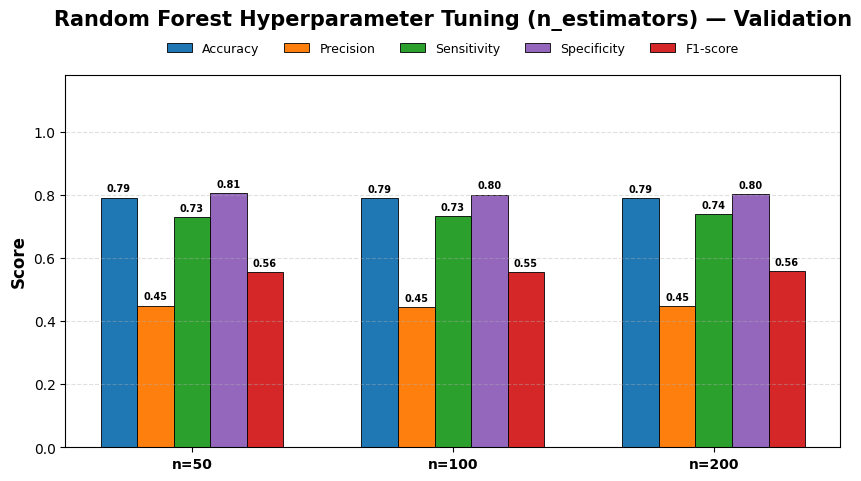

Saved: exp4a_rf_tuning_val.png
Best RF n: n=200


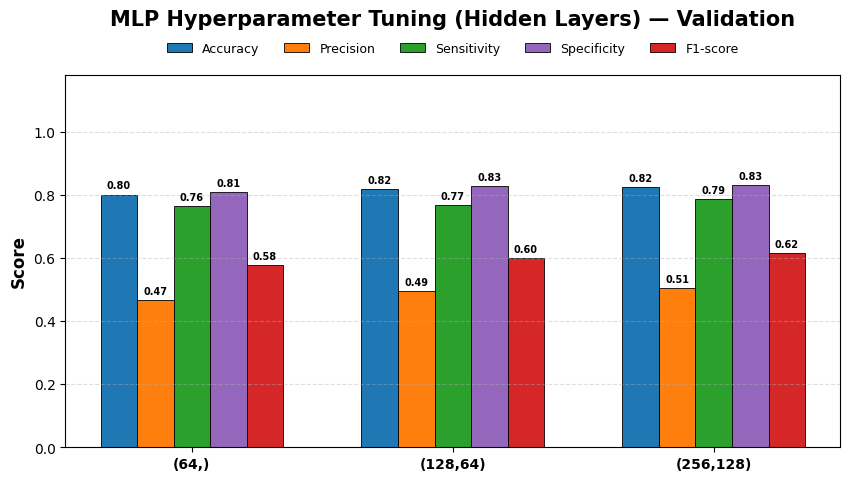

Saved: exp4a_mlp_tuning_val.png
Best MLP layers: (256,128)


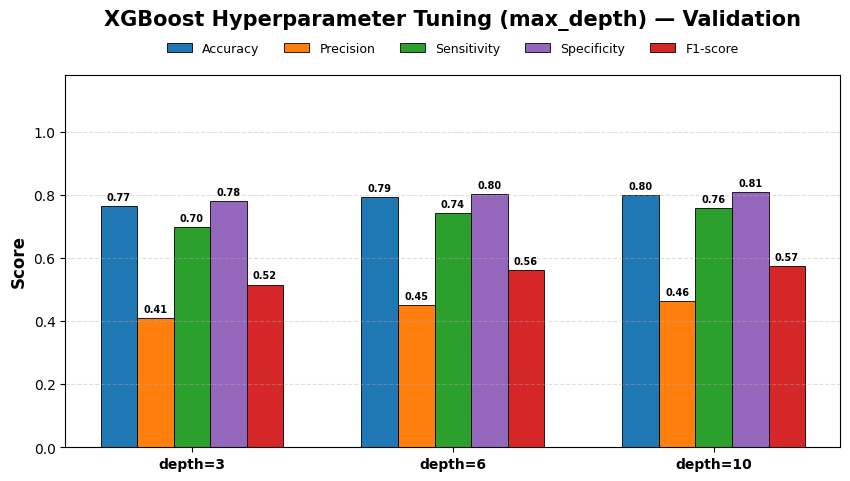

Saved: exp4a_xgb_tuning_val.png
Best XGB depth: depth=10

Simpan best params:
  SVM C=C=10, RF n=n=200, MLP=(256,128), XGB depth=depth=10


In [ ]:
# ── Visualisasi ringkasan 4 model dari VAL (cell 40) ─────────────────────
# results DataFrame sudah ada dari cell 40
df_model_val = results.copy()
df_model_val = df_model_val.rename(columns={"Sensitivity":"Sensitivity","F1-score":"F1-score"})
# Pastikan kolom sesuai METRIC_COLS
for col in METRIC_COLS:
    if col not in df_model_val.columns:
        df_model_val[col] = 0.0
df_model_val = df_model_val.set_index("Model")[METRIC_COLS]

grouped_barplot(df_model_val, "Perbandingan Model — Validation Performance",
    "exp4a_model_comparison_val.png", figsize=(11,6))

# Hyperparameter SVM
svm_tune = {}
for C in [0.1,1,10,50]:
    m_tmp=SVC(kernel="rbf",C=C,gamma="scale",class_weight="balanced",random_state=42)
    m_tmp.fit(X_train_sel,y_train); pred=m_tmp.predict(X_val_sel)
    svm_tune[f"C={C}"]=metrics_dict(y_val,pred)
df_svm_tune=pd.DataFrame(svm_tune).T[METRIC_COLS]
df_svm_tune.to_csv(os.path.join(OUTPUT_DIR,"exp4a_svm_tuning_val.csv"))
grouped_barplot(df_svm_tune,"SVM Hyperparameter Tuning (C) — Validation",
    "exp4a_svm_tuning_val.png",figsize=(10,6))
best_C_v=df_svm_tune["F1-score"].idxmax(); print(f"Best SVM C: {best_C_v}")

# Hyperparameter RF
rf_tune={}
for n in [50,100,200]:
    m_tmp=RandomForestClassifier(n_estimators=n,class_weight="balanced",random_state=42)
    m_tmp.fit(X_train_sel,y_train); pred=m_tmp.predict(X_val_sel)
    rf_tune[f"n={n}"]=metrics_dict(y_val,pred)
df_rf_tune=pd.DataFrame(rf_tune).T[METRIC_COLS]
df_rf_tune.to_csv(os.path.join(OUTPUT_DIR,"exp4a_rf_tuning_val.csv"))
grouped_barplot(df_rf_tune,"Random Forest Hyperparameter Tuning (n_estimators) — Validation",
    "exp4a_rf_tuning_val.png",figsize=(10,6))
best_n_v=df_rf_tune["F1-score"].idxmax(); print(f"Best RF n: {best_n_v}")

# Hyperparameter MLP
mlp_configs={"(64,)":(64,),"(128,64)":(128,64),"(256,128)":(256,128)}
mlp_tune={}
for label,layers in mlp_configs.items():
    m_tmp=MLPClassifier(hidden_layer_sizes=layers,max_iter=300,random_state=42)
    m_tmp.fit(X_train_sel,y_train); pred=m_tmp.predict(X_val_sel)
    mlp_tune[label]=metrics_dict(y_val,pred)
df_mlp_tune=pd.DataFrame(mlp_tune).T[METRIC_COLS]
df_mlp_tune.to_csv(os.path.join(OUTPUT_DIR,"exp4a_mlp_tuning_val.csv"))
grouped_barplot(df_mlp_tune,"MLP Hyperparameter Tuning (Hidden Layers) — Validation",
    "exp4a_mlp_tuning_val.png",figsize=(10,6))
best_layers_v=df_mlp_tune["F1-score"].idxmax(); print(f"Best MLP layers: {best_layers_v}")

# Hyperparameter XGBoost
xgb_tune={}
for d in [3,6,10]:
    m_tmp=XGBClassifier(n_estimators=200,max_depth=d,learning_rate=0.1,
                        eval_metric="logloss",random_state=42)
    m_tmp.fit(X_train_sel,y_train); pred=m_tmp.predict(X_val_sel)
    xgb_tune[f"depth={d}"]=metrics_dict(y_val,pred)
df_xgb_tune=pd.DataFrame(xgb_tune).T[METRIC_COLS]
df_xgb_tune.to_csv(os.path.join(OUTPUT_DIR,"exp4a_xgb_tuning_val.csv"))
grouped_barplot(df_xgb_tune,"XGBoost Hyperparameter Tuning (max_depth) — Validation",
    "exp4a_xgb_tuning_val.png",figsize=(10,6))
best_depth_v=df_xgb_tune["F1-score"].idxmax(); print(f"Best XGB depth: {best_depth_v}")

print("\nSimpan best params:")
print(f"  SVM C={best_C_v}, RF n={best_n_v}, MLP={best_layers_v}, XGB depth={best_depth_v}")


In [ ]:
print(test_gt_df.columns)

Index(['image', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK',
       'score_weight', 'validation_weight', 'label', 'img_path'],
      dtype='str')


100%|██████████| 8238/8238 [14:57<00:00,  9.18it/s]


              precision    recall  f1-score   support

      Benign       0.94      0.80      0.86      6911
    Melanoma       0.41      0.71      0.52      1327

    accuracy                           0.79      8238
   macro avg       0.67      0.76      0.69      8238
weighted avg       0.85      0.79      0.81      8238

   Accuracy  Precision  Sensitivity  Specificity  F1-score    TN    FP   FN  \
0  0.785142   0.405301     0.714393     0.798727  0.517185  5520  1391  379   

    TP  
0  948  


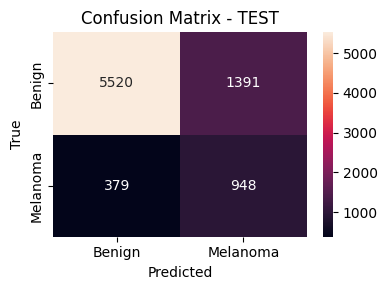

          image  MEL   NV  BCC   AK  BKL   DF  VASC  SCC  UNK  score_weight  \
0  ISIC_0034321  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0           0.0   
1  ISIC_0034322  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0           0.0   
2  ISIC_0034323  0.0  0.0  1.0  0.0  0.0  0.0   0.0  0.0  0.0           0.0   
3  ISIC_0034324  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0           0.0   
4  ISIC_0034325  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0           0.0   

   validation_weight  label  \
0                1.0    0.0   
1                1.0    0.0   
2                1.0    0.0   
3                1.0    0.0   
4                1.0    0.0   

                                            img_path  y_true  y_pred  \
0  D:\S2\THESIS\DATASET\MELANOMA\ISIC_2019_Test_I...     0.0     0.0   
1  D:\S2\THESIS\DATASET\MELANOMA\ISIC_2019_Test_I...     0.0     0.0   
2  D:\S2\THESIS\DATASET\MELANOMA\ISIC_2019_Test_I...     0.0     0.0   
3  D:\S2\THESIS\DATASET\MELANOMA\ISIC_2019_Test_I.

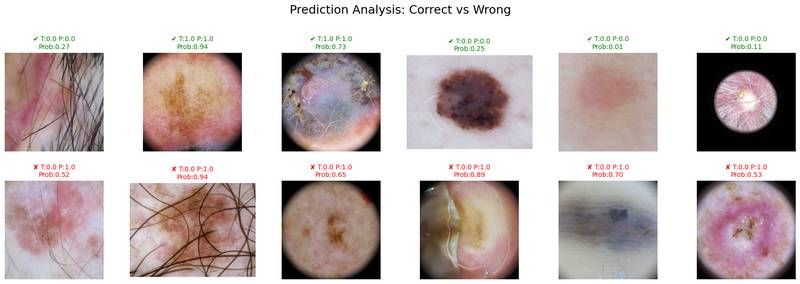

False Positive: 1391
           image  prob_melanoma
5   ISIC_0034326       0.567423
10  ISIC_0034332       0.772448
24  ISIC_0034346       0.800552
28  ISIC_0034350       0.545180
36  ISIC_0034360       0.589670
Saved: D:\S2\THESIS\DATASET\MELANOMA\prediction_analysis.csv


In [ ]:
# TEST SET EVALUATION - robust alignment between features, labels, and image IDs
# This fixes the old risk where missing images could desynchronize results_df and predictions.

test_gt_df = test_gt_df.copy()
test_gt_df["img_path"] = test_gt_df["image"].apply(lambda x: os.path.join(TEST_IMG_DIR, x + ".jpg"))

X_test_handcrafted, y_test_hand, test_rows_hand = extract_handcrafted_features_from_df(
    test_gt_df, TEST_IMG_DIR, return_rows=True
)
X_test_deep, y_test_deep, test_rows_deep = extract_deep_features_from_df(
    test_rows_hand, TEST_IMG_DIR, return_rows=True
)

# Align using rows successfully processed by both handcrafted and deep feature extraction.
y_test = np.array(y_test_deep)
test_rows = test_rows_deep.reset_index(drop=True)

if len(X_test_handcrafted) != len(X_test_deep):
    print("WARNING: handcrafted/deep feature count mismatch:", len(X_test_handcrafted), len(X_test_deep))
    min_len = min(len(X_test_handcrafted), len(X_test_deep))
    X_test_handcrafted = X_test_handcrafted[:min_len]
    X_test_deep = X_test_deep[:min_len]
    y_test = y_test[:min_len]
    test_rows = test_rows.iloc[:min_len].copy()

# FUSION TEST
X_test = np.hstack([X_test_handcrafted, X_test_deep])
X_test = clean_features(X_test)

# NORMALIZE TEST
X_test = scaler.transform(X_test)

# APPLY MASK TEST
X_test_sel = X_test[:, best_feature_mask == 1]

# FINAL MODEL (SVM)
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_sel, y_train)

y_test_pred = svm_model.predict(X_test_sel)
y_test_proba = svm_model.predict_proba(X_test_sel)[:, 1]

print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Benign", "Melanoma"],
    zero_division=0
))

# CONFUSION MATRIX
cm_test = confusion_matrix(y_test, y_test_pred, labels=[0, 1])

tn, fp, fn, tp = cm_test.ravel()
test_metrics = pd.DataFrame([{
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred, zero_division=0),
    "Sensitivity": recall_score(y_test, y_test_pred, zero_division=0),
    "Specificity": tn/(tn+fp) if (tn+fp)>0 else 0,
    "F1-score": f1_score(y_test, y_test_pred, zero_division=0),
    "TN": tn, "FP": fp, "FN": fn, "TP": tp
}])
print(test_metrics)
test_metrics.to_csv(os.path.join(OUTPUT_DIR, "test_metrics_isic2019.csv"), index=False)

plt.figure(figsize=(4,3))
sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    xticklabels=["Benign", "Melanoma"],
    yticklabels=["Benign", "Melanoma"]
)
plt.title("Confusion Matrix - TEST")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_test_isic2019.png"), dpi=200, bbox_inches="tight")
plt.show()

# SAVE RESULT
results_df = test_rows.copy()
results_df["y_true"] = y_test
results_df["y_pred"] = y_test_pred
results_df["prob_melanoma"] = y_test_proba
results_df["status"] = np.where(results_df["y_true"] == results_df["y_pred"], "Correct", "Wrong")

print(results_df.head())

# VISUALIZATION
def visualize_predictions(df, img_dir=None, n=6):
    correct = df[df["status"] == "Correct"]
    wrong   = df[df["status"] == "Wrong"]
    n = min(n, len(correct), len(wrong))
    if n == 0:
        print("Tidak cukup contoh correct/wrong untuk visualisasi.")
        return
    correct = correct.sample(n, random_state=42)
    wrong   = wrong.sample(n, random_state=42)
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    fig.suptitle("Prediction Analysis: Correct vs Wrong", fontsize=18, y=1.02)
    for i, (_, row) in enumerate(correct.iterrows()):
        img_path = row["img_path"]
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(img)
        axes[0, i].set_title(f"✔ T:{row['y_true']} P:{row['y_pred']}\nProb:{row['prob_melanoma']:.2f}", fontsize=10, color="green")
        axes[0, i].axis("off")
    for i, (_, row) in enumerate(wrong.iterrows()):
        img_path = row["img_path"]
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        axes[1, i].imshow(img)
        axes[1, i].set_title(f"✘ T:{row['y_true']} P:{row['y_pred']}\nProb:{row['prob_melanoma']:.2f}", fontsize=10, color="red")
        axes[1, i].axis("off")
    plt.subplots_adjust(left=0.02, right=0.98, top=0.85, bottom=0.05, wspace=0.1, hspace=0.3)
    plt.savefig(os.path.join(OUTPUT_DIR, "prediction_correct_vs_wrong.png"), dpi=200, bbox_inches="tight")
    plt.show()

visualize_predictions(results_df, n=6)

# FALSE POSITIVE
false_positive = results_df[(results_df["y_true"] == 0) & (results_df["y_pred"] == 1)]
print("False Positive:", len(false_positive))
print(false_positive[["image", "prob_melanoma"]].head())

# SAVE CSV
results_df.to_csv(os.path.join(OUTPUT_DIR, "prediction_analysis.csv"), index=False)
print("Saved:", os.path.join(OUTPUT_DIR, "prediction_analysis.csv"))


---
## Eksperimen 4b — Performa Final Model (Test Set)

**Tujuan:** Membandingkan performa keempat model dengan **parameter terbaik** hasil tuning, dievaluasi di **Test Set**.

> Ini adalah hasil final yang dilaporkan dalam tesis.


In [ ]:
# ══════════════════════════════════════════════════════════════════
# EKSPERIMEN 4b — PERFORMA FINAL MODEL (TEST SET)
# Parameter terbaik dari tuning di atas
# ══════════════════════════════════════════════════════════════════
best_C_num      = float(best_C_v.split("=")[1])
best_n_num      = int(best_n_v.split("=")[1])
best_layers_tup = mlp_configs[best_layers_v]
best_depth_num  = int(best_depth_v.split("=")[1])

print(f"Parameter terbaik dari tuning:")
print(f"  SVM    C           = {best_C_num}")
print(f"  RF     n_estimators = {best_n_num}")
print(f"  MLP    layers      = {best_layers_tup}")
print(f"  XGBoost max_depth  = {best_depth_num}")

final_models = {
    "SVM"          : SVC(kernel="rbf",C=best_C_num,gamma="scale",class_weight="balanced",random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=best_n_num,class_weight="balanced",random_state=42),
    "MLP"          : MLPClassifier(hidden_layer_sizes=best_layers_tup,max_iter=300,random_state=42),
    "XGBoost"      : XGBClassifier(n_estimators=200,max_depth=best_depth_num,learning_rate=0.1,
                                   eval_metric="logloss",random_state=42),
}

# Test features (sudah ada dari cell 42: X_test_sel, y_test)
model_test_results = {}
model_test_preds   = {}

print("\n=== FINAL MODEL — Test Performance ===")
for name, model in final_models.items():
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    m = metrics_dict(y_test, y_pred)
    model_test_results[name]=m; model_test_preds[name]=y_pred
    print(f"  {name:15s} | Acc={m['Accuracy']:.4f} Prec={m['Precision']:.4f} Sens={m['Sensitivity']:.4f} Spec={m['Specificity']:.4f} F1={m['F1-score']:.4f}")

df_model_test=pd.DataFrame(model_test_results).T[METRIC_COLS]
df_model_test.to_csv(os.path.join(OUTPUT_DIR,"exp4b_model_final_test.csv"))
print("\n=== TEST RESULTS (FINAL) ===")
print(df_model_test.round(4))


Parameter terbaik dari tuning:
  SVM    C           = 10.0
  RF     n_estimators = 200
  MLP    layers      = (256, 128)
  XGBoost max_depth  = 10

=== FINAL MODEL — Test Performance ===
  SVM             | Acc=0.7851 Prec=0.4053 Sens=0.7144 Spec=0.7987 F1=0.5172
  Random Forest   | Acc=0.7802 Prec=0.3957 Sens=0.6918 Spec=0.7971 F1=0.5034
  MLP             | Acc=0.7669 Prec=0.3777 Sens=0.6903 Spec=0.7817 F1=0.4883
  XGBoost         | Acc=0.7764 Prec=0.3889 Sens=0.6790 Spec=0.7951 F1=0.4945

=== TEST RESULTS (FINAL) ===
               Accuracy  Precision  Sensitivity  Specificity  F1-score
SVM              0.7851     0.4053       0.7144       0.7987    0.5172
Random Forest    0.7802     0.3957       0.6918       0.7971    0.5034
MLP              0.7669     0.3777       0.6903       0.7817    0.4883
XGBoost          0.7764     0.3889       0.6790       0.7951    0.4945


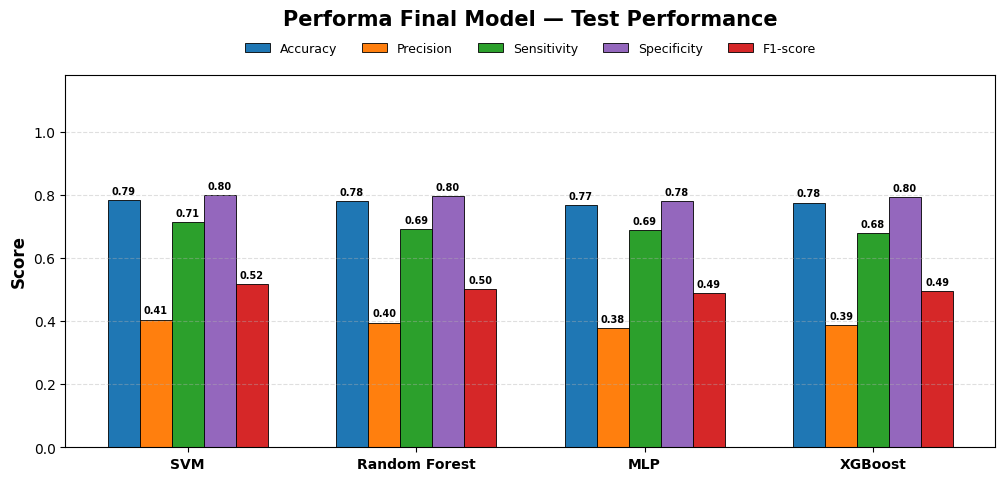

Saved: exp4b_model_final_test.png


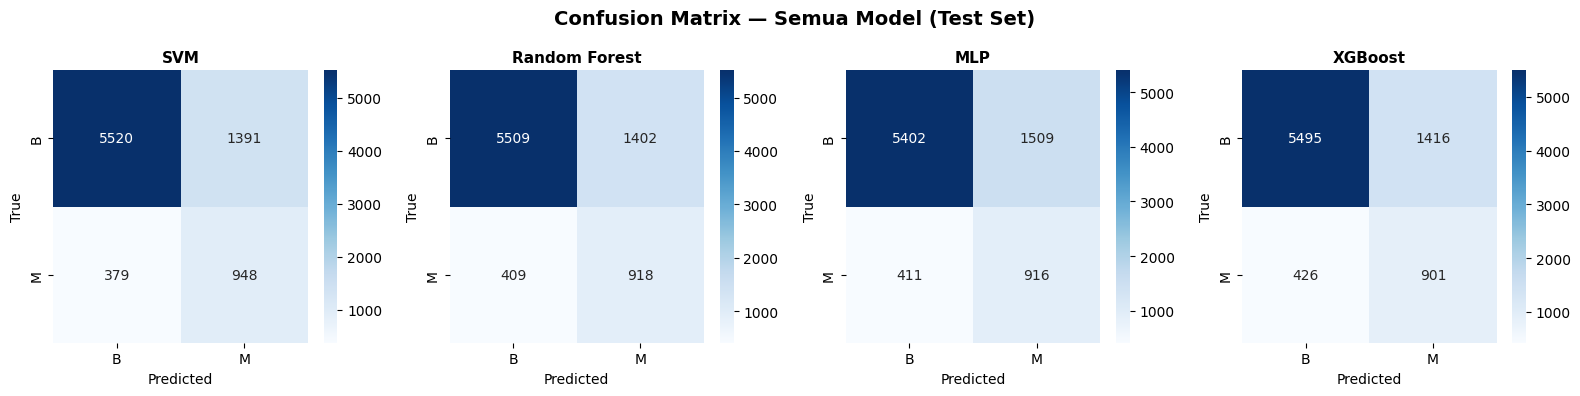

Saved: exp4b_cm_all_models.png

Best model (F1 test): SVM
              precision    recall  f1-score   support

      Benign       0.94      0.80      0.86      6911
    Melanoma       0.41      0.71      0.52      1327

    accuracy                           0.79      8238
   macro avg       0.67      0.76      0.69      8238
weighted avg       0.85      0.79      0.81      8238



In [ ]:
grouped_barplot(df_model_test, "Performa Final Model — Test Performance",
    "exp4b_model_final_test.png", figsize=(12,6))

# Confusion matrix semua model
fig,axes=plt.subplots(1,4,figsize=(16,4))
fig.suptitle("Confusion Matrix — Semua Model (Test Set)",fontsize=14,fontweight="bold")
for ax,(name,y_pred) in zip(axes,model_test_preds.items()):
    cm=confusion_matrix(y_test,y_pred,labels=[0,1])
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",ax=ax,
                xticklabels=["B","M"],yticklabels=["B","M"])
    ax.set_title(name,fontsize=11,fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"exp4b_cm_all_models.png"),dpi=200,bbox_inches="tight")
plt.show(); print("Saved: exp4b_cm_all_models.png")

best_model_name=df_model_test["F1-score"].idxmax()
print(f"\nBest model (F1 test): {best_model_name}")
print(classification_report(y_test,model_test_preds[best_model_name],
      target_names=["Benign","Melanoma"],zero_division=0))


                  Scenario  n_features  Accuracy  Precision  Sensitivity  \
0               Shape only           5  0.614960   0.240575     0.535912   
1  Texture only (GLCM+LBP)          14  0.718966   0.334819     0.581215   
2               Color only           9  0.656009   0.293799     0.659669   
3              Handcrafted          28  0.728242   0.364212     0.699448   
4       Deep features only        1024  0.841524   0.535466     0.850829   
5       Hybrid without HHO        1052  0.844089   0.540014     0.857459   
6             Hybrid + HHO         512  0.839353   0.531930     0.837569   

   Specificity  F1-score    TN    FP   FN   TP  
0     0.632148  0.332078  2631  1531  420  485  
1     0.748919  0.424879  3117  1045  379  526  
2     0.655214  0.406537  2727  1435  308  597  
3     0.734503  0.479001  3057  1105  272  633  
4     0.839500  0.657277  3494   668  135  770  
5     0.841182  0.662681  3501   661  129  776  
6     0.839741  0.650644  3495   667  147  758  

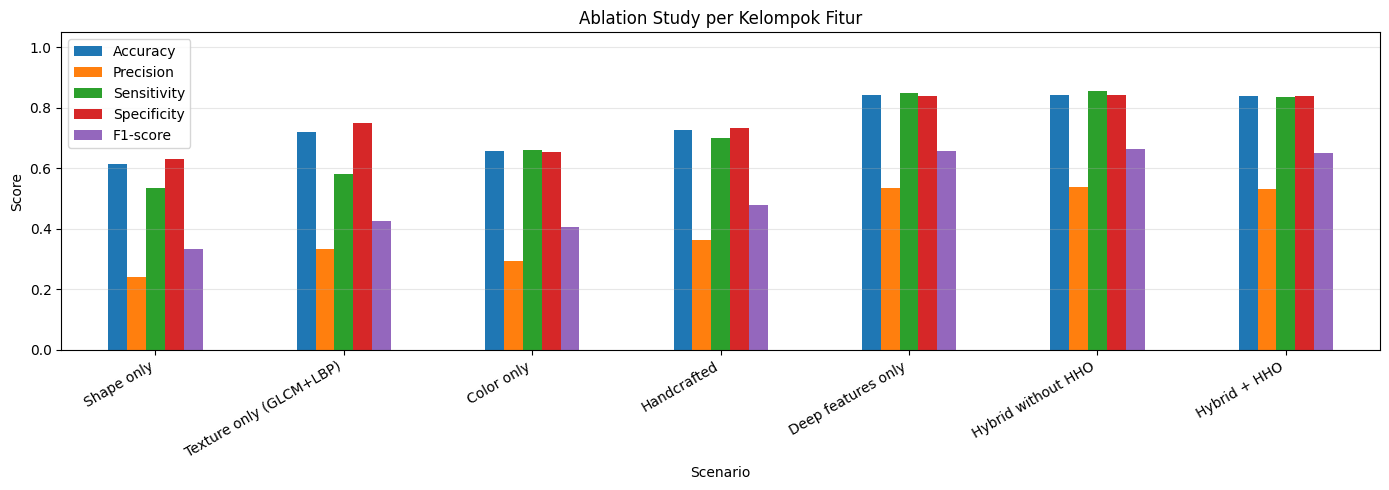

In [ ]:

# ============================================================
# REVISI PENGUJI: ABLATION STUDY PER KELOMPOK FITUR
# Menjawab pengaruh fitur shape, texture, color, deep, hybrid, dan HHO.
# ============================================================
from sklearn.base import clone

def specificity_score_binary(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

def scale_pair(Xtr, Xva):
    sc = StandardScaler()
    return sc.fit_transform(clean_features(Xtr)), sc.transform(clean_features(Xva))

def evaluate_ablation(name, Xtr, Xva, model=None):
    if model is None:
        model = SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced", random_state=42)
    model = clone(model)
    model.fit(Xtr, y_train)
    pred = model.predict(Xva)
    tn, fp, fn, tp = confusion_matrix(y_val, pred, labels=[0,1]).ravel()
    return {
        "Scenario": name,
        "n_features": Xtr.shape[1],
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Sensitivity": recall_score(y_val, pred, zero_division=0),
        "Specificity": specificity_score_binary(y_val, pred),
        "F1-score": f1_score(y_val, pred, zero_division=0),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp
    }

shape_idx = list(range(0, 5))
texture_idx = list(range(5, 19))
color_idx = list(range(19, 28))

rows = []
Xtr, Xva = scale_pair(X_train_hand[:, shape_idx], X_val_hand[:, shape_idx]); rows.append(evaluate_ablation("Shape only", Xtr, Xva))
Xtr, Xva = scale_pair(X_train_hand[:, texture_idx], X_val_hand[:, texture_idx]); rows.append(evaluate_ablation("Texture only (GLCM+LBP)", Xtr, Xva))
Xtr, Xva = scale_pair(X_train_hand[:, color_idx], X_val_hand[:, color_idx]); rows.append(evaluate_ablation("Color only", Xtr, Xva))
Xtr, Xva = scale_pair(X_train_hand, X_val_hand); rows.append(evaluate_ablation("Handcrafted", Xtr, Xva))
Xtr, Xva = scale_pair(X_train_deep, X_val_deep); rows.append(evaluate_ablation("Deep features only", Xtr, Xva))
rows.append(evaluate_ablation("Hybrid without HHO", X_train, X_val))
rows.append(evaluate_ablation("Hybrid + HHO", X_train_sel, X_val_sel))

ablation_df = pd.DataFrame(rows)
print(ablation_df)
ablation_df.to_csv(os.path.join(OUTPUT_DIR, "ablation_feature_groups_isic2019.csv"), index=False)

plot_df = ablation_df.set_index("Scenario")[["Accuracy", "Precision", "Sensitivity", "Specificity", "F1-score"]]
plot_df.plot(kind="bar", figsize=(14,5))
plt.title("Ablation Study per Kelompok Fitur")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ablation_feature_groups_isic2019.png"), dpi=200, bbox_inches="tight")
plt.show()


  Feature Group  Selected Count  Total Available  Selected Ratio
0          deep             499             1024        0.487305
1       texture               8               14        0.571429
2         shape               3                5        0.600000
3         color               2                9        0.222222
                   feature    group  importance
244      deep_densenet_507     deep    0.022289
24        deep_densenet_17     deep    0.011145
113      deep_densenet_228     deep    0.010899
213      deep_densenet_450     deep    0.010027
180      deep_densenet_385     deep    0.006820
426      deep_densenet_859     deep    0.006334
446      deep_densenet_899     deep    0.006035
57       deep_densenet_104     deep    0.005448
78       deep_densenet_154     deep    0.005162
138      deep_densenet_301     deep    0.004602
8        texture_lbp_bin_7  texture    0.004558
3    texture_glcm_contrast  texture    0.004528
229      deep_densenet_481     deep    0.004496
62 

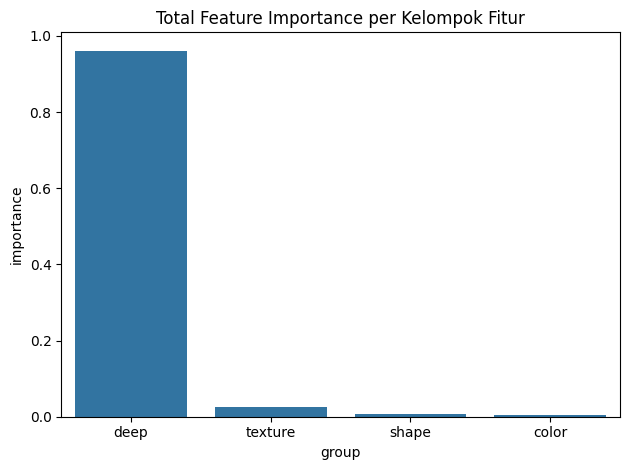

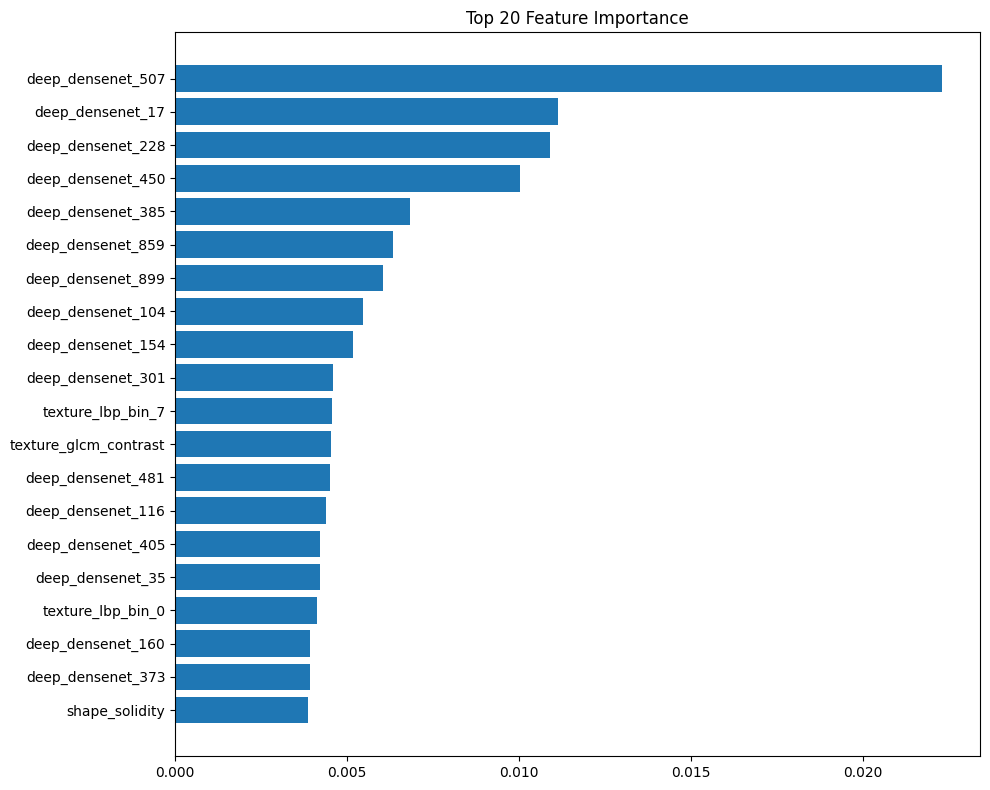

In [ ]:

# ============================================================
# REVISI PENGUJI: FEATURE RANKING / FEATURE IMPORTANCE
# Menjawab fitur/kelompok fitur mana yang paling berpengaruh.
# ============================================================
selected_feature_names = np.array(feature_names)[best_feature_mask == 1]
selected_feature_groups = np.array(feature_groups)[best_feature_mask == 1]

selected_summary = pd.Series(selected_feature_groups).value_counts().rename_axis("Feature Group").reset_index(name="Selected Count")
selected_summary["Total Available"] = selected_summary["Feature Group"].map(pd.Series(feature_groups).value_counts())
selected_summary["Selected Ratio"] = selected_summary["Selected Count"] / selected_summary["Total Available"]
print(selected_summary)
selected_summary.to_csv(os.path.join(OUTPUT_DIR, "hho_selected_feature_group_summary.csv"), index=False)

importance_model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                 subsample=0.8, colsample_bytree=0.8,
                                 eval_metric="logloss", random_state=42)
importance_model.fit(X_train_sel, y_train)
importance_df = pd.DataFrame({
    "feature": selected_feature_names,
    "group": selected_feature_groups,
    "importance": importance_model.feature_importances_
}).sort_values("importance", ascending=False)
print(importance_df.head(30))
importance_df.to_csv(os.path.join(OUTPUT_DIR, "feature_importance_xgboost_selected_features.csv"), index=False)

group_importance = importance_df.groupby("group", as_index=False)["importance"].sum().sort_values("importance", ascending=False)
print(group_importance)
group_importance.to_csv(os.path.join(OUTPUT_DIR, "feature_importance_by_group.csv"), index=False)

sns.barplot(data=group_importance, x="group", y="importance")
plt.title("Total Feature Importance per Kelompok Fitur")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance_by_group.png"), dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10,8))
top_imp = importance_df.head(20).iloc[::-1]
plt.barh(top_imp["feature"], top_imp["importance"])
plt.title("Top 20 Feature Importance")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top20_feature_importance.png"), dpi=200, bbox_inches="tight")
plt.show()


[INFO] Menggunakan subsample 500 dari 5067 data val untuk PI (lokal).
Menghitung permutation importance SVM... (bisa beberapa menit)

Top 20 Feature Importance (SVM - Permutation):
           feature group  importance_mean  importance_std
 deep_densenet_209  deep         0.070513        0.023813
 deep_densenet_358  deep         0.052564        0.021027
 deep_densenet_907  deep         0.047436        0.010013
 deep_densenet_309  deep         0.047436        0.011538
 deep_densenet_460  deep         0.043590        0.016418
 deep_densenet_100  deep         0.043590        0.017391
       color_G_std color         0.042308        0.018176
 deep_densenet_220  deep         0.039744        0.015649
 deep_densenet_157  deep         0.039744        0.018534
 deep_densenet_362  deep         0.039744        0.008974
deep_densenet_1015  deep         0.038462        0.022206
 deep_densenet_686  deep         0.038462        0.015169
 deep_densenet_571  deep         0.037179        0.008974
 deep_d

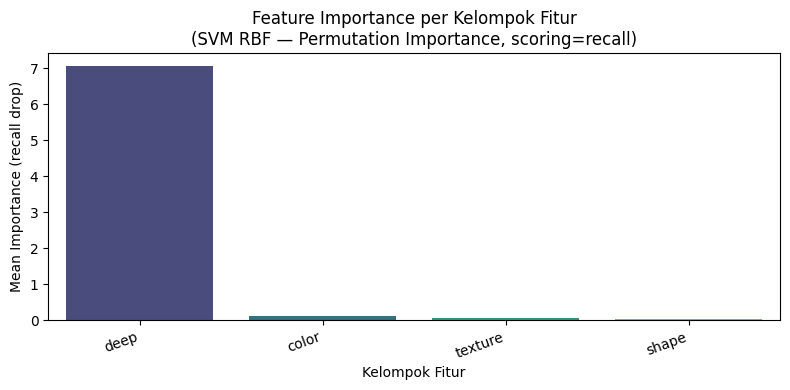

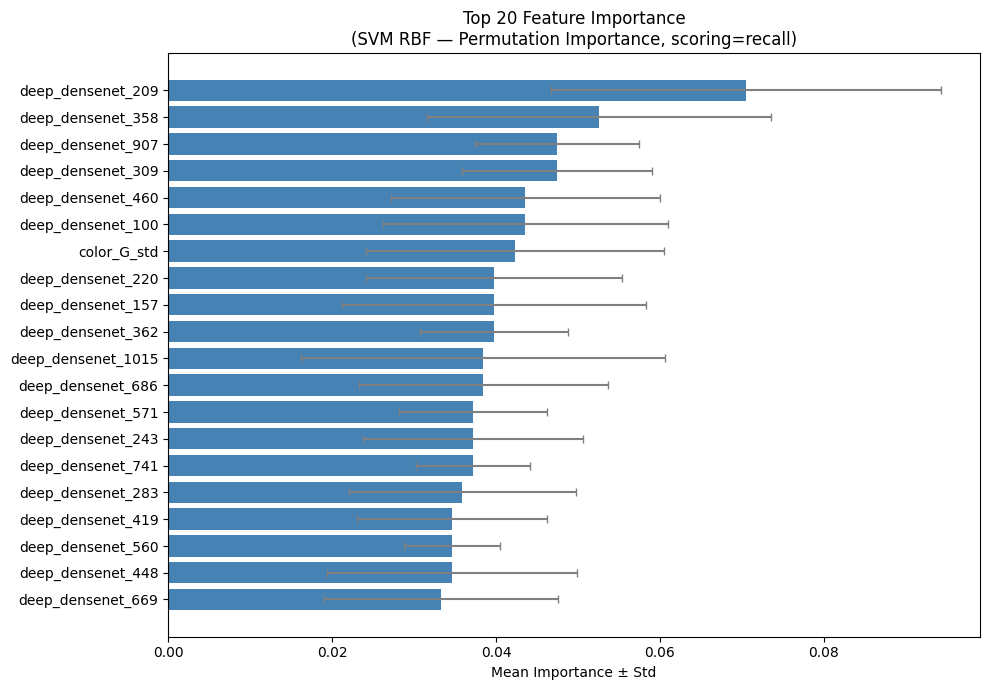


[DISCLAIMER] Hasil PI menggunakan subsample val set jika SAMPLE_SIZE < full data.
Untuk hasil final thesis, set SAMPLE_SIZE = None dan run di Kaggle (full dataset).
Lihat juga: feature_importance_xgboost_selected_features.csv (XGBoost surrogate) sebagai cross-check.


In [47]:
# ============================================================
# FEATURE IMPORTANCE — SVM (Model Terbaik)
# SVM RBF tidak memiliki feature_importances_ bawaan.
# Strategi: Permutation Importance pada subset data (cepat lokal)
# + XGBoost surrogate sudah ada di cell sebelumnya sebagai cross-check.
# NOTE: untuk dataset penuh di Kaggle, set SAMPLE_SIZE = None
# ============================================================
selected_feature_names = np.array(feature_names)[best_feature_mask == 1]
selected_feature_groups = np.array(feature_groups)[best_feature_mask == 1]
from sklearn.inspection import permutation_importance
import seaborn as sns

# --- Re-fit SVM terbaik pada X_train_sel ---
best_svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
    random_state=42,
    probability=True
)
best_svm.fit(X_train_sel, y_train)

# --- Subsample untuk lokal (ganti None agar pakai data penuh di Kaggle) ---
SAMPLE_SIZE = 500   # set None untuk Kaggle (full dataset)

if SAMPLE_SIZE is not None and len(X_val_sel) > SAMPLE_SIZE:
    np.random.seed(42)
    idx_sub = np.random.choice(len(X_val_sel), SAMPLE_SIZE, replace=False)
    X_pi = X_val_sel[idx_sub]
    y_pi = y_val[idx_sub] if hasattr(y_val, '__getitem__') else np.array(y_val)[idx_sub]
    print(f"[INFO] Menggunakan subsample {SAMPLE_SIZE} dari {len(X_val_sel)} data val untuk PI (lokal).")
else:
    X_pi = X_val_sel
    y_pi = y_val
    print(f"[INFO] Menggunakan full val set ({len(X_val_sel)} sampel) untuk PI.")

# --- Hitung Permutation Importance (scoring=recall karena medical) ---
print("Menghitung permutation importance SVM... (bisa beberapa menit)")
perm_result = permutation_importance(
    best_svm,
    X_pi,
    y_pi,
    n_repeats=10,
    random_state=42,
    scoring="recall",
    n_jobs=-1
)

# --- Buat DataFrame ---
perm_imp_df = pd.DataFrame({
    "feature": selected_feature_names,
    "group": selected_feature_groups,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

print("\nTop 20 Feature Importance (SVM - Permutation):")
print(perm_imp_df.head(20).to_string(index=False))
perm_imp_df.to_csv(os.path.join(OUTPUT_DIR, "feature_importance_svm_permutation.csv"), index=False)

# --- Group-level importance ---
perm_group_df = perm_imp_df.groupby("group", as_index=False)["importance_mean"].sum().sort_values("importance_mean", ascending=False)
print("\nImportance per Kelompok Fitur (SVM):")
print(perm_group_df.to_string(index=False))
perm_group_df.to_csv(os.path.join(OUTPUT_DIR, "feature_importance_svm_by_group.csv"), index=False)

# --- Plot 1: Group-level ---
plt.figure(figsize=(8, 4))
sns.barplot(data=perm_group_df, x="group", y="importance_mean", palette="viridis")
plt.title("Feature Importance per Kelompok Fitur\n(SVM RBF — Permutation Importance, scoring=recall)")
plt.xlabel("Kelompok Fitur")
plt.ylabel("Mean Importance (recall drop)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance_svm_by_group.png"), dpi=200, bbox_inches="tight")
plt.show()

# --- Plot 2: Top 20 individual ---
top20 = perm_imp_df.head(20).iloc[::-1]
plt.figure(figsize=(10, 7))
plt.barh(top20["feature"], top20["importance_mean"],
         xerr=top20["importance_std"], color="steelblue", ecolor="gray", capsize=3)
plt.title("Top 20 Feature Importance\n(SVM RBF — Permutation Importance, scoring=recall)")
plt.xlabel("Mean Importance ± Std")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top20_feature_importance_svm.png"), dpi=200, bbox_inches="tight")
plt.show()

print("\n[DISCLAIMER] Hasil PI menggunakan subsample val set jika SAMPLE_SIZE < full data.")
print("Untuk hasil final thesis, set SAMPLE_SIZE = None dan run di Kaggle (full dataset).")
print("Lihat juga: feature_importance_xgboost_selected_features.csv (XGBoost surrogate) sebagai cross-check.")


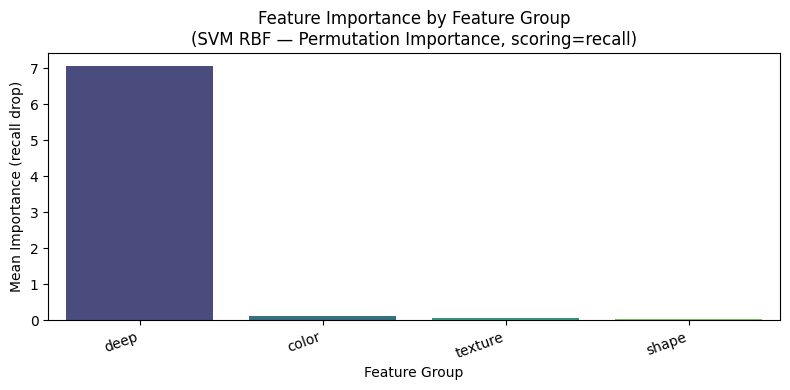

In [48]:
# --- Plot 1: Group-level ---
plt.figure(figsize=(8, 4))
sns.barplot(data=perm_group_df, x="group", y="importance_mean", palette="viridis")
plt.title("Feature Importance by Feature Group\n(SVM RBF — Permutation Importance, scoring=recall)")
plt.xlabel("Feature Group")
plt.ylabel("Mean Importance (recall drop)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance_svm_by_group.png"), dpi=200, bbox_inches="tight")
plt.show()

   Threshold  Accuracy  Precision  Sensitivity  Specificity  F1-score    TN  \
0        0.3  0.702598   0.329383     0.816880     0.680654  0.469467  4704   
1        0.4  0.755038   0.371895     0.755840     0.754884  0.498509  5217   
2        0.5  0.794975   0.418542     0.700829     0.813052  0.524091  5619   
3        0.6  0.824593   0.466591     0.620950     0.863696  0.532816  5969   
4        0.7  0.842802   0.511696     0.527506     0.903342  0.519481  6243   
5        0.8  0.856154   0.573651     0.416729     0.940530  0.482759  6500   

     FP   FN    TP  
0  2207  243  1084  
1  1694  324  1003  
2  1292  397   930  
3   942  503   824  
4   668  627   700  
5   411  774   553  


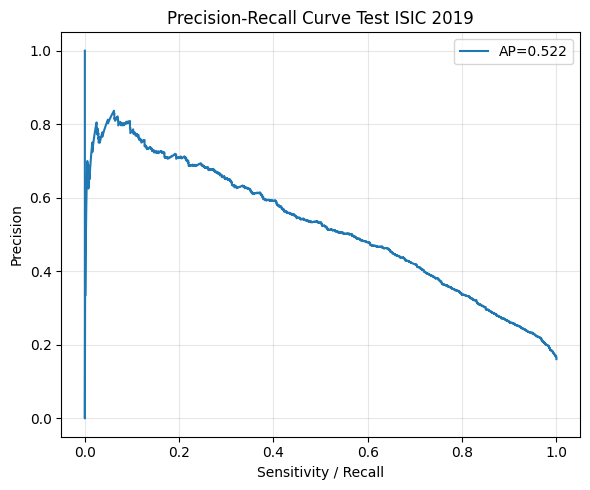

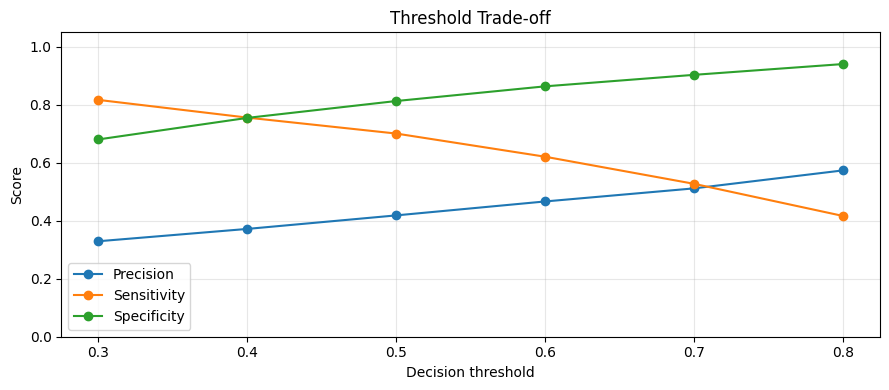

In [ ]:

# ============================================================
# REVISI PENGUJI: THRESHOLD / PRECISION-RECALL TRADE-OFF
# Menjawab mitigasi precision rendah ketika sensitivity tinggi.
# ============================================================
from sklearn.metrics import precision_recall_curve, average_precision_score

thresholds_to_check = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
rows = []
for th in thresholds_to_check:
    pred_th = (y_test_proba >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_th, labels=[0,1]).ravel()
    rows.append({
        "Threshold": th,
        "Accuracy": accuracy_score(y_test, pred_th),
        "Precision": precision_score(y_test, pred_th, zero_division=0),
        "Sensitivity": recall_score(y_test, pred_th, zero_division=0),
        "Specificity": tn/(tn+fp) if (tn+fp)>0 else 0,
        "F1-score": f1_score(y_test, pred_th, zero_division=0),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp
    })
threshold_df = pd.DataFrame(rows)
print(threshold_df)
threshold_df.to_csv(os.path.join(OUTPUT_DIR, "threshold_tradeoff_test_isic2019.csv"), index=False)

prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_test_proba)
ap = average_precision_score(y_test, y_test_proba)
plt.figure(figsize=(6,5))
plt.plot(rec_curve, prec_curve, label=f"AP={ap:.3f}")
plt.xlabel("Sensitivity / Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Test ISIC 2019")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "precision_recall_curve_test_isic2019.png"), dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9,4))
for col in ["Precision", "Sensitivity", "Specificity"]:
    plt.plot(threshold_df["Threshold"], threshold_df[col], marker="o", label=col)
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Threshold Trade-off")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "threshold_tradeoff_test_isic2019.png"), dpi=200, bbox_inches="tight")
plt.show()


case_type
TN    5520
FP    1391
TP     948
FN     379
Name: count, dtype: int64


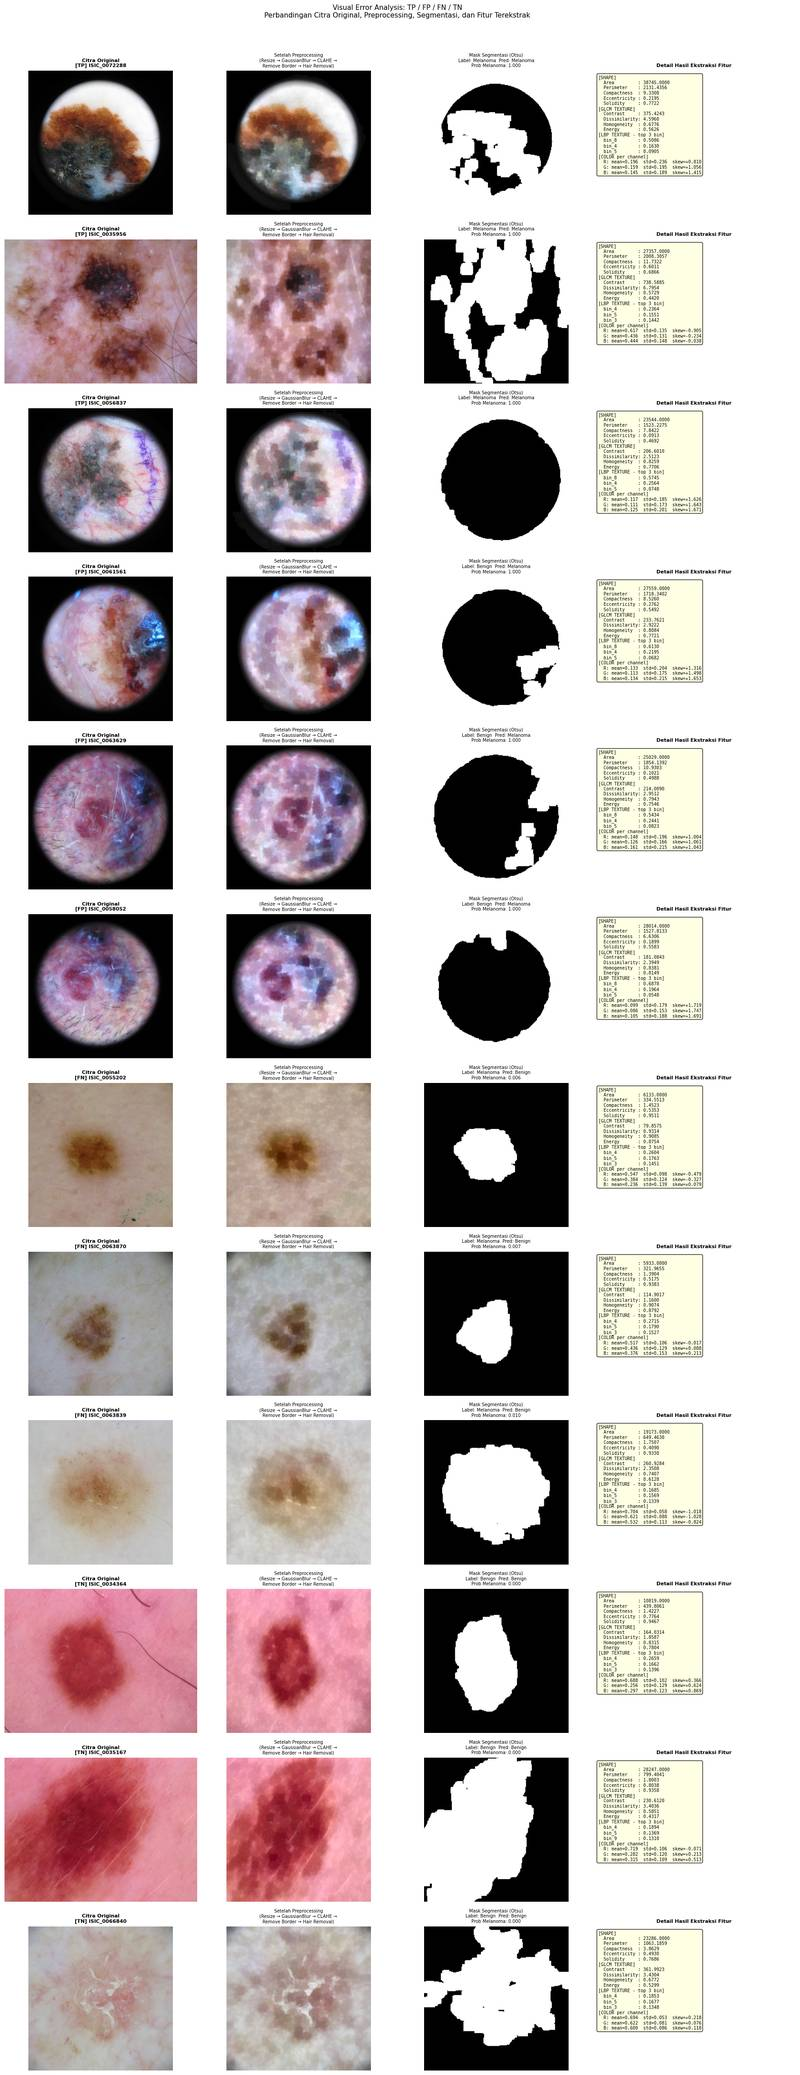

             image  y_true  y_pred  prob_melanoma case_type
4407  ISIC_0061561     0.0     1.0       0.999999        FP
7917  ISIC_0072288     1.0     1.0       0.999995        TP
5098  ISIC_0063629     0.0     1.0       0.999994        FP
1596  ISIC_0035956     1.0     1.0       0.999993        TP
2844  ISIC_0056837     1.0     1.0       0.999992        TP
3273  ISIC_0058052     0.0     1.0       0.999991        FP
1956  ISIC_0054160     1.0     1.0       0.999984        TP
7852  ISIC_0072069     1.0     1.0       0.997446        TP
4580  ISIC_0062075     1.0     1.0       0.996469        TP
7953  ISIC_0072389     1.0     1.0       0.996431        TP
6549  ISIC_0068026     0.0     1.0       0.996273        FP
7967  ISIC_0072415     1.0     1.0       0.995926        TP
6435  ISIC_0067690     1.0     1.0       0.995870        TP
1665  ISIC_0036025     0.0     1.0       0.995530        FP
5280  ISIC_0064194     1.0     1.0       0.995328        TP
6088  ISIC_0066610     0.0     1.0      

In [ ]:

# ============================================================
# REVISI PENGUJI: VISUAL ERROR ANALYSIS TP/FP/FN/TN
# Bukti citra untuk menjelaskan false positive dan false negative.
# + Detail hasil ekstraksi fitur per citra
# ============================================================
results_df["case_type"] = np.select(
    [
        (results_df["y_true"] == 1) & (results_df["y_pred"] == 1),
        (results_df["y_true"] == 0) & (results_df["y_pred"] == 0),
        (results_df["y_true"] == 0) & (results_df["y_pred"] == 1),
        (results_df["y_true"] == 1) & (results_df["y_pred"] == 0),
    ],
    ["TP", "TN", "FP", "FN"],
    default="Other"
)
print(results_df["case_type"].value_counts())

def _read_rgb(path):
    img = cv2.imread(path)
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def format_feature_text(img, mask):
    # Hitung dan format semua fitur handcrafted untuk 1 gambar
    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

    # Shape
    s = extract_shape_features(mask)
    shape_names = ["Area", "Perimeter", "Compactness", "Eccentricity", "Solidity"]

    # GLCM
    g = extract_glcm_features(gray, mask)
    glcm_names = ["Contrast", "Dissimilarity", "Homogeneity", "Energy"]

    # LBP
    lbp_vals = extract_lbp_features(img, mask)

    # Color
    c = extract_color_features(img, mask)

    lines = ["[SHAPE]"]
    for name, val in zip(shape_names, s):
        lines.append(f"  {name:<13}: {val:.4f}")

    lines.append("[GLCM TEXTURE]")
    for name, val in zip(glcm_names, g):
        lines.append(f"  {name:<13}: {val:.4f}")

    lines.append("[LBP TEXTURE - top 3 bin]")
    top3 = sorted(enumerate(lbp_vals), key=lambda x: -x[1])[:3]
    for idx, val in top3:
        lines.append(f"  bin_{idx:<2}       : {val:.4f}")

    lines.append("[COLOR per channel]")
    ch_names = ["R", "G", "B"]
    for i, ch in enumerate(ch_names):
        mean_v = c[i * 3]
        std_v  = c[i * 3 + 1]
        skew_v = c[i * 3 + 2]
        lines.append(f"  {ch}: mean={mean_v:.3f}  std={std_v:.3f}  skew={skew_v:+.3f}")

    return "\n".join(lines)

def visualize_case_grid(results_df, n_per_case=3):
    case_order = ["TP", "FP", "FN", "TN"]
    parts = []
    for case in case_order:
        sub = results_df[results_df["case_type"] == case].copy()
        if len(sub) == 0:
            continue
        sub = sub.sort_values("prob_melanoma", ascending=(case in ["TN", "FN"]))
        parts.append(sub.head(n_per_case))
    selected = pd.concat(parts) if parts else pd.DataFrame()
    if selected.empty:
        print("Tidak ada contoh untuk divisualisasikan")
        return

    # 4 kolom: Original | Preprocessed | Mask Segmentasi | Detail Fitur
    fig, axes = plt.subplots(len(selected), 4, figsize=(18, 3.8 * len(selected)))
    if len(selected) == 1:
        axes = np.expand_dims(axes, 0)

    for r, (_, row) in enumerate(selected.iterrows()):
        img_path = row["img_path"] if os.path.isabs(row["img_path"]) else os.path.join(TEST_IMG_DIR, row["img_path"])
        original = _read_rgb(img_path)
        pre      = preprocess_image(img_path)
        mask     = segment_lesion(pre)

        # Kolom 0: Citra Original
        if original is not None:
            axes[r, 0].imshow(original)
        axes[r, 0].set_title(
            f"Citra Original\n[{row['case_type']}] {row['image']}",
            fontsize=8, fontweight='bold'
        )
        axes[r, 0].axis("off")

        # Kolom 1: Citra Setelah Preprocessing
        axes[r, 1].imshow(pre)
        axes[r, 1].set_title(
            "Setelah Preprocessing\n(Resize \u2192 GaussianBlur \u2192 CLAHE \u2192\nRemove Border \u2192 Hair Removal)",
            fontsize=7
        )
        axes[r, 1].axis("off")

        # Kolom 2: Mask Segmentasi
        axes[r, 2].imshow(mask, cmap="gray")
        axes[r, 2].set_title(
            f"Mask Segmentasi (Otsu)\n"
            f"Label: {'Melanoma' if int(row['y_true'])==1 else 'Benign'}  "
            f"Pred: {'Melanoma' if int(row['y_pred'])==1 else 'Benign'}\n"
            f"Prob Melanoma: {row['prob_melanoma']:.3f}",
            fontsize=7
        )
        axes[r, 2].axis("off")

        # Kolom 3: Detail Hasil Ekstraksi Fitur
        feat_text = format_feature_text(pre, mask)
        axes[r, 3].axis("off")
        axes[r, 3].text(
            0.03, 0.97, feat_text,
            transform=axes[r, 3].transAxes,
            fontsize=7,
            verticalalignment='top',
            fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85)
        )
        axes[r, 3].set_title("Detail Hasil Ekstraksi Fitur", fontsize=8, fontweight='bold')

    plt.suptitle(
        "Visual Error Analysis: TP / FP / FN / TN\n"
        "Perbandingan Citra Original, Preprocessing, Segmentasi, dan Fitur Terekstrak",
        fontsize=11, y=1.01
    )
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "visual_error_analysis_tp_fp_fn_tn.png"), dpi=200, bbox_inches="tight")
    plt.show()

visualize_case_grid(results_df, n_per_case=3)
case_examples = results_df.sort_values("prob_melanoma", ascending=False).groupby("case_type").head(10)
case_examples[["image", "y_true", "y_pred", "prob_melanoma", "case_type"]].to_csv(os.path.join(OUTPUT_DIR, "visual_error_case_examples.csv"), index=False)
print(case_examples[["image", "y_true", "y_pred", "prob_melanoma", "case_type"]].head(20))


In [45]:
# HHO PARAMETERS
N_HAWKS = 3
MAX_ITER = 2

# FITNESS FUNCTION
def fitness_function(feature_mask, X, y):

    if np.sum(feature_mask) == 0:
        return 0

    X_sel = X[:, feature_mask == 1]

    clf = SVC(kernel="linear", C=1.0, class_weight="balanced")

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    recall_scores, specificity_scores = [], []

    for train_idx, val_idx in cv.split(X_sel, y):
        clf.fit(X_sel[train_idx], y[train_idx])
        preds = clf.predict(X_sel[val_idx])
        recall_scores.append(recall_score(y[val_idx], preds, zero_division=0))
        tn, fp, fn, tp = confusion_matrix(y[val_idx], preds, labels=[0, 1]).ravel()
        specificity_scores.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    mean_recall = np.mean(recall_scores)
    mean_specificity = np.mean(specificity_scores)
    feature_ratio = np.sum(feature_mask) / len(feature_mask)

    # Recall-oriented objective sesuai tujuan medical screening.
    # Specificity tetap diberi bobot agar false positive tidak diabaikan total,
    # dan feature reduction mencegah fitur terlalu banyak.
    fitness = 0.70 * mean_recall + 0.20 * mean_specificity + 0.10 * (1 - feature_ratio)

    return fitness

# HHO
def HHO(X, y, n_hawks=10, max_iter=20):

    n_features = X.shape[1]
    hawks = np.random.randint(0, 2, size=(n_hawks, n_features))

    fitness_scores = np.array([
        fitness_function(hawk, X, y) for hawk in hawks
    ])

    best_idx = np.argmax(fitness_scores)
    best_hawk = hawks[best_idx].copy()
    best_score = fitness_scores[best_idx]

    for t in range(max_iter):
        E1 = 2 * (1 - (t / max_iter))

        for i in range(n_hawks):
            E0 = 2 * np.random.rand() - 1
            E = E1 * E0

            if abs(E) >= 1:
                rand_hawk = hawks[np.random.randint(n_hawks)]
                hawks[i] = rand_hawk ^ np.random.randint(0, 2, n_features)
            else:
                hawks[i] = best_hawk ^ (np.random.rand(n_features) > 0.5)

            score = fitness_function(hawks[i], X, y)

            if score > best_score:
                best_score = score
                best_hawk = hawks[i].copy()

        print(f"Iter {t+1}/{max_iter} | Best fitness: {best_score:.4f}")

    return best_hawk

# RUN HHO
best_feature_mask = HHO(
    X_train,
    y_train,
    n_hawks=N_HAWKS,
    max_iter=MAX_ITER
)

print("Jumlah fitur terpilih:", np.sum(best_feature_mask))

# APPLY MASK
X_train_sel = X_train[:, best_feature_mask == 1]
X_val_sel   = X_val[:, best_feature_mask == 1]

print("Selected train shape:", X_train_sel.shape)
print("Selected val shape:", X_val_sel.shape)

# EVALUATION FUNCTION
def evaluate_model(model, X_train, y_train, X_val, y_val):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec  = recall_score(y_val, y_pred)
    f1   = f1_score(y_val, y_pred)

    cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    print(classification_report(y_val, y_pred, target_names=["Benign", "Melanoma"]))
    print("Accuracy   :", acc)
    print("Precision  :", prec)
    print("Sensitivity:", rec)
    print("Specificity:", spec)
    print("F1-score   :", f1)

    return cm, acc, prec, rec, f1

# SVM
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
    random_state=42
)

cm_svm, acc_svm, prec_svm, rec_svm, f1_svm = evaluate_model(
    svm_model,
    X_train_sel, y_train,
    X_val_sel, y_val
)

# # RANDOM FOREST
# from sklearn.ensemble import RandomForestClassifier

# rf_model = RandomForestClassifier(
#     n_estimators=200,
#     max_depth=None,
#     class_weight="balanced",
#     random_state=42
# )

# cm_rf, acc_rf, prec_rf, rec_rf, f1_rf = evaluate_model(
#     rf_model,
#     X_train_sel, y_train,
#     X_val_sel, y_val
# )

# # MLP
# from sklearn.neural_network import MLPClassifier

# mlp_model = MLPClassifier(
#     hidden_layer_sizes=(256, 128),
#     activation="relu",
#     solver="adam",
#     max_iter=300,
#     random_state=42
# )

# cm_mlp, acc_mlp, prec_mlp, rec_mlp, f1_mlp = evaluate_model(
#     mlp_model,
#     X_train_sel, y_train,
#     X_val_sel, y_val
# )

# # XGBOOST
# xgb_model = XGBClassifier(
#     n_estimators=300,
#     max_depth=6,
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     eval_metric="logloss",
#     random_state=42,
#     use_label_encoder=False
# )

# cm_xgb, acc_xgb, prec_xgb, rec_xgb, f1_xgb = evaluate_model(
#     xgb_model,
#     X_train_sel, y_train,
#     X_val_sel, y_val
# )

# RESULTS TABLE
results = pd.DataFrame({
    "Model": ["SVM"],
    "Accuracy": [acc_svm],
    "Precision": [prec_svm],
    "Sensitivity": [rec_svm],
    "F1-score": [f1_svm]
})

print(results)
results.to_csv(os.path.join(OUTPUT_DIR, "validation_model_comparison.csv"), index=False)
print("Saved:", os.path.join(OUTPUT_DIR, "validation_model_comparison.csv"))


Iter 1/2 | Best fitness: 0.7514
Iter 2/2 | Best fitness: 0.7514
Jumlah fitur terpilih: 504
Selected train shape: (14458, 504)
Selected val shape: (5067, 504)
              precision    recall  f1-score   support

      Benign       0.96      0.83      0.89      4162
    Melanoma       0.52      0.83      0.64       905

    accuracy                           0.83      5067
   macro avg       0.74      0.83      0.76      5067
weighted avg       0.88      0.83      0.84      5067

Accuracy   : 0.8308663903690546
Precision  : 0.5164158686730507
Sensitivity: 0.8342541436464088
Specificity: 0.8301297453147525
F1-score   : 0.6379383185466836
  Model  Accuracy  Precision  Sensitivity  F1-score
0   SVM  0.830866   0.516416     0.834254  0.637938
Saved: D:\S2\THESIS\DATASET\MELANOMA\output\validation_model_comparison.csv


100%|██████████| 8238/8238 [14:50<00:00,  9.25it/s]


              precision    recall  f1-score   support

      Benign       0.93      0.80      0.86      6911
    Melanoma       0.40      0.70      0.51      1327

    accuracy                           0.78      8238
   macro avg       0.67      0.75      0.68      8238
weighted avg       0.85      0.78      0.80      8238

   Accuracy  Precision  Sensitivity  Specificity  F1-score    TN    FP   FN  \
0  0.781986   0.399313     0.700829     0.797569  0.508753  5512  1399  397   

    TP  
0  930  


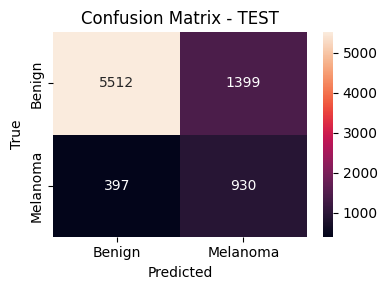

          image  MEL   NV  BCC   AK  BKL   DF  VASC  SCC  UNK  score_weight  \
0  ISIC_0034321  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0           0.0   
1  ISIC_0034322  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0           0.0   
2  ISIC_0034323  0.0  0.0  1.0  0.0  0.0  0.0   0.0  0.0  0.0           0.0   
3  ISIC_0034324  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0           0.0   
4  ISIC_0034325  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0           0.0   

   validation_weight  label  \
0                1.0    0.0   
1                1.0    0.0   
2                1.0    0.0   
3                1.0    0.0   
4                1.0    0.0   

                                            img_path  y_true  y_pred  \
0  D:\S2\THESIS\DATASET\MELANOMA\ISIC_2019_Test_I...     0.0     0.0   
1  D:\S2\THESIS\DATASET\MELANOMA\ISIC_2019_Test_I...     0.0     0.0   
2  D:\S2\THESIS\DATASET\MELANOMA\ISIC_2019_Test_I...     0.0     0.0   
3  D:\S2\THESIS\DATASET\MELANOMA\ISIC_2019_Test_I.

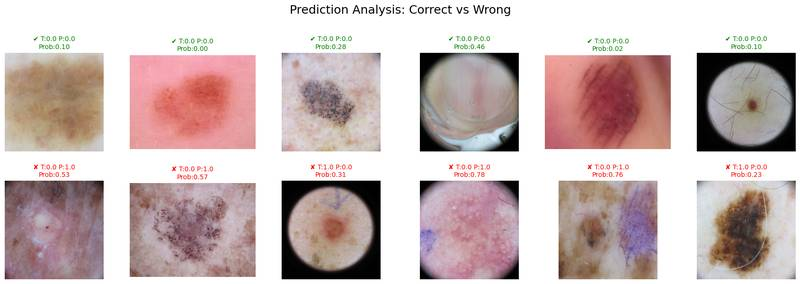

False Positive: 1399
           image  prob_melanoma
5   ISIC_0034326       0.913029
10  ISIC_0034332       0.547275
13  ISIC_0034335       0.526632
16  ISIC_0034338       0.573455
17  ISIC_0034339       0.795095
Saved: D:\S2\THESIS\DATASET\MELANOMA\output\prediction_analysis.csv


In [48]:
# TEST SET EVALUATION - robust alignment between features, labels, and image IDs
# This fixes the old risk where missing images could desynchronize results_df and predictions.

test_gt_df = test_gt_df.copy()
test_gt_df["img_path"] = test_gt_df["image"].apply(lambda x: os.path.join(TEST_IMG_DIR, x + ".jpg"))

X_test_handcrafted, y_test_hand, test_rows_hand = extract_handcrafted_features_from_df(
    test_gt_df, TEST_IMG_DIR, return_rows=True
)
X_test_deep, y_test_deep, test_rows_deep = extract_deep_features_from_df(
    test_rows_hand, TEST_IMG_DIR, return_rows=True
)

# Align using rows successfully processed by both handcrafted and deep feature extraction.
y_test = np.array(y_test_deep)
test_rows = test_rows_deep.reset_index(drop=True)

if len(X_test_handcrafted) != len(X_test_deep):
    print("WARNING: handcrafted/deep feature count mismatch:", len(X_test_handcrafted), len(X_test_deep))
    min_len = min(len(X_test_handcrafted), len(X_test_deep))
    X_test_handcrafted = X_test_handcrafted[:min_len]
    X_test_deep = X_test_deep[:min_len]
    y_test = y_test[:min_len]
    test_rows = test_rows.iloc[:min_len].copy()

# FUSION TEST
X_test = np.hstack([X_test_handcrafted, X_test_deep])
X_test = clean_features(X_test)

# NORMALIZE TEST
X_test = scaler.transform(X_test)

# APPLY MASK TEST
X_test_sel = X_test[:, best_feature_mask == 1]

# FINAL MODEL (SVM)
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_sel, y_train)

y_test_pred = svm_model.predict(X_test_sel)
y_test_proba = svm_model.predict_proba(X_test_sel)[:, 1]

print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Benign", "Melanoma"],
    zero_division=0
))

# CONFUSION MATRIX
cm_test = confusion_matrix(y_test, y_test_pred, labels=[0, 1])

tn, fp, fn, tp = cm_test.ravel()
test_metrics = pd.DataFrame([{
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred, zero_division=0),
    "Sensitivity": recall_score(y_test, y_test_pred, zero_division=0),
    "Specificity": tn/(tn+fp) if (tn+fp)>0 else 0,
    "F1-score": f1_score(y_test, y_test_pred, zero_division=0),
    "TN": tn, "FP": fp, "FN": fn, "TP": tp
}])
print(test_metrics)
test_metrics.to_csv(os.path.join(OUTPUT_DIR, "test_metrics_isic2019.csv"), index=False)

plt.figure(figsize=(4,3))
sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    xticklabels=["Benign", "Melanoma"],
    yticklabels=["Benign", "Melanoma"]
)
plt.title("Confusion Matrix - TEST")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_test_isic2019.png"), dpi=200, bbox_inches="tight")
plt.show()

# SAVE RESULT
results_df = test_rows.copy()
results_df["y_true"] = y_test
results_df["y_pred"] = y_test_pred
results_df["prob_melanoma"] = y_test_proba
results_df["status"] = np.where(results_df["y_true"] == results_df["y_pred"], "Correct", "Wrong")

print(results_df.head())

# VISUALIZATION
def visualize_predictions(df, img_dir=None, n=6):
    correct = df[df["status"] == "Correct"]
    wrong   = df[df["status"] == "Wrong"]
    n = min(n, len(correct), len(wrong))
    if n == 0:
        print("Tidak cukup contoh correct/wrong untuk visualisasi.")
        return
    correct = correct.sample(n, random_state=42)
    wrong   = wrong.sample(n, random_state=42)
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    fig.suptitle("Prediction Analysis: Correct vs Wrong", fontsize=18, y=1.02)
    for i, (_, row) in enumerate(correct.iterrows()):
        img_path = row["img_path"]
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(img)
        axes[0, i].set_title(f"✔ T:{row['y_true']} P:{row['y_pred']}\nProb:{row['prob_melanoma']:.2f}", fontsize=10, color="green")
        axes[0, i].axis("off")
    for i, (_, row) in enumerate(wrong.iterrows()):
        img_path = row["img_path"]
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        axes[1, i].imshow(img)
        axes[1, i].set_title(f"✘ T:{row['y_true']} P:{row['y_pred']}\nProb:{row['prob_melanoma']:.2f}", fontsize=10, color="red")
        axes[1, i].axis("off")
    plt.subplots_adjust(left=0.02, right=0.98, top=0.85, bottom=0.05, wspace=0.1, hspace=0.3)
    plt.savefig(os.path.join(OUTPUT_DIR, "prediction_correct_vs_wrong.png"), dpi=200, bbox_inches="tight")
    plt.show()

visualize_predictions(results_df, n=6)

# FALSE POSITIVE
false_positive = results_df[(results_df["y_true"] == 0) & (results_df["y_pred"] == 1)]
print("False Positive:", len(false_positive))
print(false_positive[["image", "prob_melanoma"]].head())

# SAVE CSV
results_df.to_csv(os.path.join(OUTPUT_DIR, "prediction_analysis.csv"), index=False)
print("Saved:", os.path.join(OUTPUT_DIR, "prediction_analysis.csv"))


case_type
TN    5512
FP    1399
TP     930
FN     397
Name: count, dtype: int64


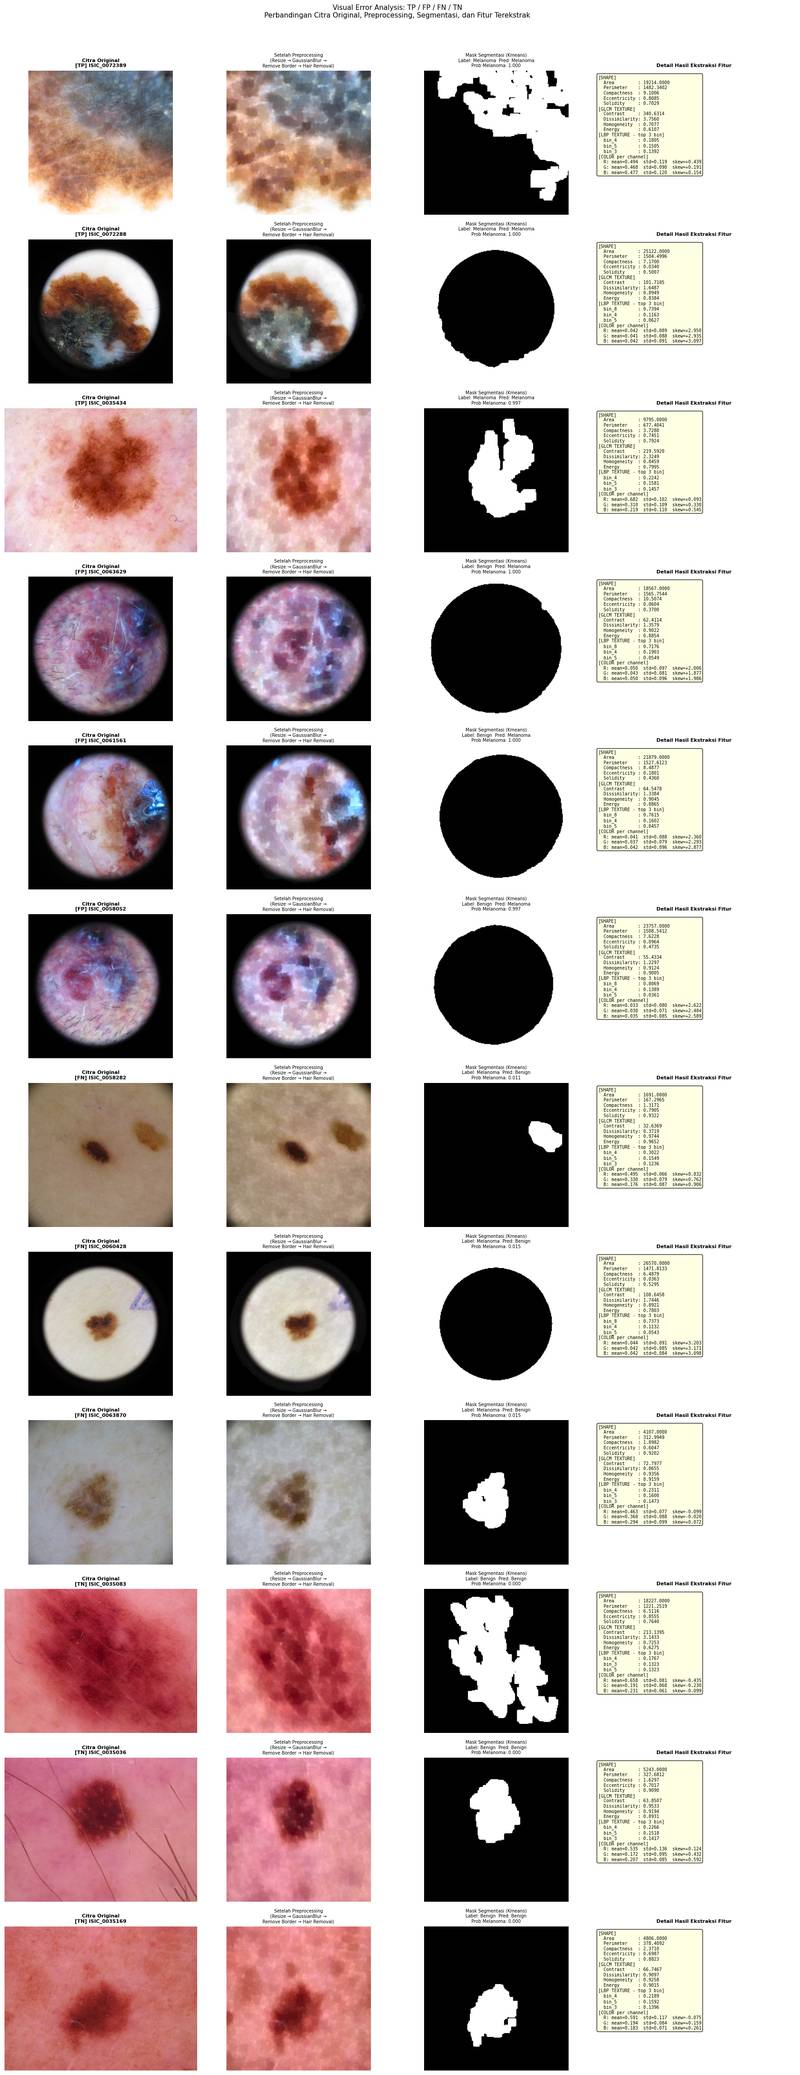

             image  y_true  y_pred  prob_melanoma case_type
7953  ISIC_0072389     1.0     1.0       0.999989        TP
7917  ISIC_0072288     1.0     1.0       0.999987        TP
5098  ISIC_0063629     0.0     1.0       0.999985        FP
4407  ISIC_0061561     0.0     1.0       0.999983        FP
3273  ISIC_0058052     0.0     1.0       0.997325        FP
1079  ISIC_0035434     1.0     1.0       0.997202        TP
6406  ISIC_0067593     1.0     1.0       0.997199        TP
1596  ISIC_0035956     1.0     1.0       0.996499        TP
3234  ISIC_0057939     1.0     1.0       0.995871        TP
1728  ISIC_0053520     1.0     1.0       0.995847        TP
1868  ISIC_0053927     1.0     1.0       0.995774        TP
6435  ISIC_0067690     1.0     1.0       0.995501        TP
4343  ISIC_0061380     1.0     1.0       0.995474        TP
6088  ISIC_0066610     0.0     1.0       0.991545        FP
8089  ISIC_0072790     0.0     1.0       0.991121        FP
812   ISIC_0035155     0.0     1.0      

In [49]:

# ============================================================
# REVISI PENGUJI: VISUAL ERROR ANALYSIS TP/FP/FN/TN
# Bukti citra untuk menjelaskan false positive dan false negative.
# + Detail hasil ekstraksi fitur per citra
# ============================================================
results_df["case_type"] = np.select(
    [
        (results_df["y_true"] == 1) & (results_df["y_pred"] == 1),
        (results_df["y_true"] == 0) & (results_df["y_pred"] == 0),
        (results_df["y_true"] == 0) & (results_df["y_pred"] == 1),
        (results_df["y_true"] == 1) & (results_df["y_pred"] == 0),
    ],
    ["TP", "TN", "FP", "FN"],
    default="Other"
)
print(results_df["case_type"].value_counts())

def _read_rgb(path):
    img = cv2.imread(path)
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def format_feature_text(img, mask):
    # Hitung dan format semua fitur handcrafted untuk 1 gambar
    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

    # Shape
    s = extract_shape_features(mask)
    shape_names = ["Area", "Perimeter", "Compactness", "Eccentricity", "Solidity"]

    # GLCM
    g = extract_glcm_features(gray, mask)
    glcm_names = ["Contrast", "Dissimilarity", "Homogeneity", "Energy"]

    # LBP
    lbp_vals = extract_lbp_features(img, mask)

    # Color
    c = extract_color_features(img, mask)

    lines = ["[SHAPE]"]
    for name, val in zip(shape_names, s):
        lines.append(f"  {name:<13}: {val:.4f}")

    lines.append("[GLCM TEXTURE]")
    for name, val in zip(glcm_names, g):
        lines.append(f"  {name:<13}: {val:.4f}")

    lines.append("[LBP TEXTURE - top 3 bin]")
    top3 = sorted(enumerate(lbp_vals), key=lambda x: -x[1])[:3]
    for idx, val in top3:
        lines.append(f"  bin_{idx:<2}       : {val:.4f}")

    lines.append("[COLOR per channel]")
    ch_names = ["R", "G", "B"]
    for i, ch in enumerate(ch_names):
        mean_v = c[i * 3]
        std_v  = c[i * 3 + 1]
        skew_v = c[i * 3 + 2]
        lines.append(f"  {ch}: mean={mean_v:.3f}  std={std_v:.3f}  skew={skew_v:+.3f}")

    return "\n".join(lines)

def visualize_case_grid(results_df, n_per_case=3):
    case_order = ["TP", "FP", "FN", "TN"]
    parts = []
    for case in case_order:
        sub = results_df[results_df["case_type"] == case].copy()
        if len(sub) == 0:
            continue
        sub = sub.sort_values("prob_melanoma", ascending=(case in ["TN", "FN"]))
        parts.append(sub.head(n_per_case))
    selected = pd.concat(parts) if parts else pd.DataFrame()
    if selected.empty:
        print("Tidak ada contoh untuk divisualisasikan")
        return

    # 4 kolom: Original | Preprocessed | Mask Segmentasi | Detail Fitur
    fig, axes = plt.subplots(len(selected), 4, figsize=(18, 3.8 * len(selected)))
    if len(selected) == 1:
        axes = np.expand_dims(axes, 0)

    for r, (_, row) in enumerate(selected.iterrows()):
        img_path = row["img_path"] if os.path.isabs(row["img_path"]) else os.path.join(TEST_IMG_DIR, row["img_path"])
        original = _read_rgb(img_path)
        pre      = preprocess_image(img_path)
        mask     = segment_kmeans(pre)

        # Kolom 0: Citra Original
        if original is not None:
            axes[r, 0].imshow(original)
        axes[r, 0].set_title(
            f"Citra Original\n[{row['case_type']}] {row['image']}",
            fontsize=8, fontweight='bold'
        )
        axes[r, 0].axis("off")

        # Kolom 1: Citra Setelah Preprocessing
        axes[r, 1].imshow(pre)
        axes[r, 1].set_title(
            "Setelah Preprocessing\n(Resize \u2192 GaussianBlur \u2192\nRemove Border \u2192 Hair Removal)",
            fontsize=7
        )
        axes[r, 1].axis("off")

        # Kolom 2: Mask Segmentasi
        axes[r, 2].imshow(mask, cmap="gray")
        axes[r, 2].set_title(
            f"Mask Segmentasi (Kmeans)\n"
            f"Label: {'Melanoma' if int(row['y_true'])==1 else 'Benign'}  "
            f"Pred: {'Melanoma' if int(row['y_pred'])==1 else 'Benign'}\n"
            f"Prob Melanoma: {row['prob_melanoma']:.3f}",
            fontsize=7
        )
        axes[r, 2].axis("off")

        # Kolom 3: Detail Hasil Ekstraksi Fitur
        feat_text = format_feature_text(pre, mask)
        axes[r, 3].axis("off")
        axes[r, 3].text(
            0.03, 0.97, feat_text,
            transform=axes[r, 3].transAxes,
            fontsize=7,
            verticalalignment='top',
            fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85)
        )
        axes[r, 3].set_title("Detail Hasil Ekstraksi Fitur", fontsize=8, fontweight='bold')

    plt.suptitle(
        "Visual Error Analysis: TP / FP / FN / TN\n"
        "Perbandingan Citra Original, Preprocessing, Segmentasi, dan Fitur Terekstrak",
        fontsize=11, y=1.01
    )
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "visual_error_analysis_tp_fp_fn_tn.png"), dpi=200, bbox_inches="tight")
    plt.show()

visualize_case_grid(results_df, n_per_case=3)
case_examples = results_df.sort_values("prob_melanoma", ascending=False).groupby("case_type").head(10)
case_examples[["image", "y_true", "y_pred", "prob_melanoma", "case_type"]].to_csv(os.path.join(OUTPUT_DIR, "visual_error_case_examples.csv"), index=False)
print(case_examples[["image", "y_true", "y_pred", "prob_melanoma", "case_type"]].head(20))


case_type
TN    5512
FP    1399
TP     930
FN     397
Name: count, dtype: int64


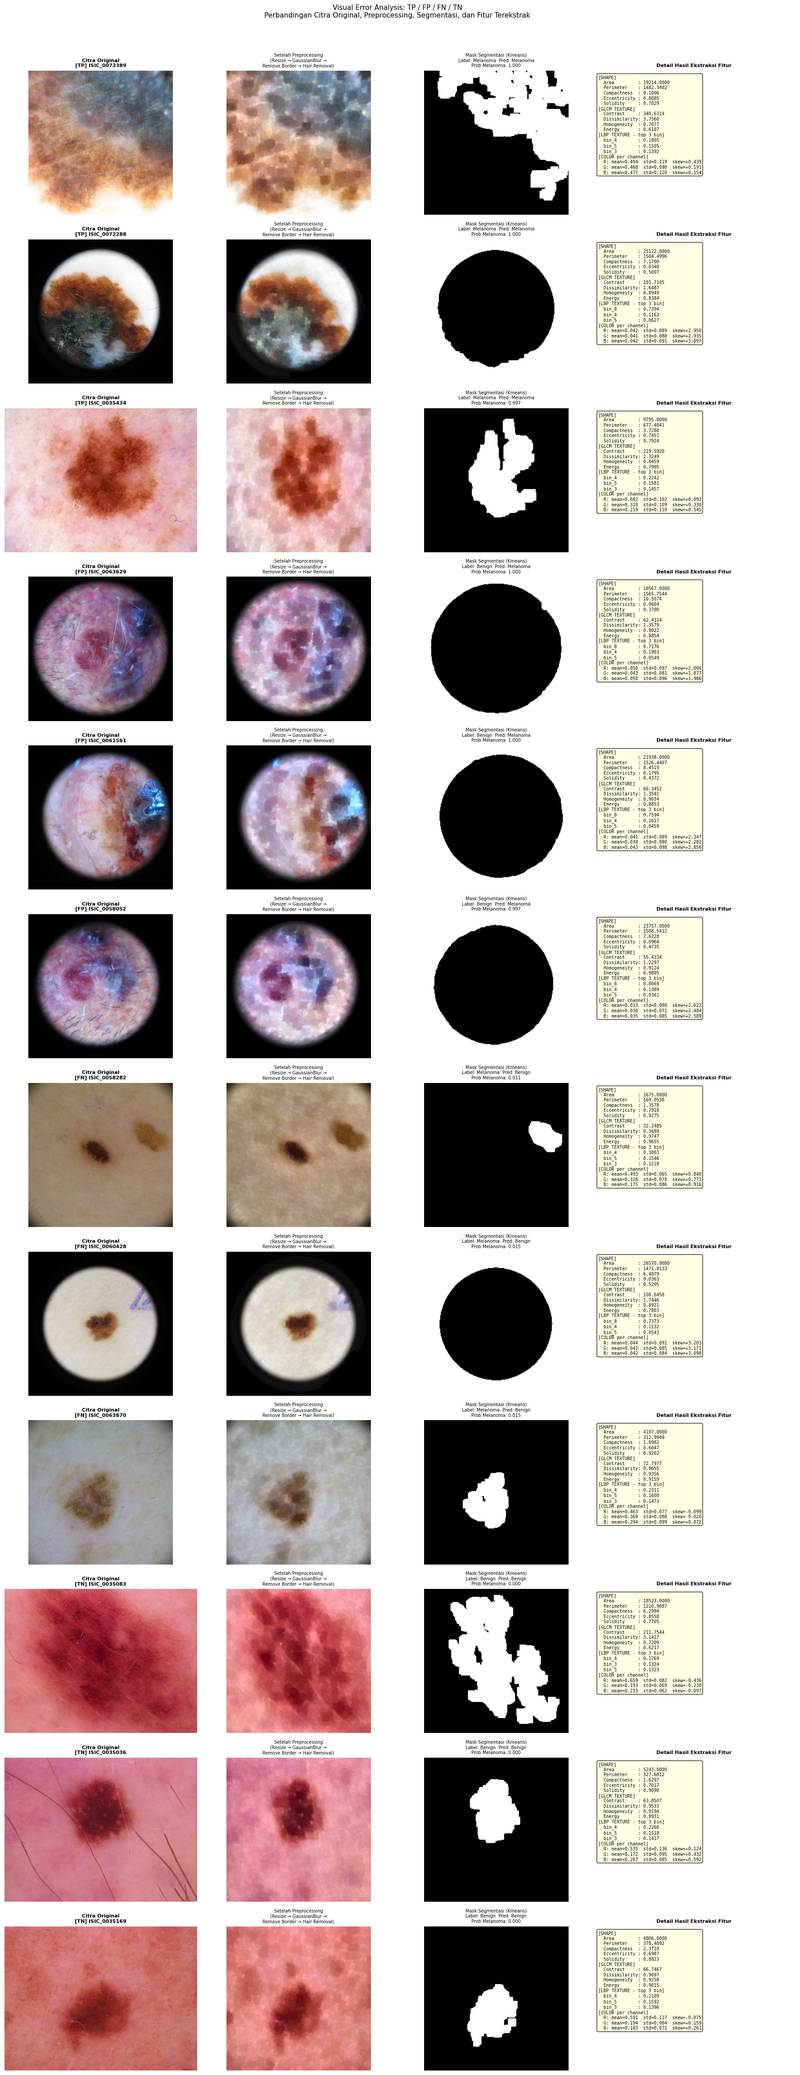

             image  y_true  y_pred  prob_melanoma case_type
7953  ISIC_0072389     1.0     1.0       0.999989        TP
7917  ISIC_0072288     1.0     1.0       0.999987        TP
5098  ISIC_0063629     0.0     1.0       0.999985        FP
4407  ISIC_0061561     0.0     1.0       0.999983        FP
3273  ISIC_0058052     0.0     1.0       0.997325        FP
1079  ISIC_0035434     1.0     1.0       0.997202        TP
6406  ISIC_0067593     1.0     1.0       0.997199        TP
1596  ISIC_0035956     1.0     1.0       0.996499        TP
3234  ISIC_0057939     1.0     1.0       0.995871        TP
1728  ISIC_0053520     1.0     1.0       0.995847        TP
1868  ISIC_0053927     1.0     1.0       0.995774        TP
6435  ISIC_0067690     1.0     1.0       0.995501        TP
4343  ISIC_0061380     1.0     1.0       0.995474        TP
6088  ISIC_0066610     0.0     1.0       0.991545        FP
8089  ISIC_0072790     0.0     1.0       0.991121        FP
812   ISIC_0035155     0.0     1.0      

In [50]:

# ============================================================
# REVISI PENGUJI: VISUAL ERROR ANALYSIS TP/FP/FN/TN
# Bukti citra untuk menjelaskan false positive dan false negative.
# + Detail hasil ekstraksi fitur per citra
# ============================================================
results_df["case_type"] = np.select(
    [
        (results_df["y_true"] == 1) & (results_df["y_pred"] == 1),
        (results_df["y_true"] == 0) & (results_df["y_pred"] == 0),
        (results_df["y_true"] == 0) & (results_df["y_pred"] == 1),
        (results_df["y_true"] == 1) & (results_df["y_pred"] == 0),
    ],
    ["TP", "TN", "FP", "FN"],
    default="Other"
)
print(results_df["case_type"].value_counts())

def _read_rgb(path):
    img = cv2.imread(path)
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def format_feature_text(img, mask):
    # Hitung dan format semua fitur handcrafted untuk 1 gambar
    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

    # Shape
    s = extract_shape_features(mask)
    shape_names = ["Area", "Perimeter", "Compactness", "Eccentricity", "Solidity"]

    # GLCM
    g = extract_glcm_features(gray, mask)
    glcm_names = ["Contrast", "Dissimilarity", "Homogeneity", "Energy"]

    # LBP
    lbp_vals = extract_lbp_features(img, mask)

    # Color
    c = extract_color_features(img, mask)

    lines = ["[SHAPE]"]
    for name, val in zip(shape_names, s):
        lines.append(f"  {name:<13}: {val:.4f}")

    lines.append("[GLCM TEXTURE]")
    for name, val in zip(glcm_names, g):
        lines.append(f"  {name:<13}: {val:.4f}")

    lines.append("[LBP TEXTURE - top 3 bin]")
    top3 = sorted(enumerate(lbp_vals), key=lambda x: -x[1])[:3]
    for idx, val in top3:
        lines.append(f"  bin_{idx:<2}       : {val:.4f}")

    lines.append("[COLOR per channel]")
    ch_names = ["R", "G", "B"]
    for i, ch in enumerate(ch_names):
        mean_v = c[i * 3]
        std_v  = c[i * 3 + 1]
        skew_v = c[i * 3 + 2]
        lines.append(f"  {ch}: mean={mean_v:.3f}  std={std_v:.3f}  skew={skew_v:+.3f}")

    return "\n".join(lines)

def visualize_case_grid(results_df, n_per_case=3):
    case_order = ["TP", "FP", "FN", "TN"]
    parts = []
    for case in case_order:
        sub = results_df[results_df["case_type"] == case].copy()
        if len(sub) == 0:
            continue
        sub = sub.sort_values("prob_melanoma", ascending=(case in ["TN", "FN"]))
        parts.append(sub.head(n_per_case))
    selected = pd.concat(parts) if parts else pd.DataFrame()
    if selected.empty:
        print("Tidak ada contoh untuk divisualisasikan")
        return

    # 4 kolom: Original | Preprocessed | Mask Segmentasi | Detail Fitur
    fig, axes = plt.subplots(len(selected), 4, figsize=(18, 3.8 * len(selected)))
    if len(selected) == 1:
        axes = np.expand_dims(axes, 0)

    for r, (_, row) in enumerate(selected.iterrows()):
        img_path = row["img_path"] if os.path.isabs(row["img_path"]) else os.path.join(TEST_IMG_DIR, row["img_path"])
        original = _read_rgb(img_path)
        pre      = preprocess_image(img_path)
        mask     = segment_kmeans(pre)

        # Kolom 0: Citra Original
        if original is not None:
            axes[r, 0].imshow(original)
        axes[r, 0].set_title(
            f"Citra Original\n[{row['case_type']}] {row['image']}",
            fontsize=8, fontweight='bold'
        )
        axes[r, 0].axis("off")

        # Kolom 1: Citra Setelah Preprocessing
        axes[r, 1].imshow(pre)
        axes[r, 1].set_title(
            "Setelah Preprocessing\n(Resize \u2192 GaussianBlur \u2192\nRemove Border \u2192 Hair Removal)",
            fontsize=7
        )
        axes[r, 1].axis("off")

        # Kolom 2: Mask Segmentasi
        axes[r, 2].imshow(mask, cmap="gray")
        axes[r, 2].set_title(
            f"Mask Segmentasi (Kmeans)\n"
            f"Label: {'Melanoma' if int(row['y_true'])==1 else 'Benign'}  "
            f"Pred: {'Melanoma' if int(row['y_pred'])==1 else 'Benign'}\n"
            f"Prob Melanoma: {row['prob_melanoma']:.3f}",
            fontsize=7
        )
        axes[r, 2].axis("off")

        # Kolom 3: Detail Hasil Ekstraksi Fitur
        feat_text = format_feature_text(pre, mask)
        axes[r, 3].axis("off")
        axes[r, 3].text(
            0.03, 0.97, feat_text,
            transform=axes[r, 3].transAxes,
            fontsize=7,
            verticalalignment='top',
            fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85)
        )
        axes[r, 3].set_title("Detail Hasil Ekstraksi Fitur", fontsize=8, fontweight='bold')

    plt.suptitle(
        "Visual Error Analysis: TP / FP / FN / TN\n"
        "Perbandingan Citra Original, Preprocessing, Segmentasi, dan Fitur Terekstrak",
        fontsize=11, y=1.01
    )
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "visual_error_analysis_tp_fp_fn_tn.png"), dpi=200, bbox_inches="tight")
    plt.show()

visualize_case_grid(results_df, n_per_case=3)
case_examples = results_df.sort_values("prob_melanoma", ascending=False).groupby("case_type").head(10)
case_examples[["image", "y_true", "y_pred", "prob_melanoma", "case_type"]].to_csv(os.path.join(OUTPUT_DIR, "visual_error_case_examples.csv"), index=False)
print(case_examples[["image", "y_true", "y_pred", "prob_melanoma", "case_type"]].head(20))


case_type
TN    5512
FP    1399
TP     930
FN     397
Name: count, dtype: int64


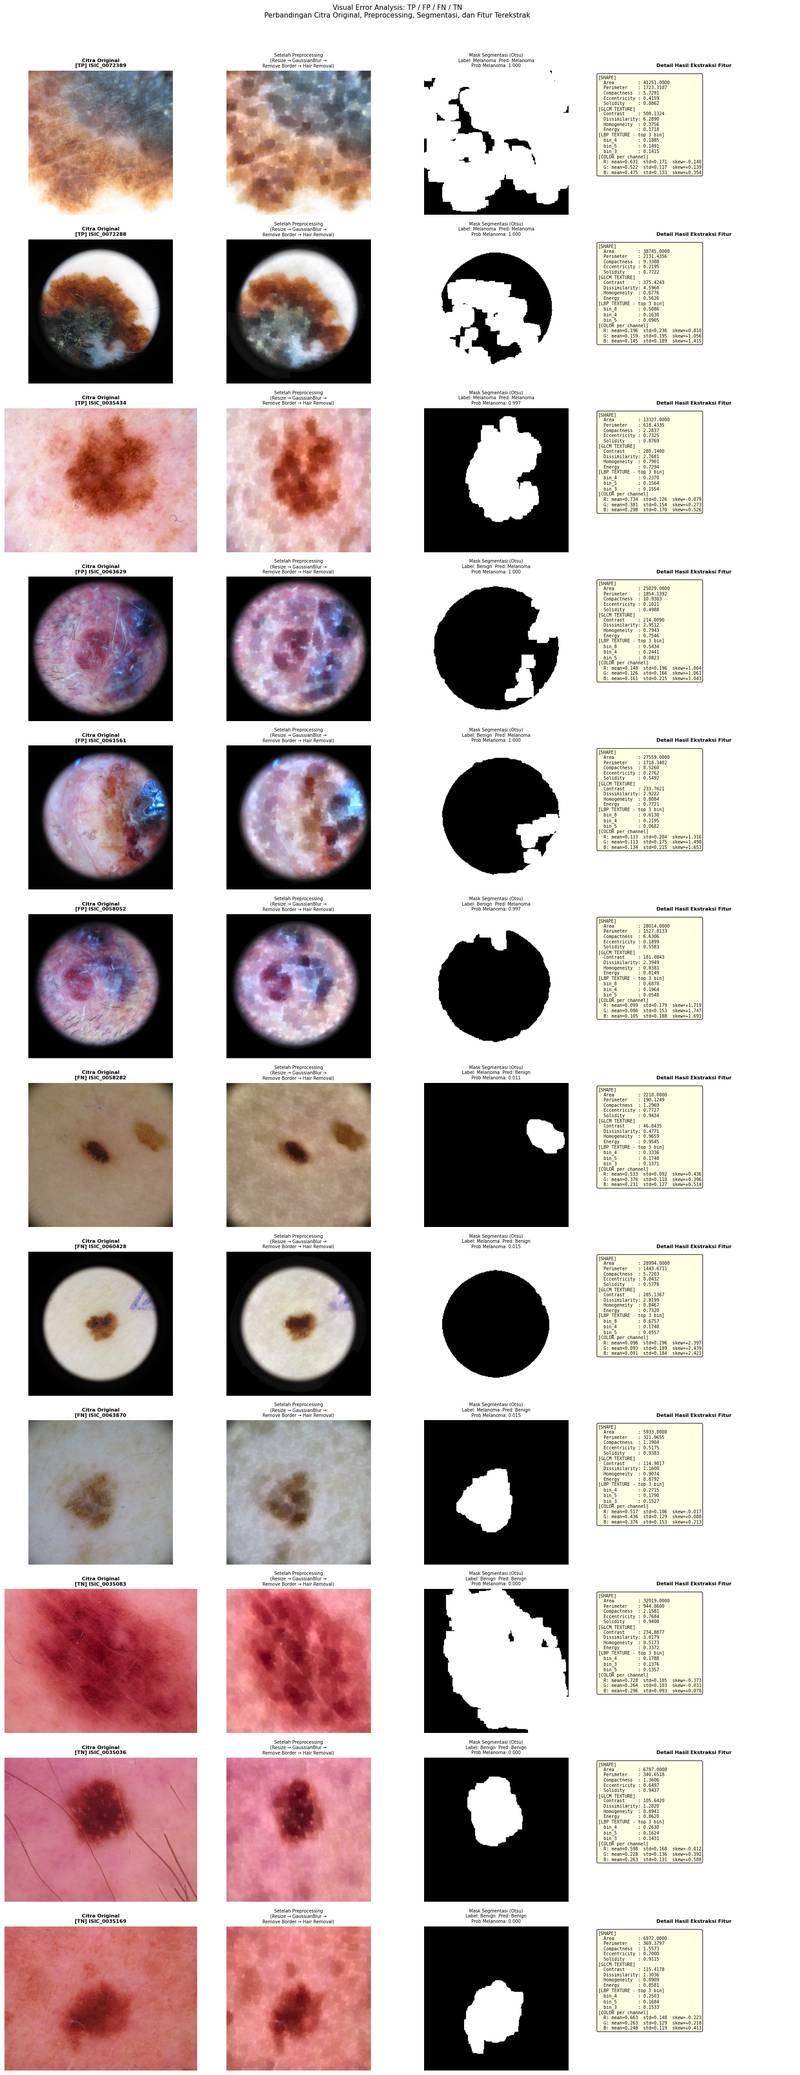

             image  y_true  y_pred  prob_melanoma case_type
7953  ISIC_0072389     1.0     1.0       0.999989        TP
7917  ISIC_0072288     1.0     1.0       0.999987        TP
5098  ISIC_0063629     0.0     1.0       0.999985        FP
4407  ISIC_0061561     0.0     1.0       0.999983        FP
3273  ISIC_0058052     0.0     1.0       0.997325        FP
1079  ISIC_0035434     1.0     1.0       0.997202        TP
6406  ISIC_0067593     1.0     1.0       0.997199        TP
1596  ISIC_0035956     1.0     1.0       0.996499        TP
3234  ISIC_0057939     1.0     1.0       0.995871        TP
1728  ISIC_0053520     1.0     1.0       0.995847        TP
1868  ISIC_0053927     1.0     1.0       0.995774        TP
6435  ISIC_0067690     1.0     1.0       0.995501        TP
4343  ISIC_0061380     1.0     1.0       0.995474        TP
6088  ISIC_0066610     0.0     1.0       0.991545        FP
8089  ISIC_0072790     0.0     1.0       0.991121        FP
812   ISIC_0035155     0.0     1.0      

In [53]:

# ============================================================
# REVISI PENGUJI: VISUAL ERROR ANALYSIS TP/FP/FN/TN
# Bukti citra untuk menjelaskan false positive dan false negative.
# + Detail hasil ekstraksi fitur per citra
# ============================================================
results_df["case_type"] = np.select(
    [
        (results_df["y_true"] == 1) & (results_df["y_pred"] == 1),
        (results_df["y_true"] == 0) & (results_df["y_pred"] == 0),
        (results_df["y_true"] == 0) & (results_df["y_pred"] == 1),
        (results_df["y_true"] == 1) & (results_df["y_pred"] == 0),
    ],
    ["TP", "TN", "FP", "FN"],
    default="Other"
)
print(results_df["case_type"].value_counts())

def _read_rgb(path):
    img = cv2.imread(path)
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def format_feature_text(img, mask):
    # Hitung dan format semua fitur handcrafted untuk 1 gambar
    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

    # Shape
    s = extract_shape_features(mask)
    shape_names = ["Area", "Perimeter", "Compactness", "Eccentricity", "Solidity"]

    # GLCM
    g = extract_glcm_features(gray, mask)
    glcm_names = ["Contrast", "Dissimilarity", "Homogeneity", "Energy"]

    # LBP
    lbp_vals = extract_lbp_features(img, mask)

    # Color
    c = extract_color_features(img, mask)

    lines = ["[SHAPE]"]
    for name, val in zip(shape_names, s):
        lines.append(f"  {name:<13}: {val:.4f}")

    lines.append("[GLCM TEXTURE]")
    for name, val in zip(glcm_names, g):
        lines.append(f"  {name:<13}: {val:.4f}")

    lines.append("[LBP TEXTURE - top 3 bin]")
    top3 = sorted(enumerate(lbp_vals), key=lambda x: -x[1])[:3]
    for idx, val in top3:
        lines.append(f"  bin_{idx:<2}       : {val:.4f}")

    lines.append("[COLOR per channel]")
    ch_names = ["R", "G", "B"]
    for i, ch in enumerate(ch_names):
        mean_v = c[i * 3]
        std_v  = c[i * 3 + 1]
        skew_v = c[i * 3 + 2]
        lines.append(f"  {ch}: mean={mean_v:.3f}  std={std_v:.3f}  skew={skew_v:+.3f}")

    return "\n".join(lines)

def visualize_case_grid(results_df, n_per_case=3):
    case_order = ["TP", "FP", "FN", "TN"]
    parts = []
    for case in case_order:
        sub = results_df[results_df["case_type"] == case].copy()
        if len(sub) == 0:
            continue
        sub = sub.sort_values("prob_melanoma", ascending=(case in ["TN", "FN"]))
        parts.append(sub.head(n_per_case))
    selected = pd.concat(parts) if parts else pd.DataFrame()
    if selected.empty:
        print("Tidak ada contoh untuk divisualisasikan")
        return

    # 4 kolom: Original | Preprocessed | Mask Segmentasi | Detail Fitur
    fig, axes = plt.subplots(len(selected), 4, figsize=(18, 3.8 * len(selected)))
    if len(selected) == 1:
        axes = np.expand_dims(axes, 0)

    for r, (_, row) in enumerate(selected.iterrows()):
        img_path = row["img_path"] if os.path.isabs(row["img_path"]) else os.path.join(TEST_IMG_DIR, row["img_path"])
        original = _read_rgb(img_path)
        pre      = preprocess_image(img_path)
        mask     = segment_lesion(pre)

        # Kolom 0: Citra Original
        if original is not None:
            axes[r, 0].imshow(original)
        axes[r, 0].set_title(
            f"Citra Original\n[{row['case_type']}] {row['image']}",
            fontsize=8, fontweight='bold'
        )
        axes[r, 0].axis("off")

        # Kolom 1: Citra Setelah Preprocessing
        axes[r, 1].imshow(pre)
        axes[r, 1].set_title(
            "Setelah Preprocessing\n(Resize \u2192 GaussianBlur \u2192\nRemove Border \u2192 Hair Removal)",
            fontsize=7
        )
        axes[r, 1].axis("off")

        # Kolom 2: Mask Segmentasi
        axes[r, 2].imshow(mask, cmap="gray")
        axes[r, 2].set_title(
            f"Mask Segmentasi (Otsu)\n"
            f"Label: {'Melanoma' if int(row['y_true'])==1 else 'Benign'}  "
            f"Pred: {'Melanoma' if int(row['y_pred'])==1 else 'Benign'}\n"
            f"Prob Melanoma: {row['prob_melanoma']:.3f}",
            fontsize=7
        )
        axes[r, 2].axis("off")

        # Kolom 3: Detail Hasil Ekstraksi Fitur
        feat_text = format_feature_text(pre, mask)
        axes[r, 3].axis("off")
        axes[r, 3].text(
            0.03, 0.97, feat_text,
            transform=axes[r, 3].transAxes,
            fontsize=7,
            verticalalignment='top',
            fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85)
        )
        axes[r, 3].set_title("Detail Hasil Ekstraksi Fitur", fontsize=8, fontweight='bold')

    plt.suptitle(
        "Visual Error Analysis: TP / FP / FN / TN\n"
        "Perbandingan Citra Original, Preprocessing, Segmentasi, dan Fitur Terekstrak",
        fontsize=11, y=1.01
    )
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "visual_error_analysis_tp_fp_fn_tn.png"), dpi=200, bbox_inches="tight")
    plt.show()

visualize_case_grid(results_df, n_per_case=3)
case_examples = results_df.sort_values("prob_melanoma", ascending=False).groupby("case_type").head(10)
case_examples[["image", "y_true", "y_pred", "prob_melanoma", "case_type"]].to_csv(os.path.join(OUTPUT_DIR, "visual_error_case_examples.csv"), index=False)
print(case_examples[["image", "y_true", "y_pred", "prob_melanoma", "case_type"]].head(20))


In [ ]:

# DRAFT NARASI BAB V UNTUK MENJAWAB BOTTLENECK UTAMA
print("""
Inti interpretasi:
1. Sensitivity tinggi menunjukkan model lebih agresif menangkap melanoma. Downsampling, tambahan data melanoma, dan class_weight balanced mendorong decision boundary agar lebih berpihak pada kelas melanoma.
2. Trade-off-nya adalah precision/specificity turun karena sebagian benign yang memiliki warna tidak homogen, tekstur kompleks, atau bentuk tidak reguler ikut diprediksi sebagai melanoma.
3. Ablation study menjelaskan kelompok fitur mana yang paling berkontribusi. Jika color/texture tinggi sensitivity tetapi precision rendah, berarti fitur tersebut sensitif terhadap pola visual melanoma namun juga mudah tertukar dengan benign borderline.
4. Feature ranking menunjukkan fitur/kelompok fitur yang dominan pada seleksi HHO dan model XGBoost. Fitness HHO diarahkan ke recall/sensitivity agar selaras dengan tujuan screening medis, namun tetap memasukkan specificity sebagai kontrol false positive.
5. Threshold analysis menjadi mitigasi: threshold rendah cocok untuk screening awal agar false negative rendah; threshold lebih tinggi dapat menekan false positive tetapi mengorbankan sensitivity.
6. Sistem diposisikan sebagai alat bantu screening awal, bukan diagnosis final. False positive masih perlu pemeriksaan lanjutan, tetapi false negative yang rendah penting untuk mengurangi risiko melanoma tidak terdeteksi.
""")



Inti interpretasi:
1. Sensitivity tinggi menunjukkan model lebih agresif menangkap melanoma. Downsampling, tambahan data melanoma, dan class_weight balanced mendorong decision boundary agar lebih berpihak pada kelas melanoma.
2. Trade-off-nya adalah precision/specificity turun karena sebagian benign yang memiliki warna tidak homogen, tekstur kompleks, atau bentuk tidak reguler ikut diprediksi sebagai melanoma.
3. Ablation study menjelaskan kelompok fitur mana yang paling berkontribusi. Jika color/texture tinggi sensitivity tetapi precision rendah, berarti fitur tersebut sensitif terhadap pola visual melanoma namun juga mudah tertukar dengan benign borderline.
4. Feature ranking menunjukkan fitur/kelompok fitur yang dominan pada seleksi HHO dan model XGBoost. Fitness HHO diarahkan ke recall/sensitivity agar selaras dengan tujuan screening medis, namun tetap memasukkan specificity sebagai kontrol false positive.
5. Threshold analysis menjadi mitigasi: threshold rendah cocok untuk screen